<a href="https://colab.research.google.com/github/Aaarin12/Pheno12/blob/main/Lingonberry_Gel_detection_Genomics_Yolov9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvidia-smi

Mon Feb 24 22:57:29 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
!pip install ultralytics

In [4]:
import ultralytics
ultralytics.checks()

Ultralytics 8.3.78 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 33.2/235.7 GB disk)


In [5]:
from ultralytics import YOLO
from IPython.display import display, Image

In [9]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="EwfHIT9w5sdIPsyyFO5v")
project = rf.workspace("image-analysis-0mduj").project("gel-annotation-on-lingonberry")
version = project.version(1)
dataset = version.download("yolov9")


loading Roboflow workspace...
loading Roboflow project...


In [10]:
dataset.location

'/content/Gel-annotation-on-lingonberry-1'

In [11]:
! yolo task=detect mode=train data={dataset.location}/data.yaml model="yolov9s.pt" epochs=40 imgsz=600

100% 14.7M/14.7M [00:00<00:00, 44.0MB/s]
Ultralytics 8.3.78 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov9s.pt, data=/content/Gel-annotation-on-lingonberry-1/data.yaml, epochs=40, time=None, patience=100, batch=16, imgsz=600, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=Fal

In [12]:
from IPython.display import display, Image

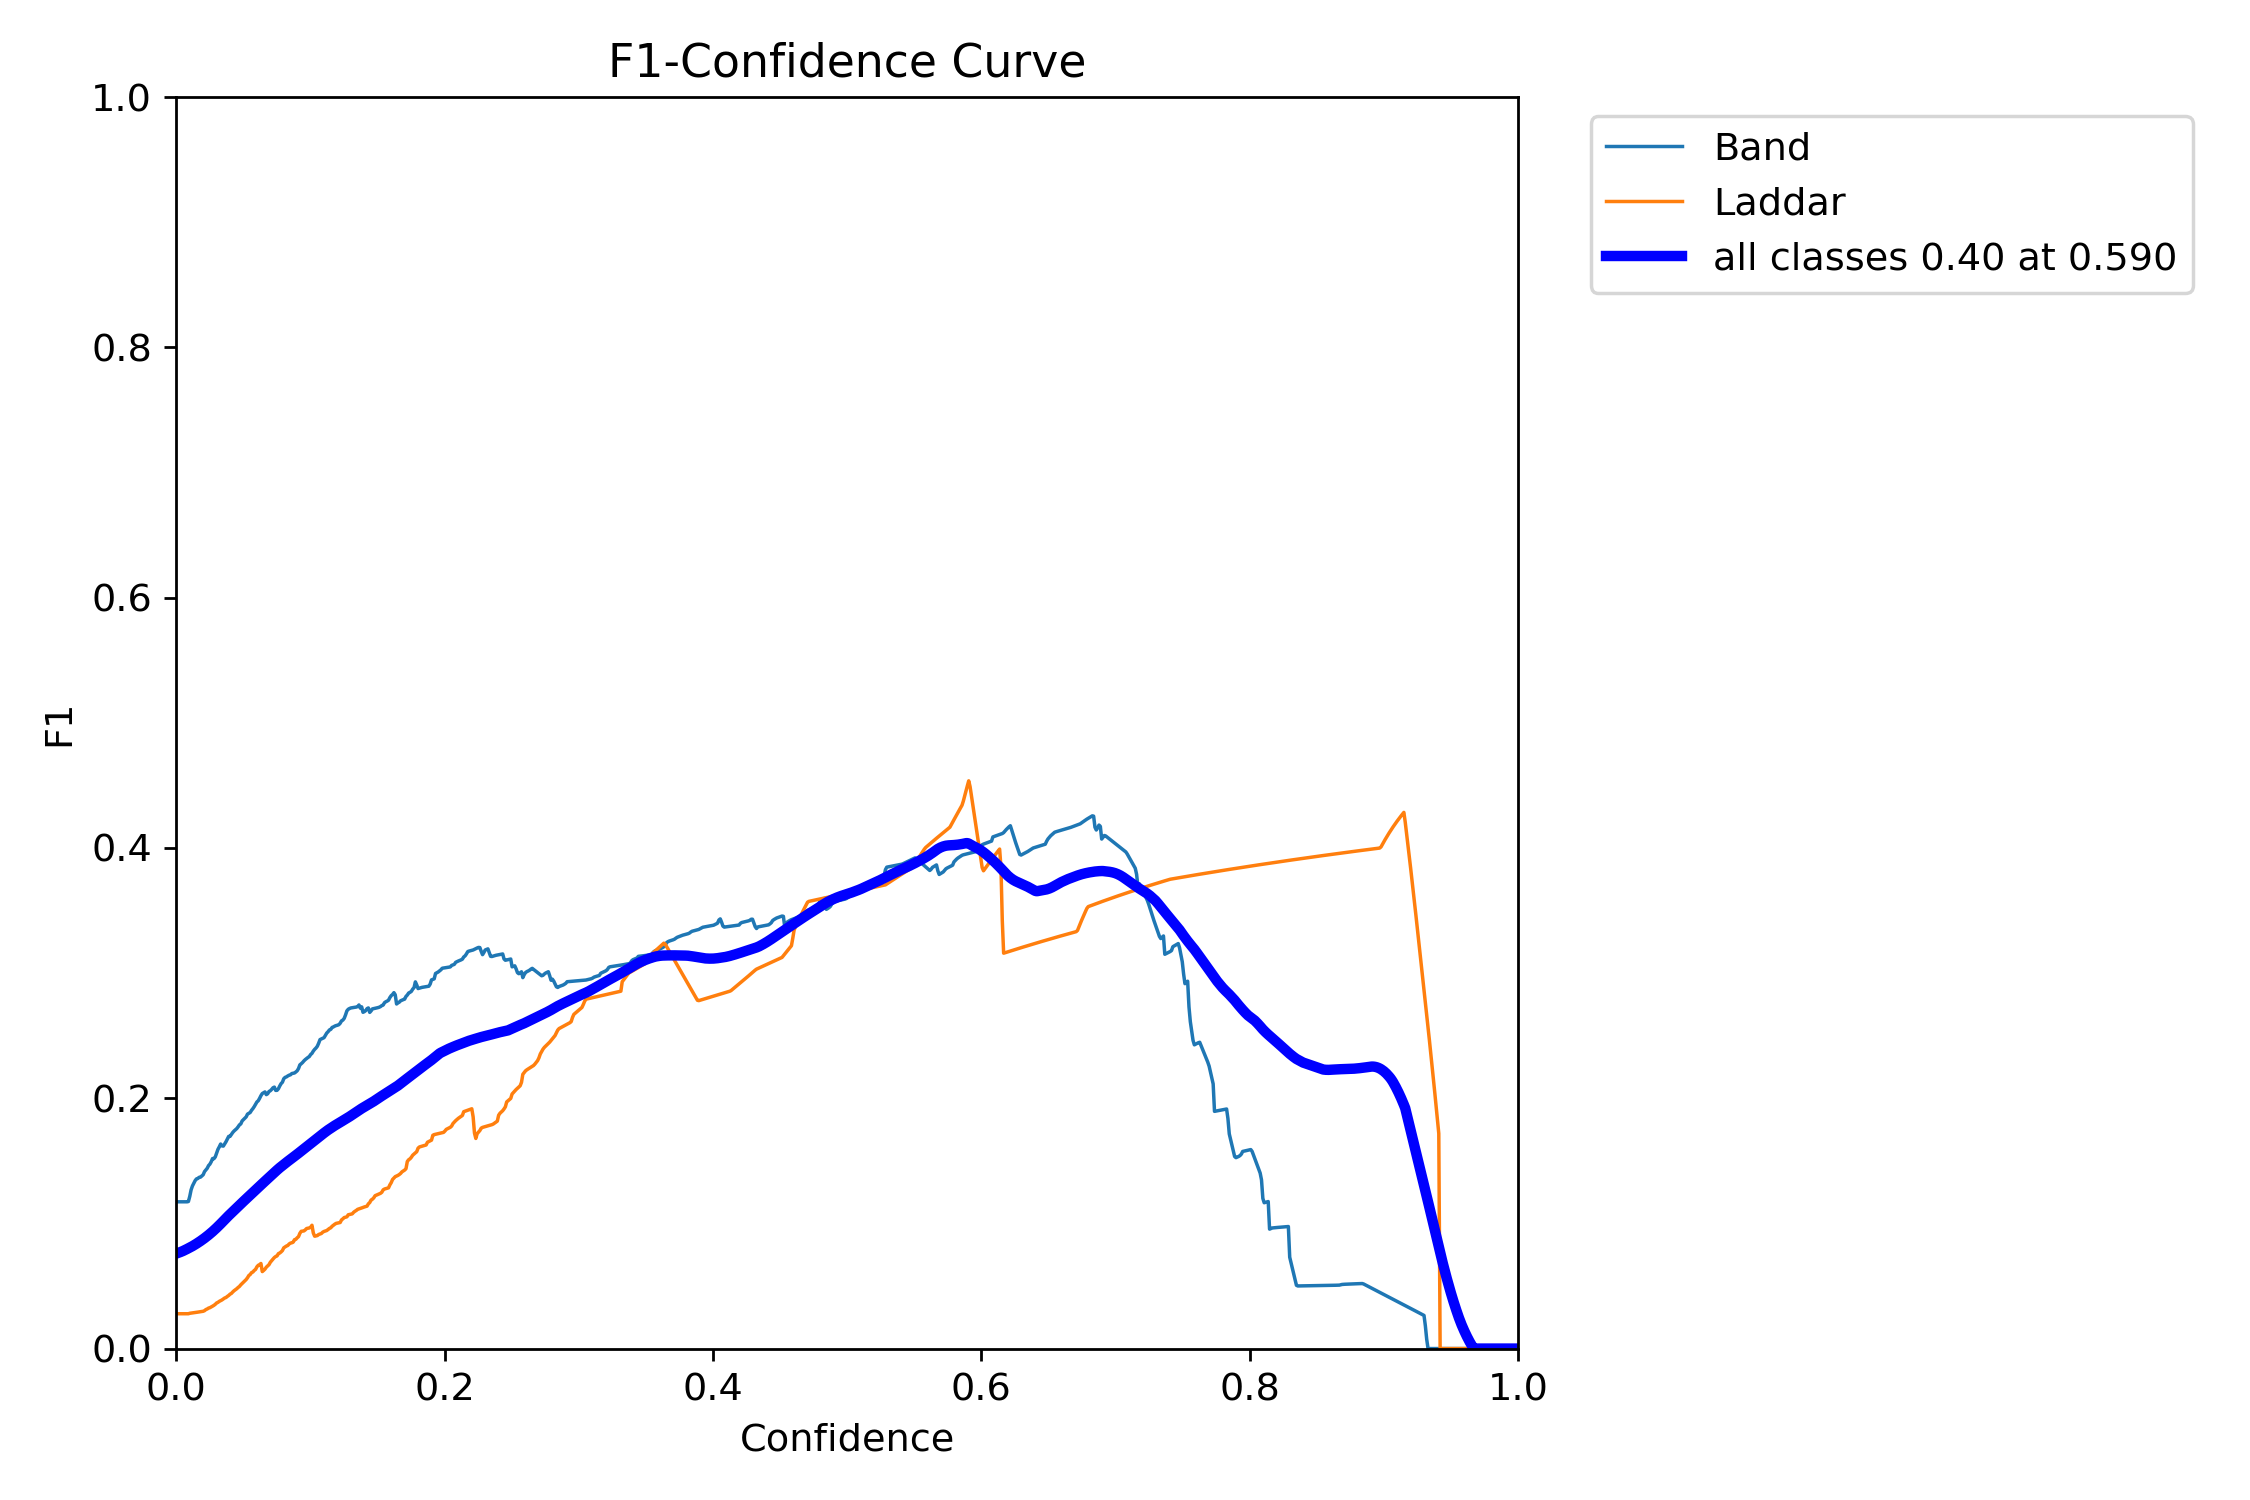

In [13]:
Image ("/content/runs/detect/train/F1_curve.png", width= 600)

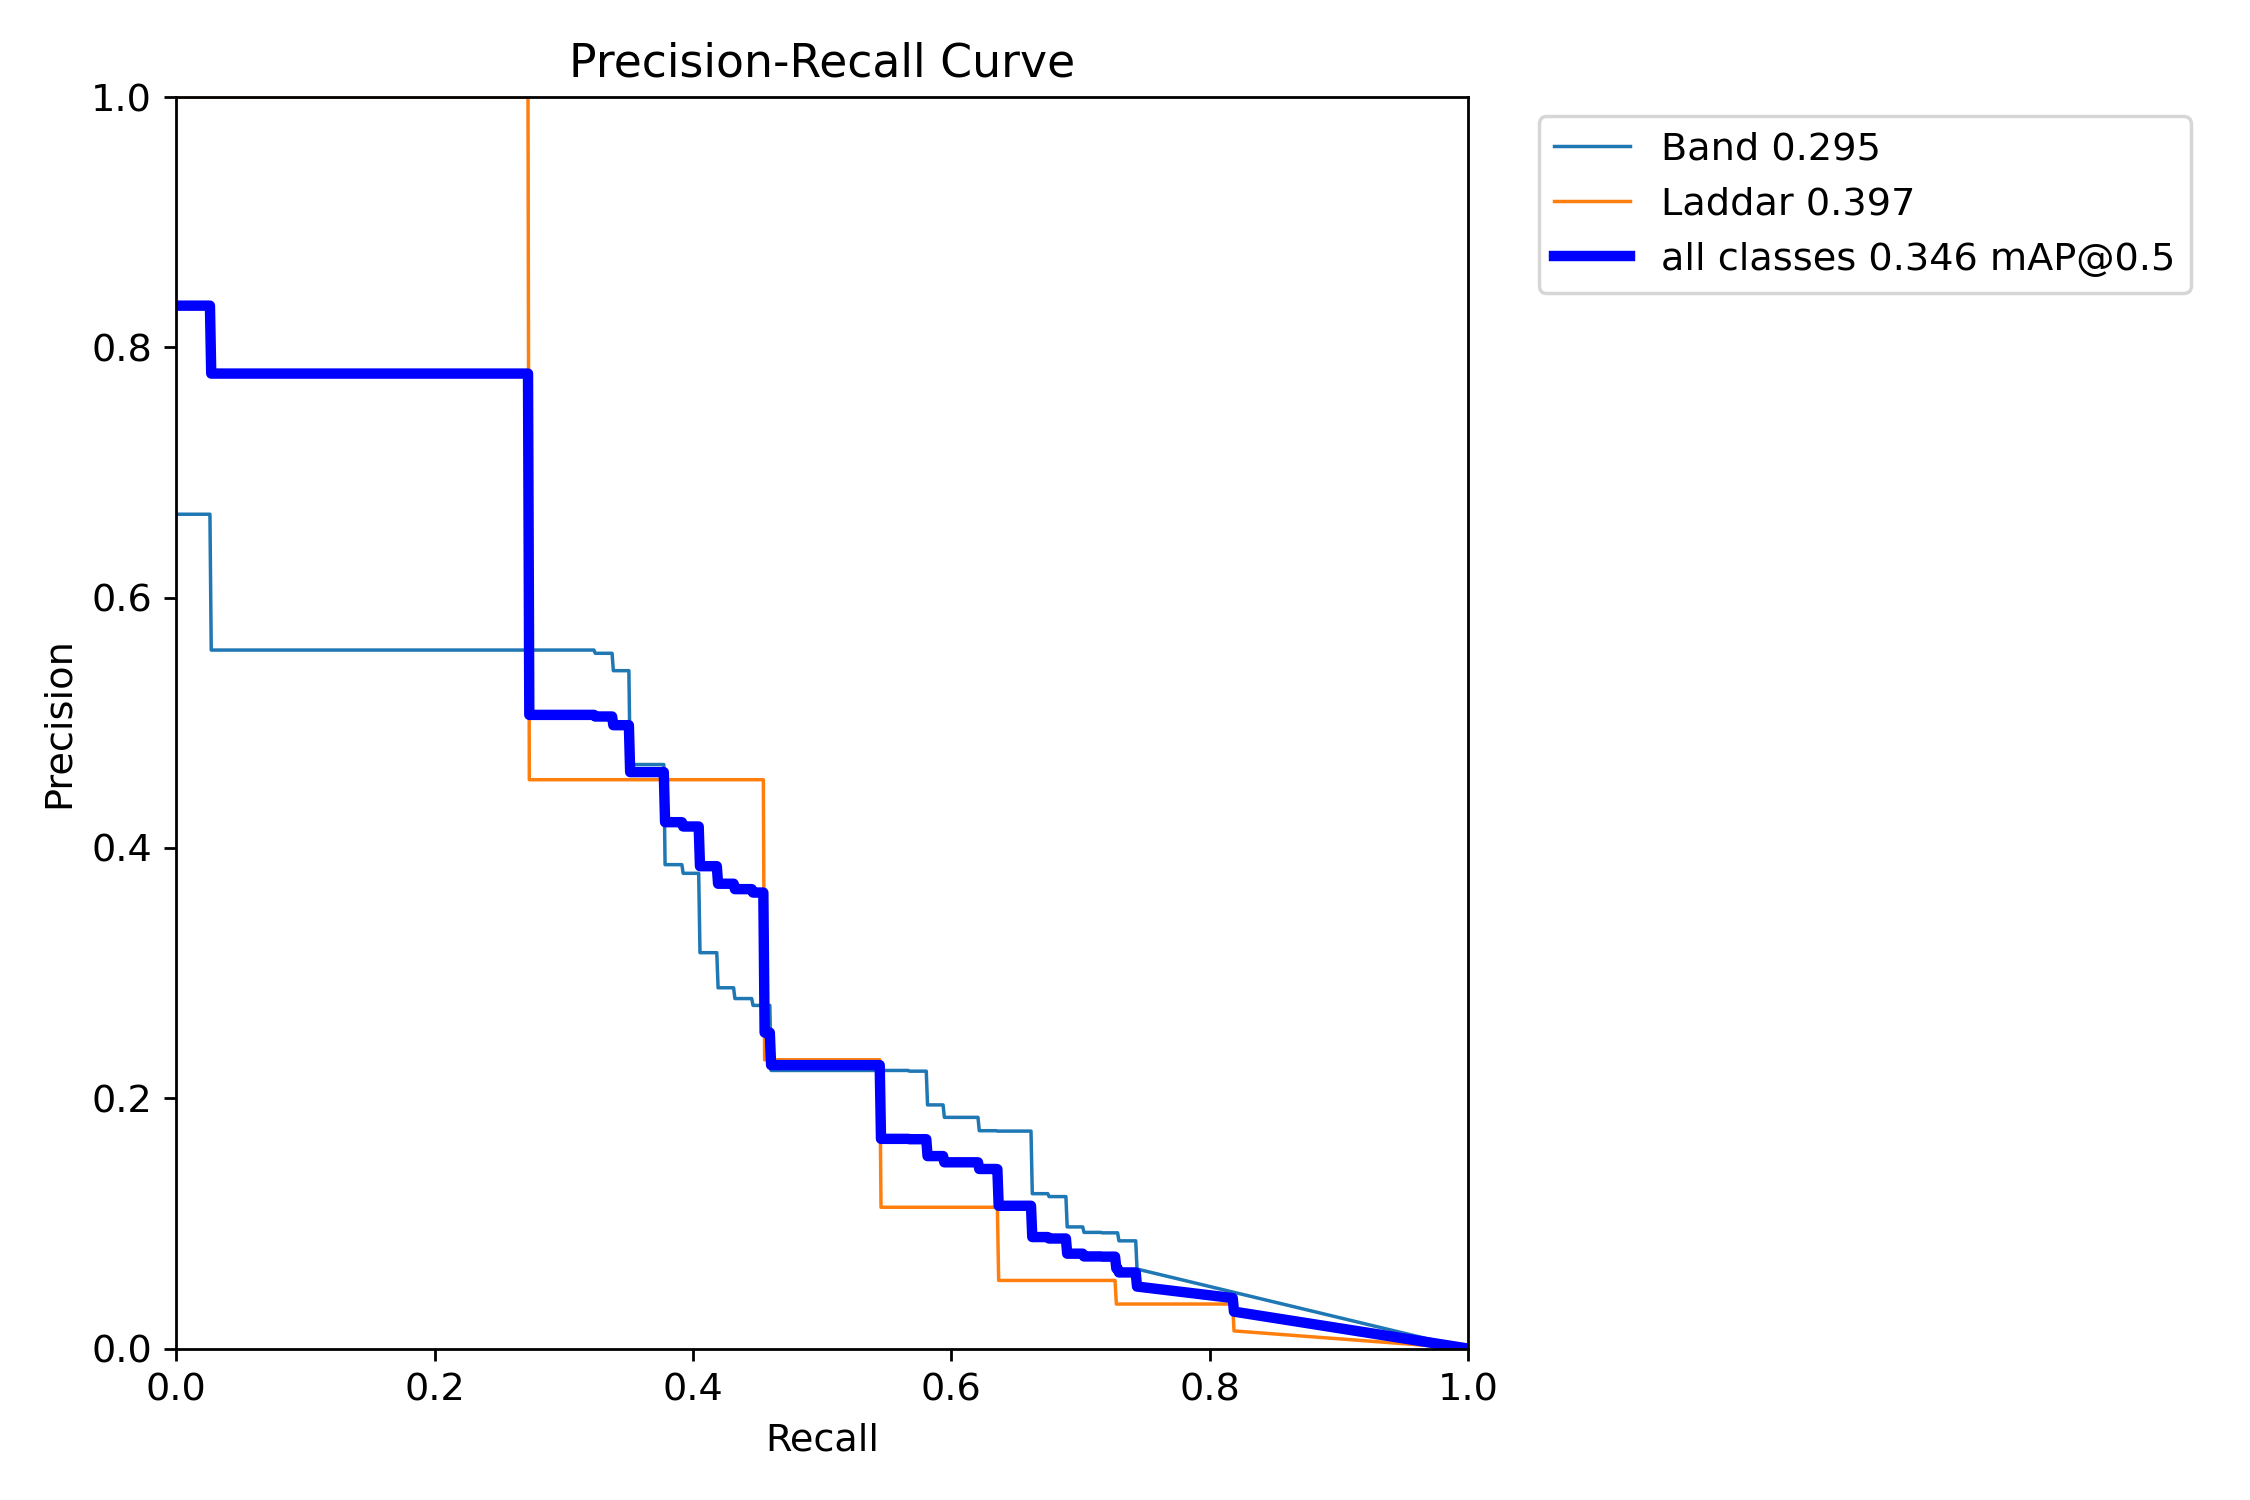

In [14]:
Image ("/content/runs/detect/train/PR_curve.png", width= 600)

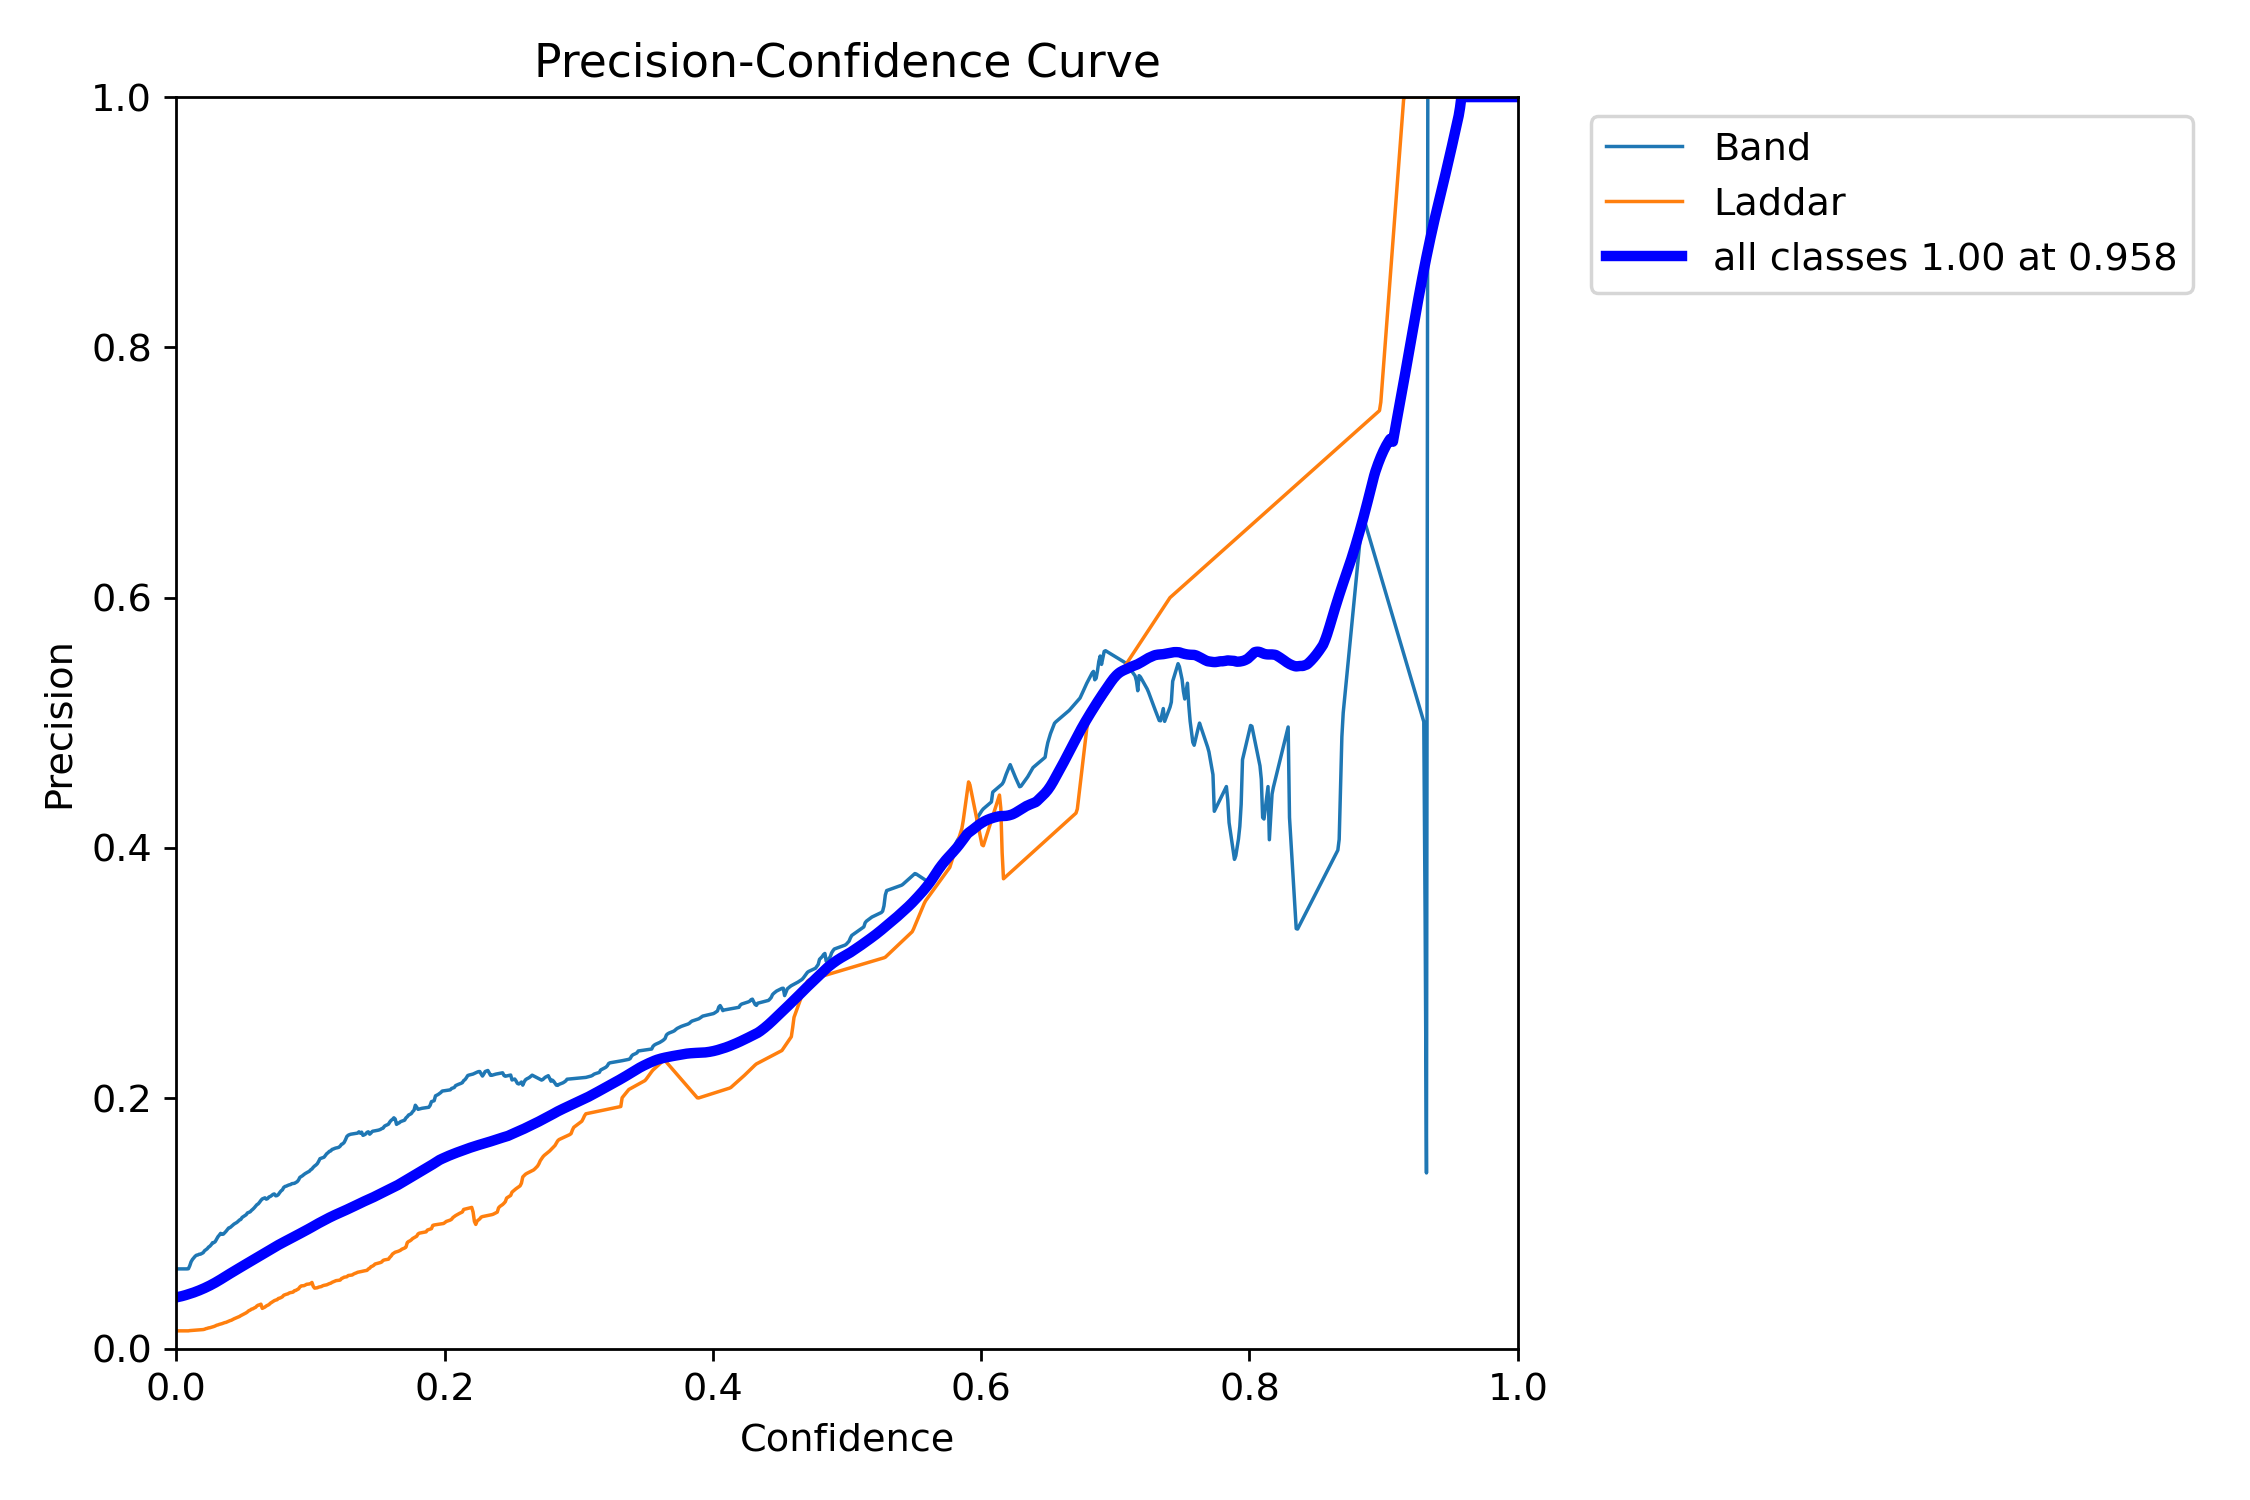

In [15]:
Image ("/content/runs/detect/train/P_curve.png", width= 600)

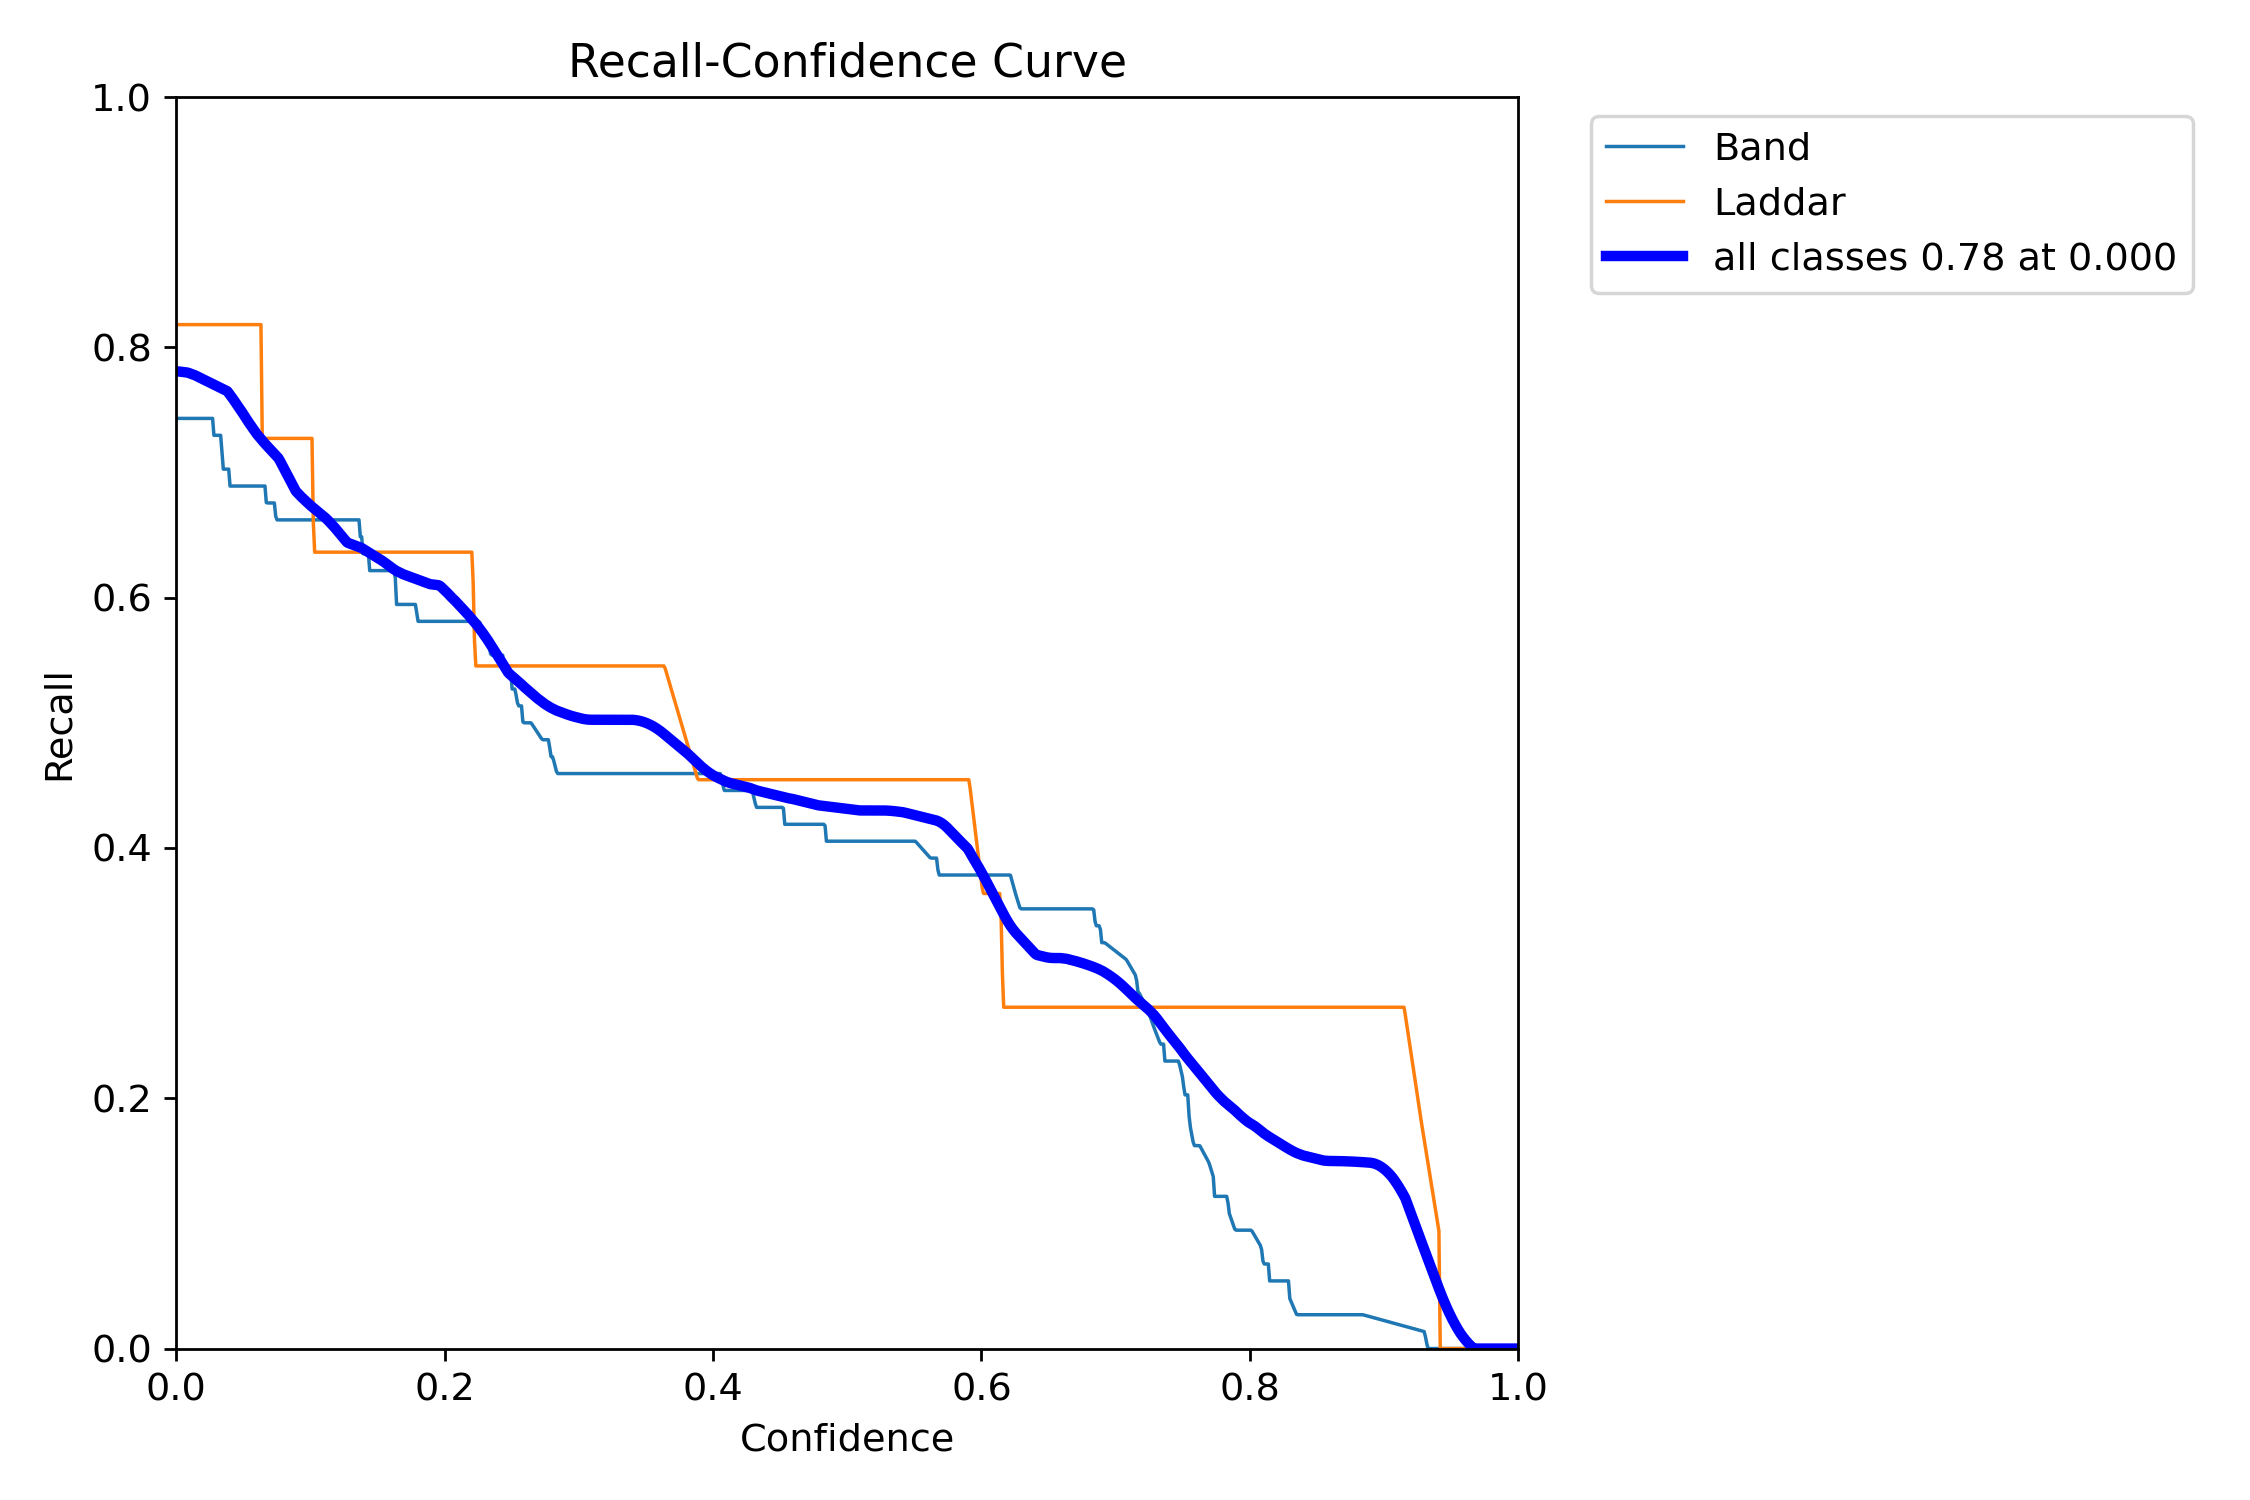

In [16]:
Image ("/content/runs/detect/train/R_curve.png", width= 600)

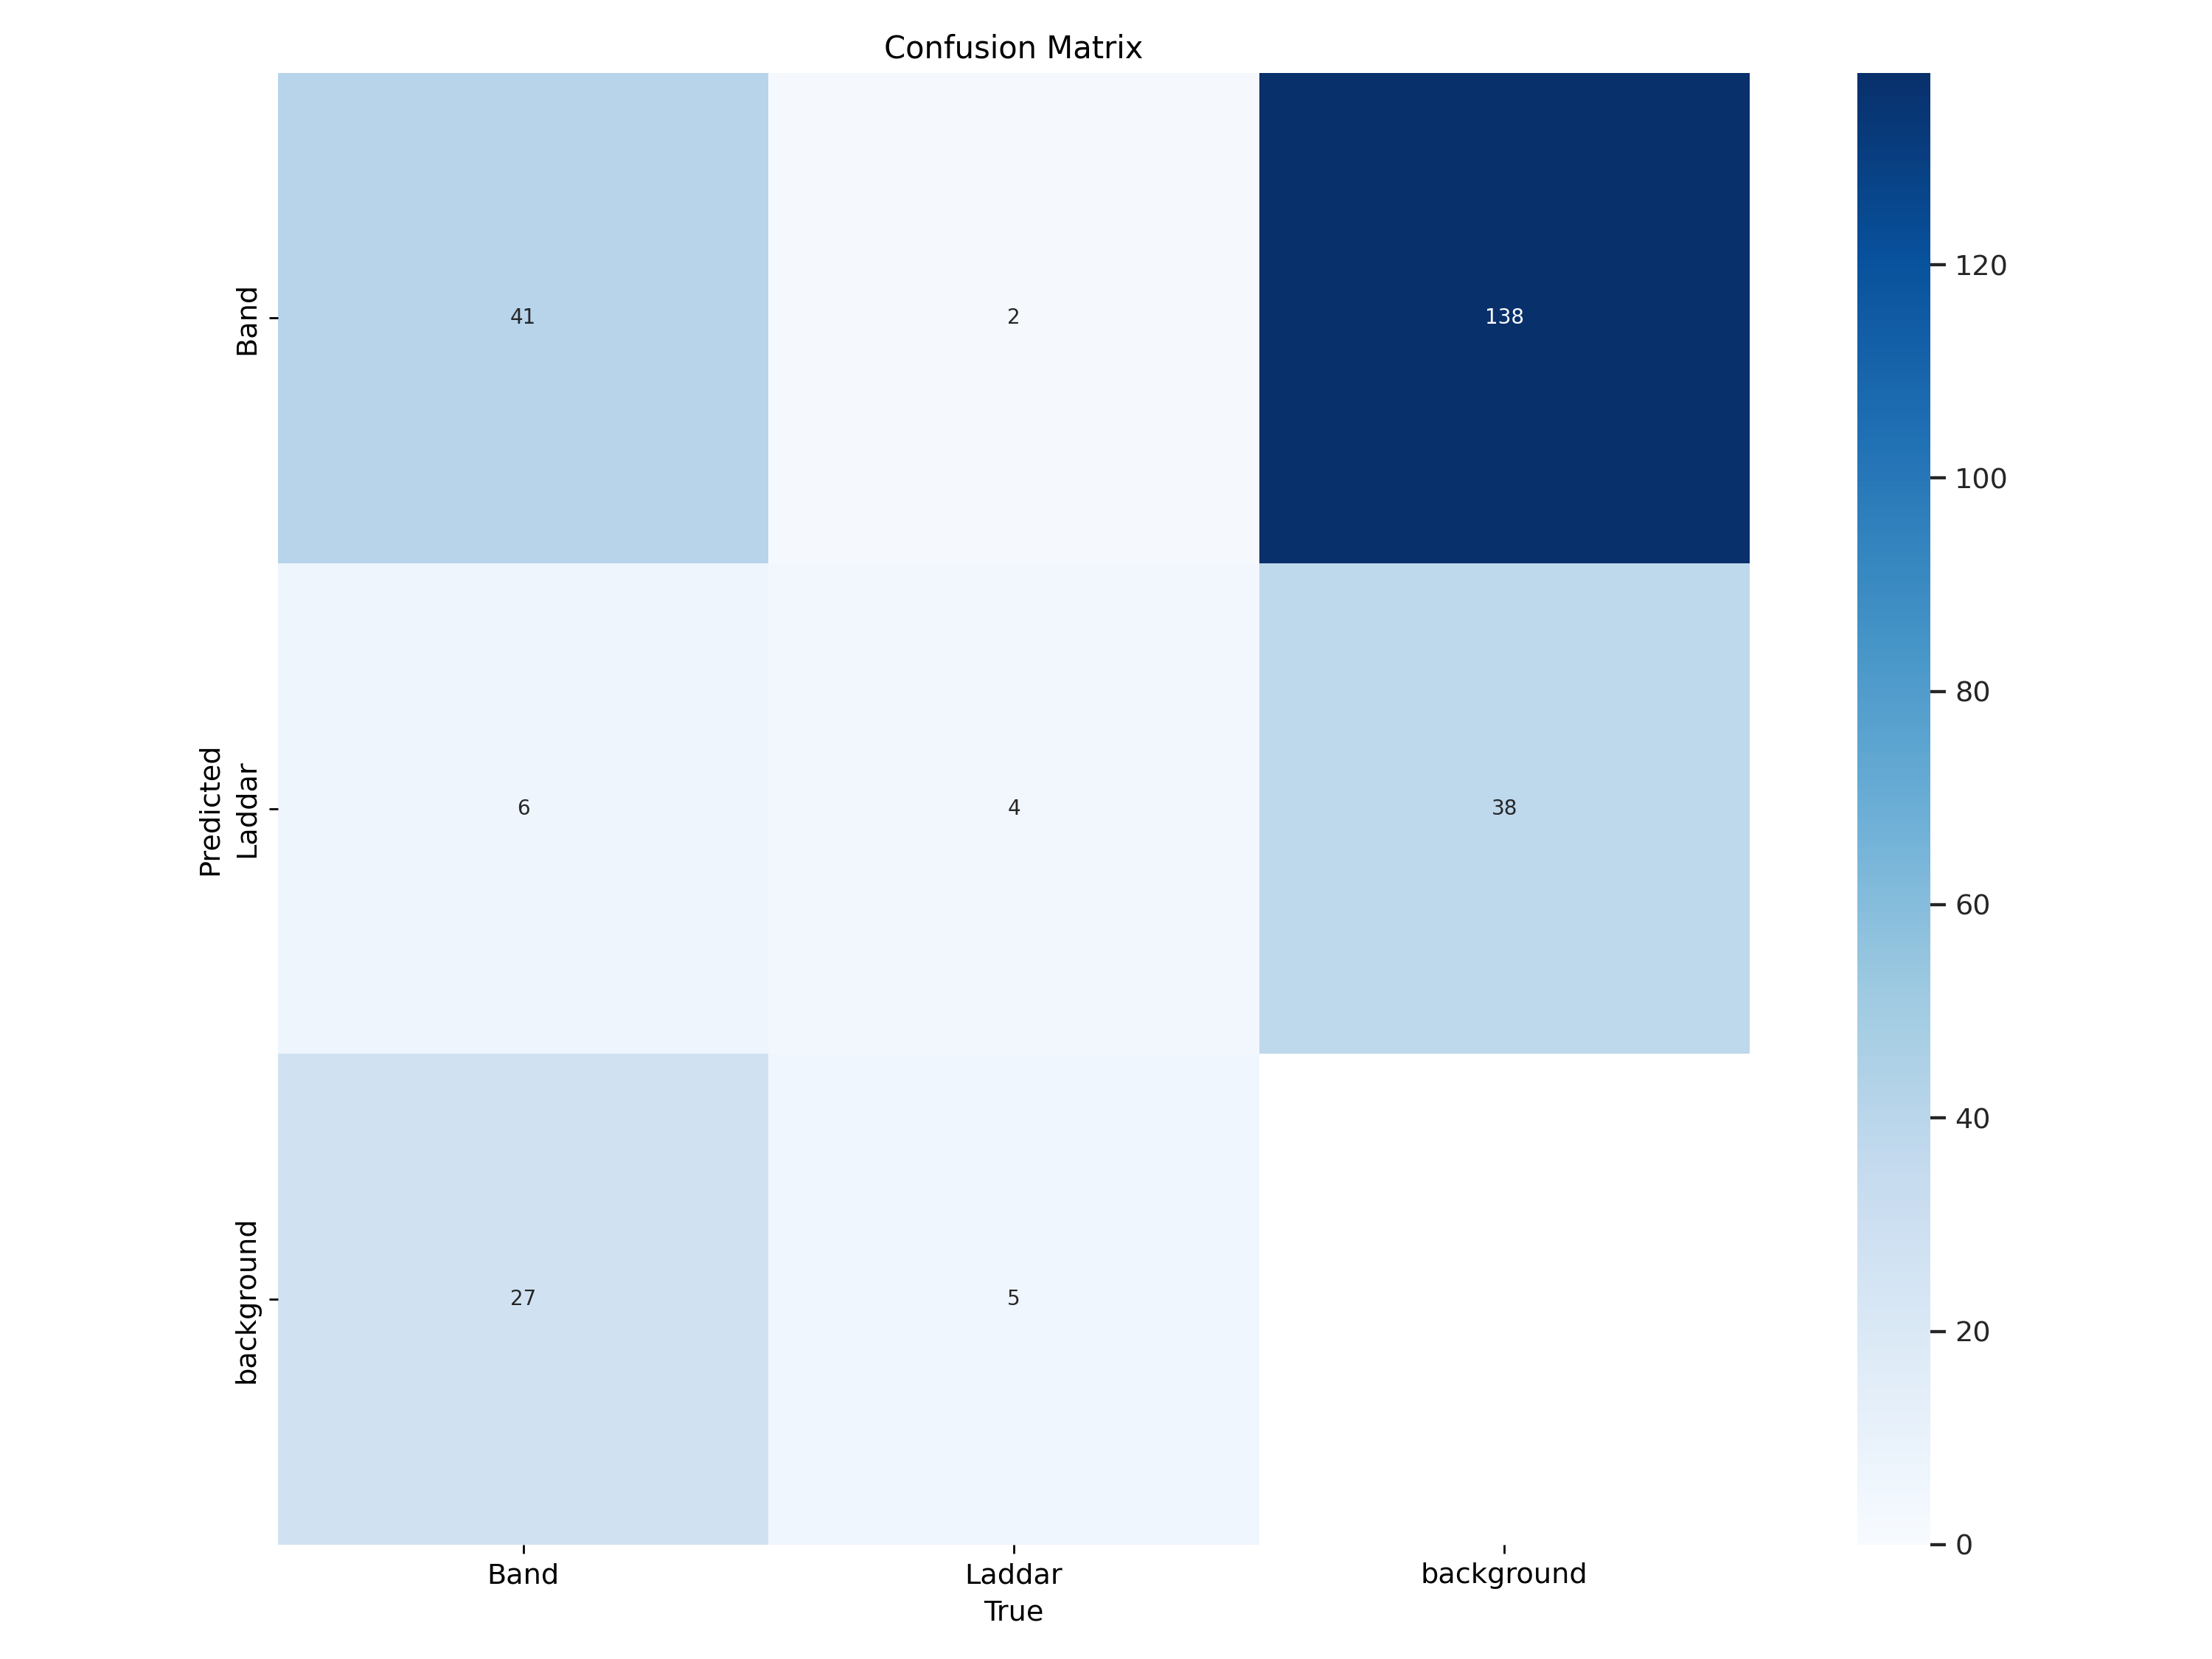

In [17]:
Image ("/content/runs/detect/train/confusion_matrix.png", width= 900)

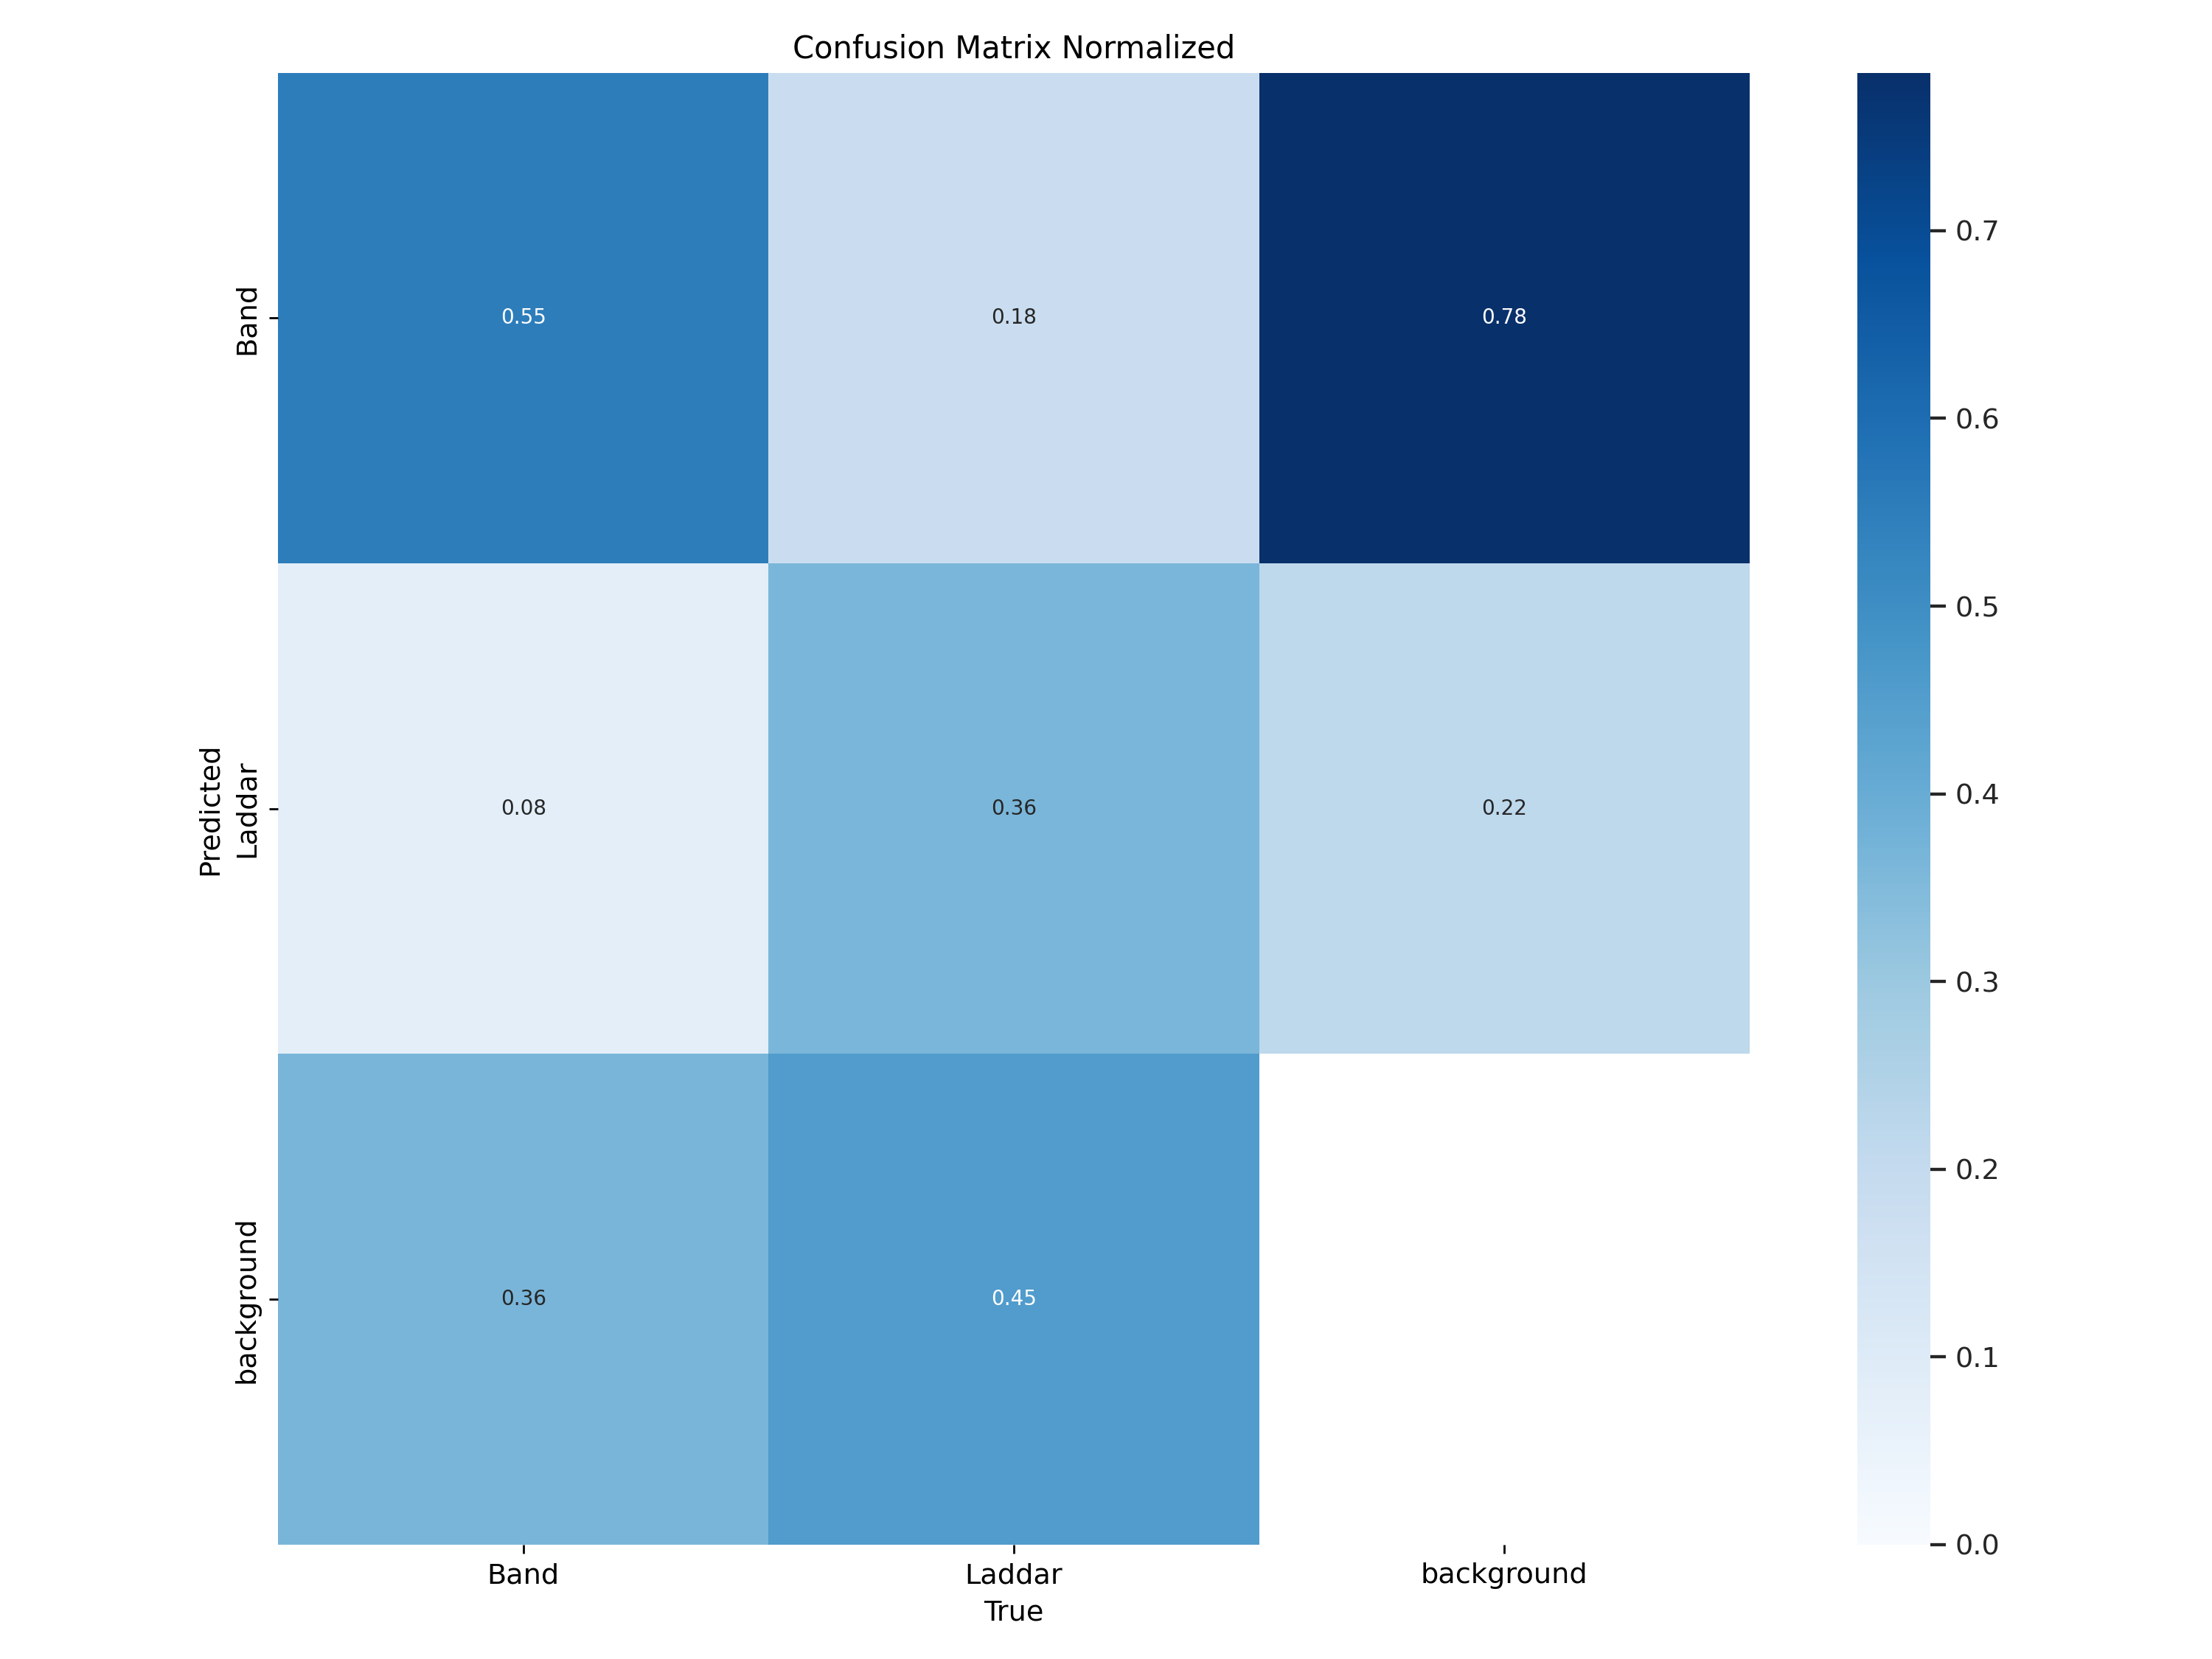

In [18]:
Image ("/content/runs/detect/train/confusion_matrix_normalized.png", width= 900)

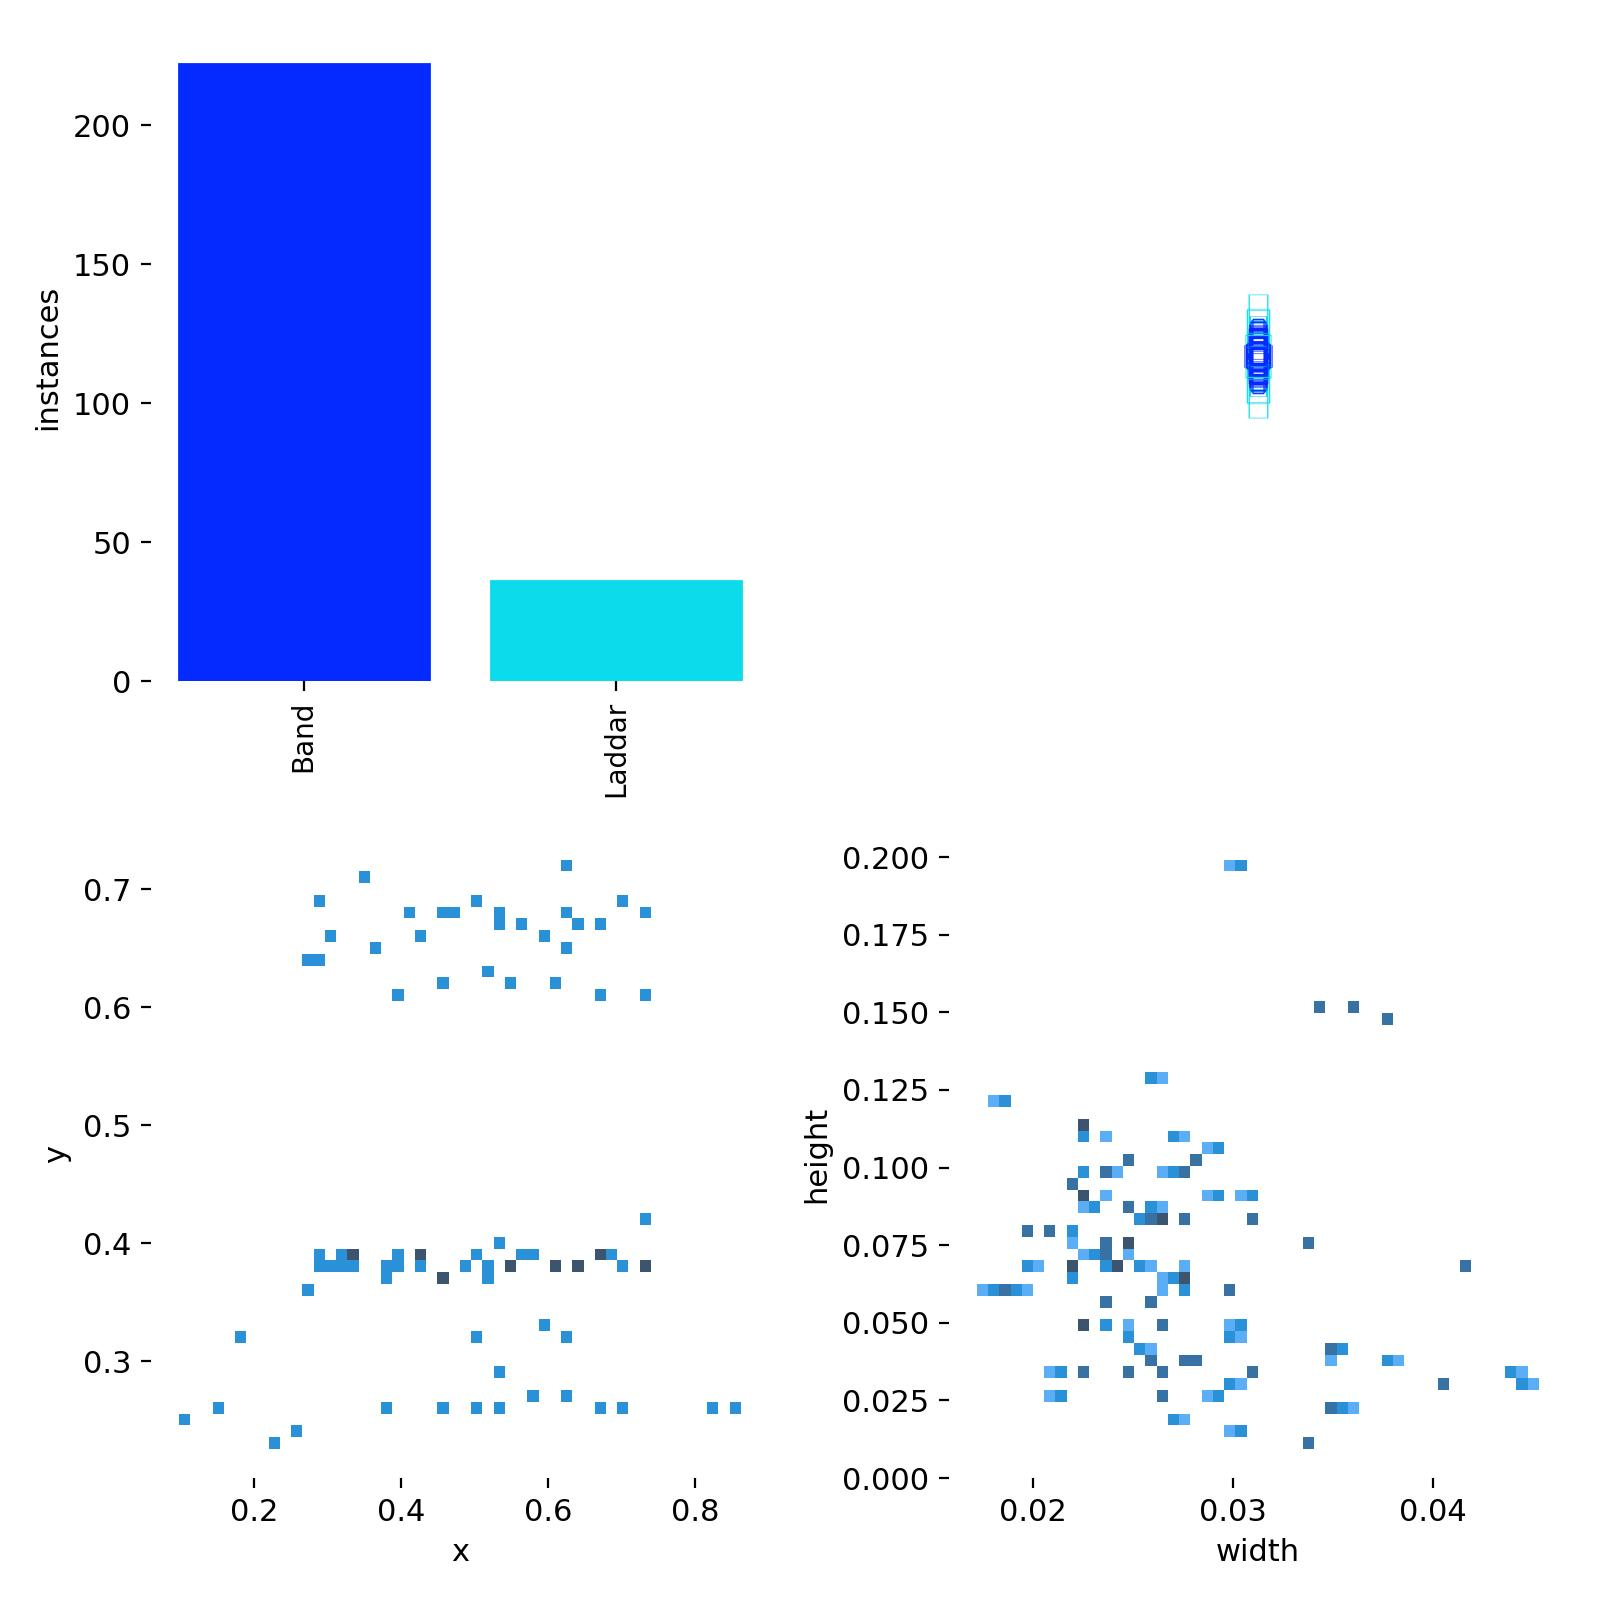

In [19]:
Image ("/content/runs/detect/train/labels.jpg", width= 900)

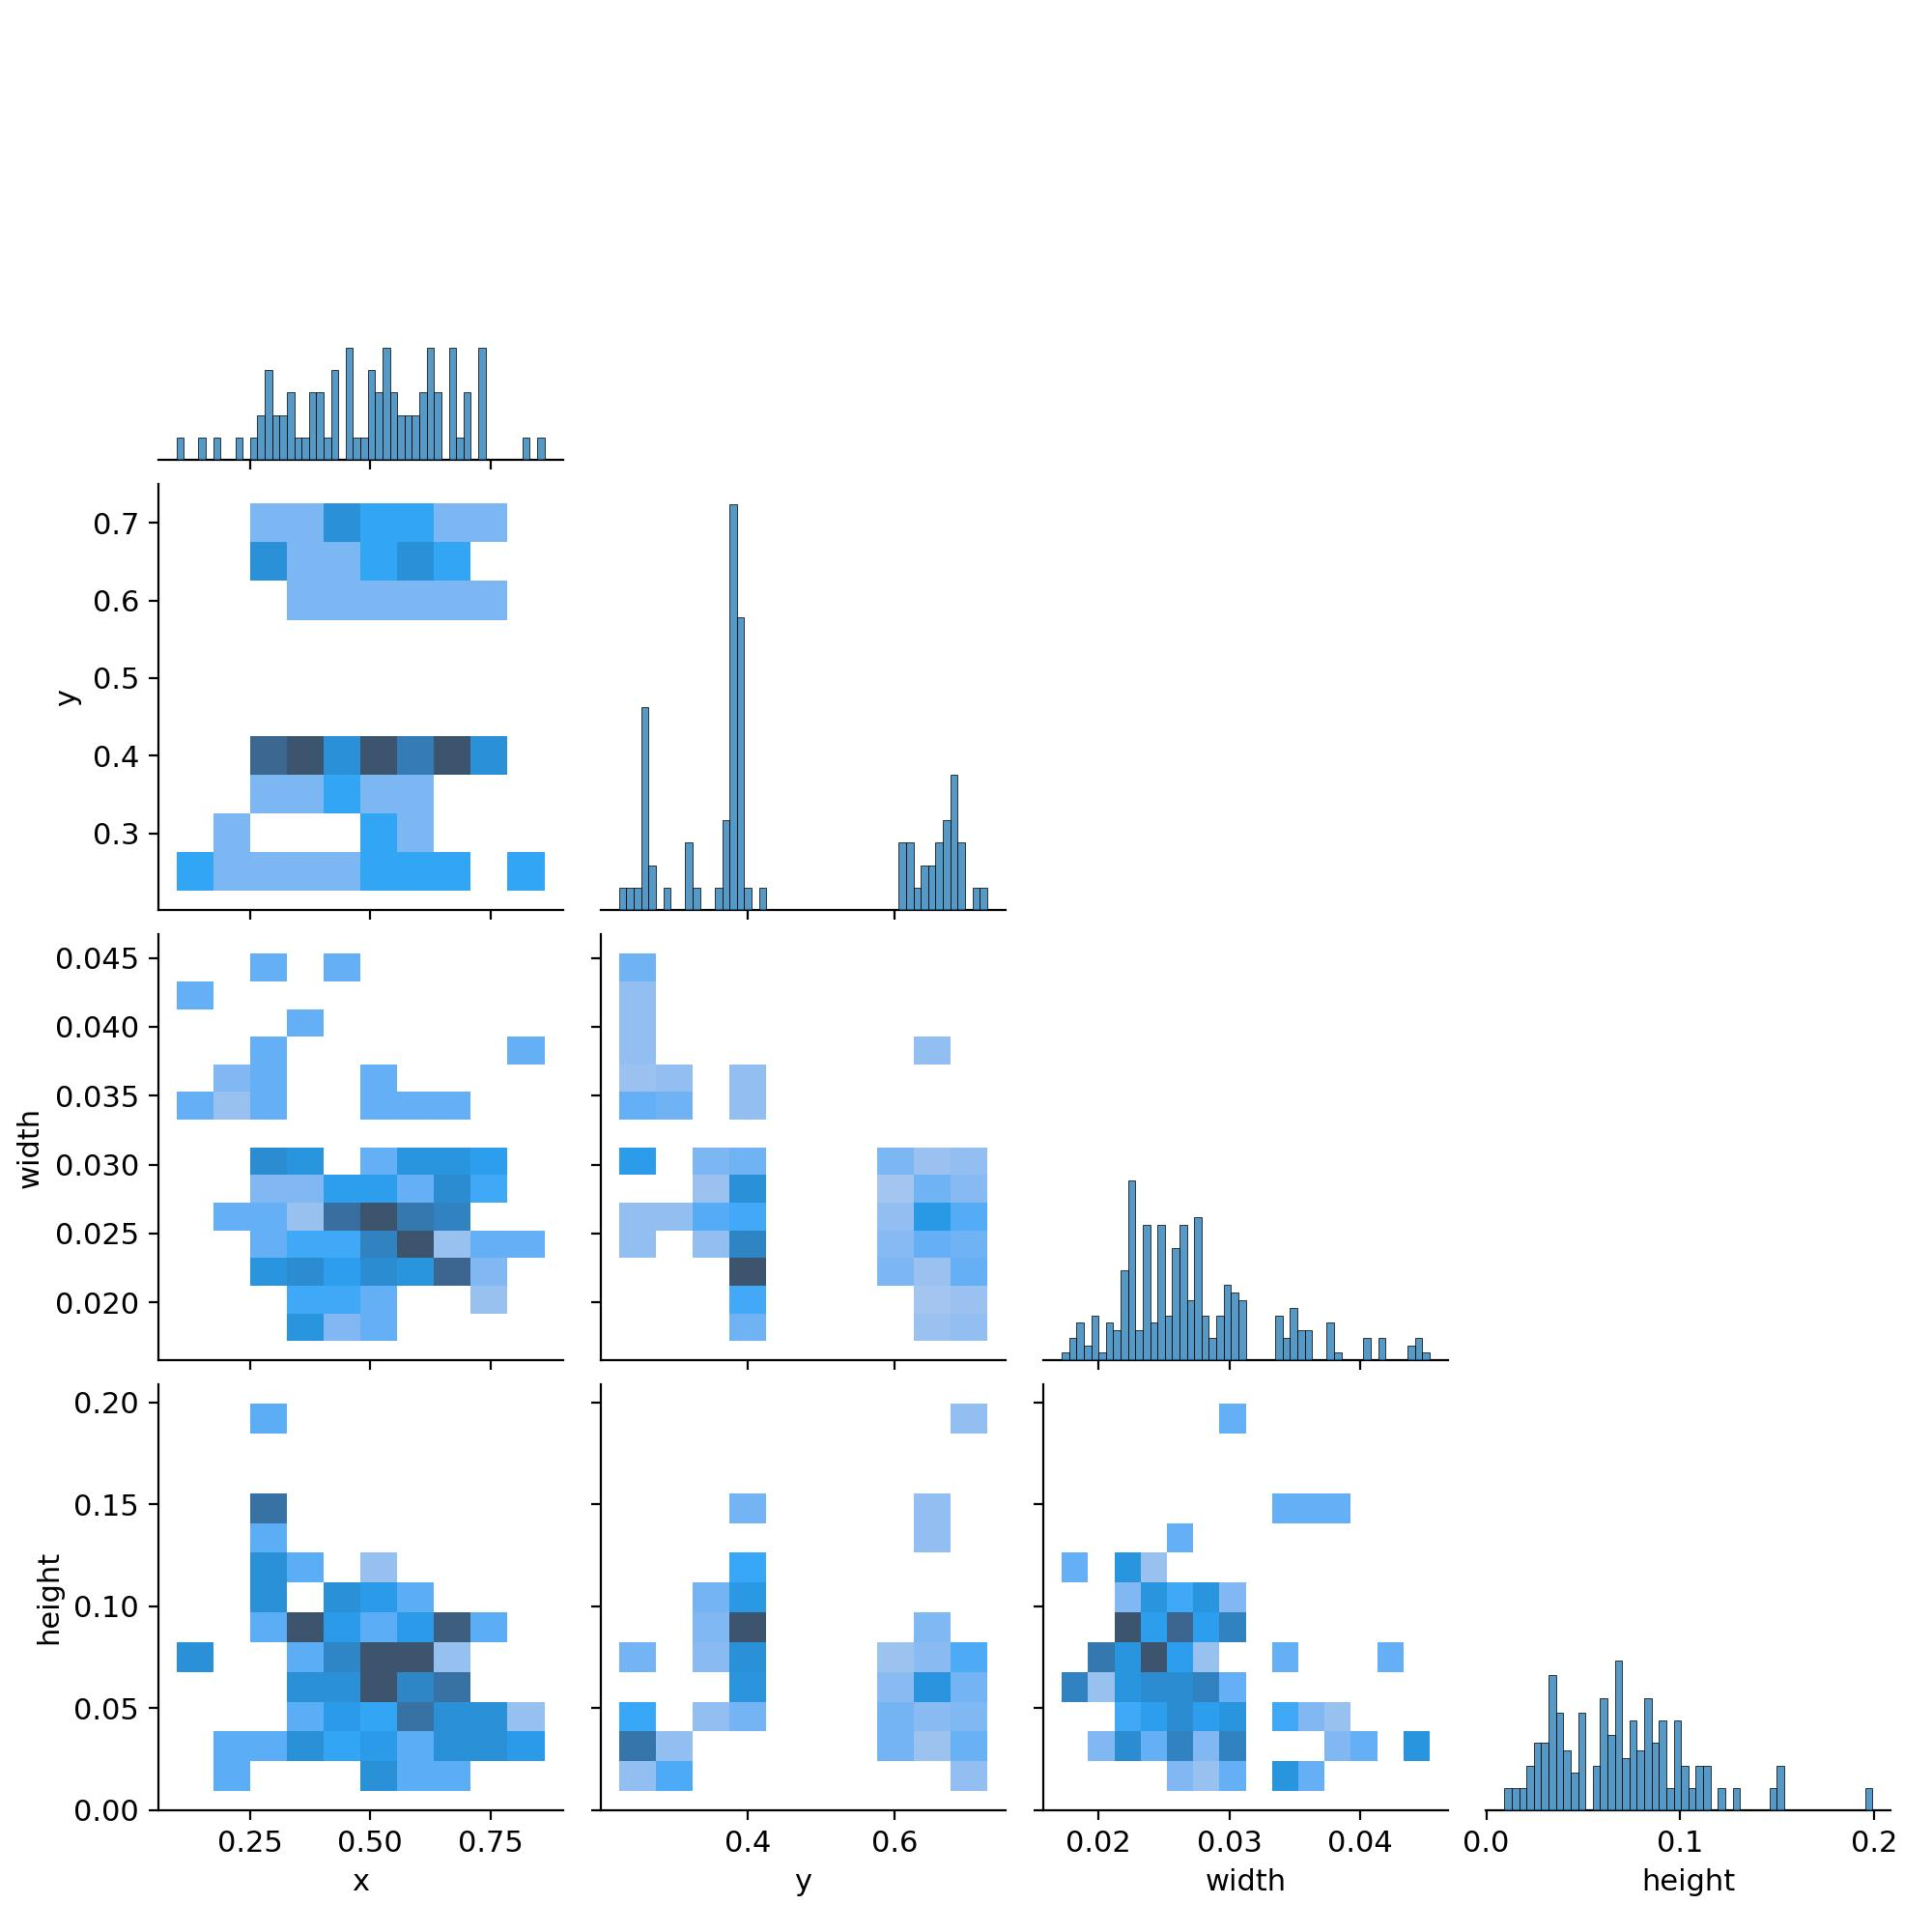

In [20]:
Image ("/content/runs/detect/train/labels_correlogram.jpg", width= 900)

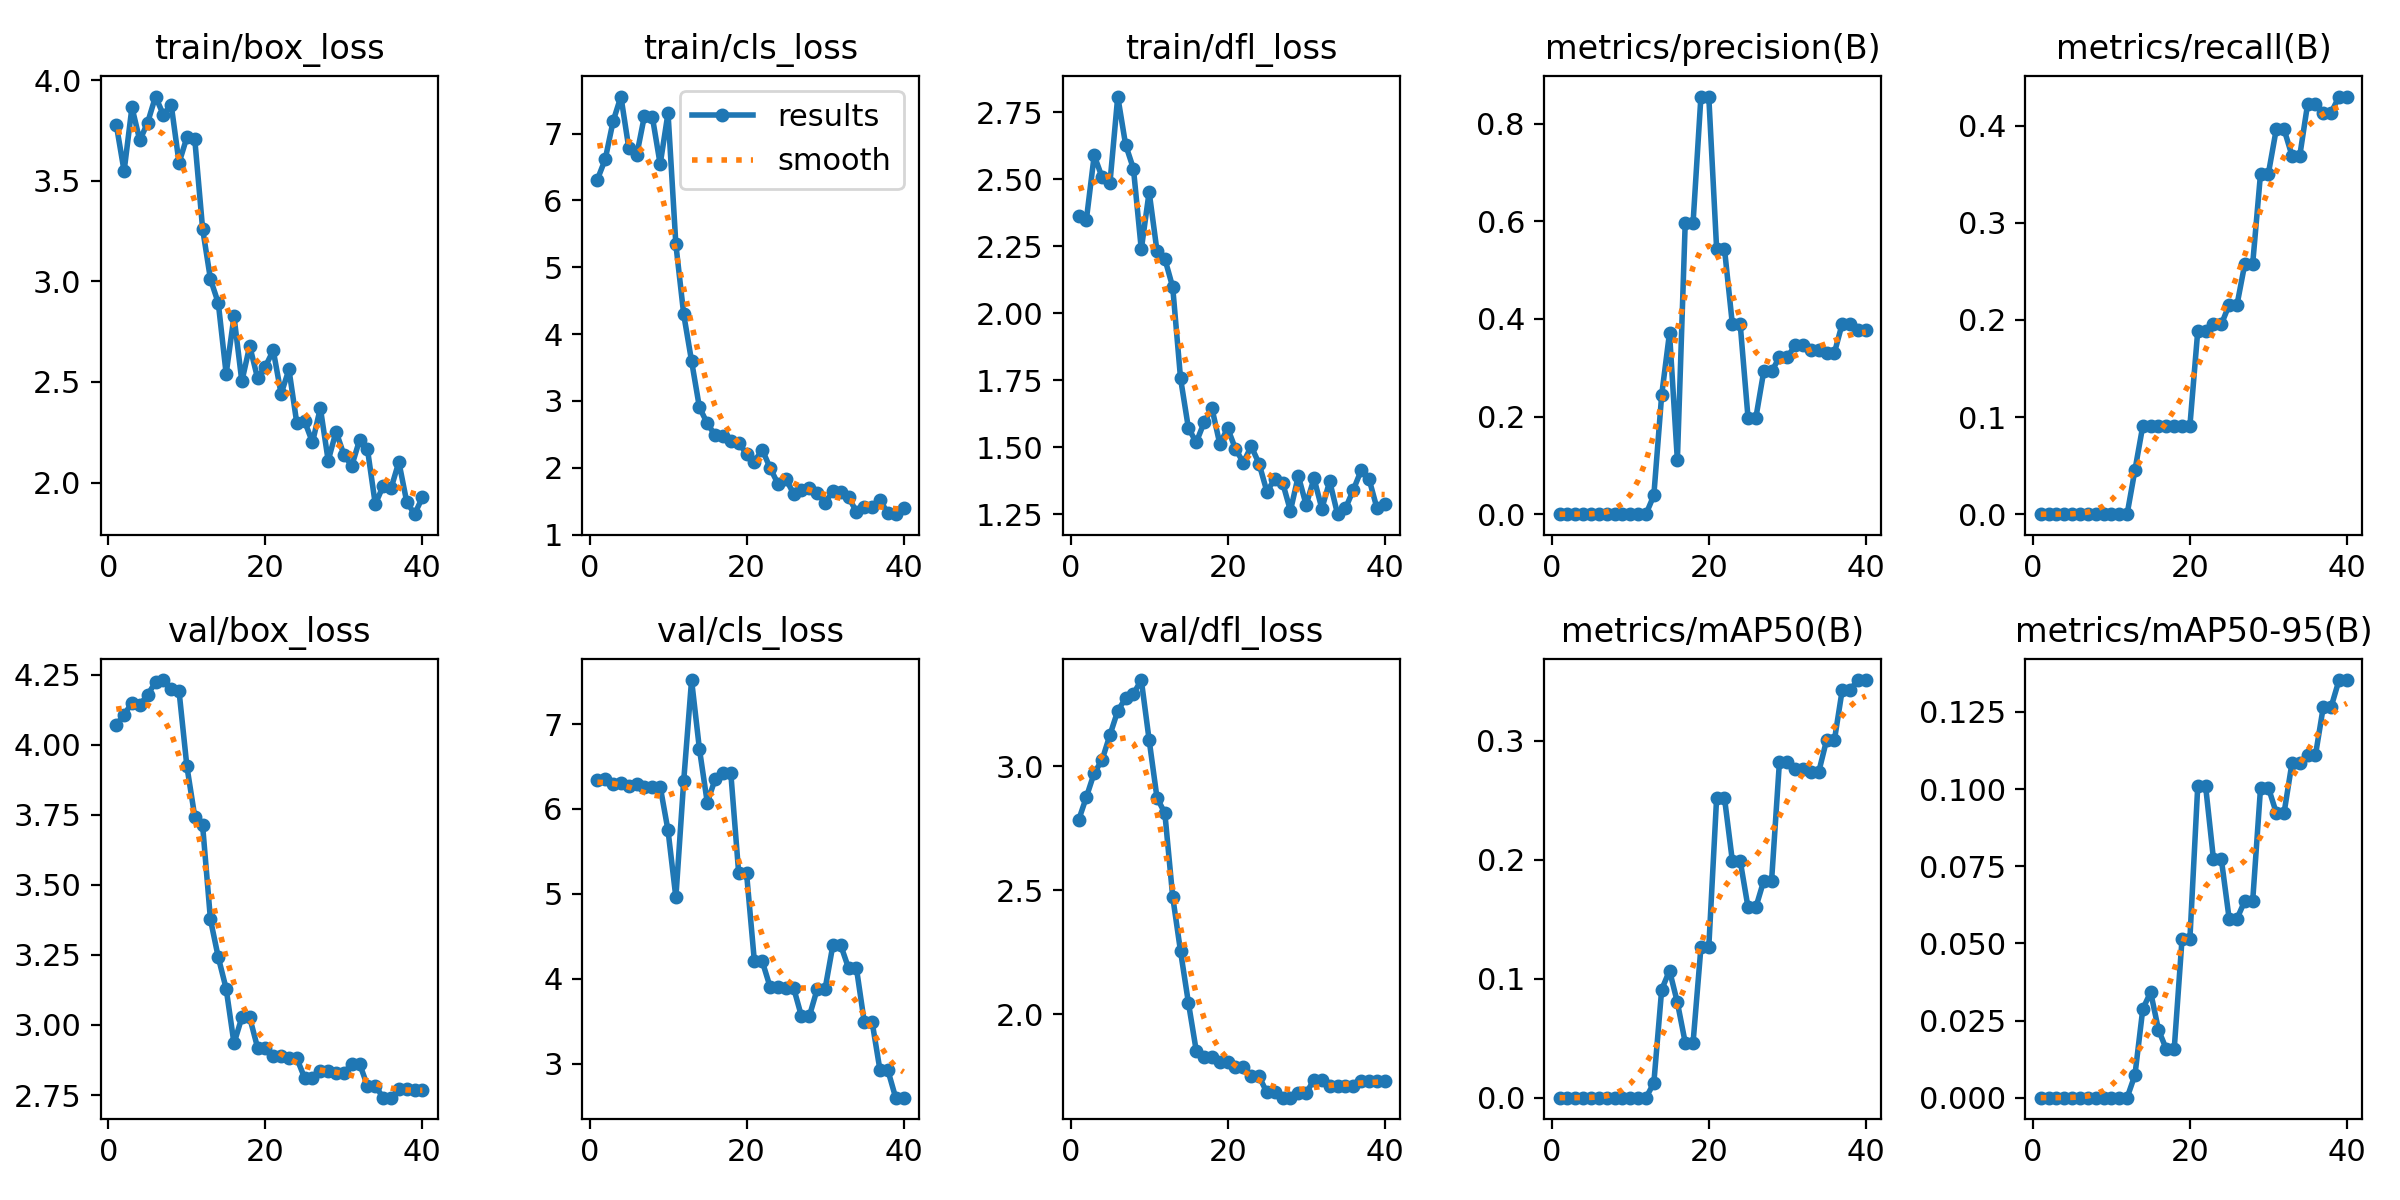

In [21]:
Image ("/content/runs/detect/train/results.png", width= 900)

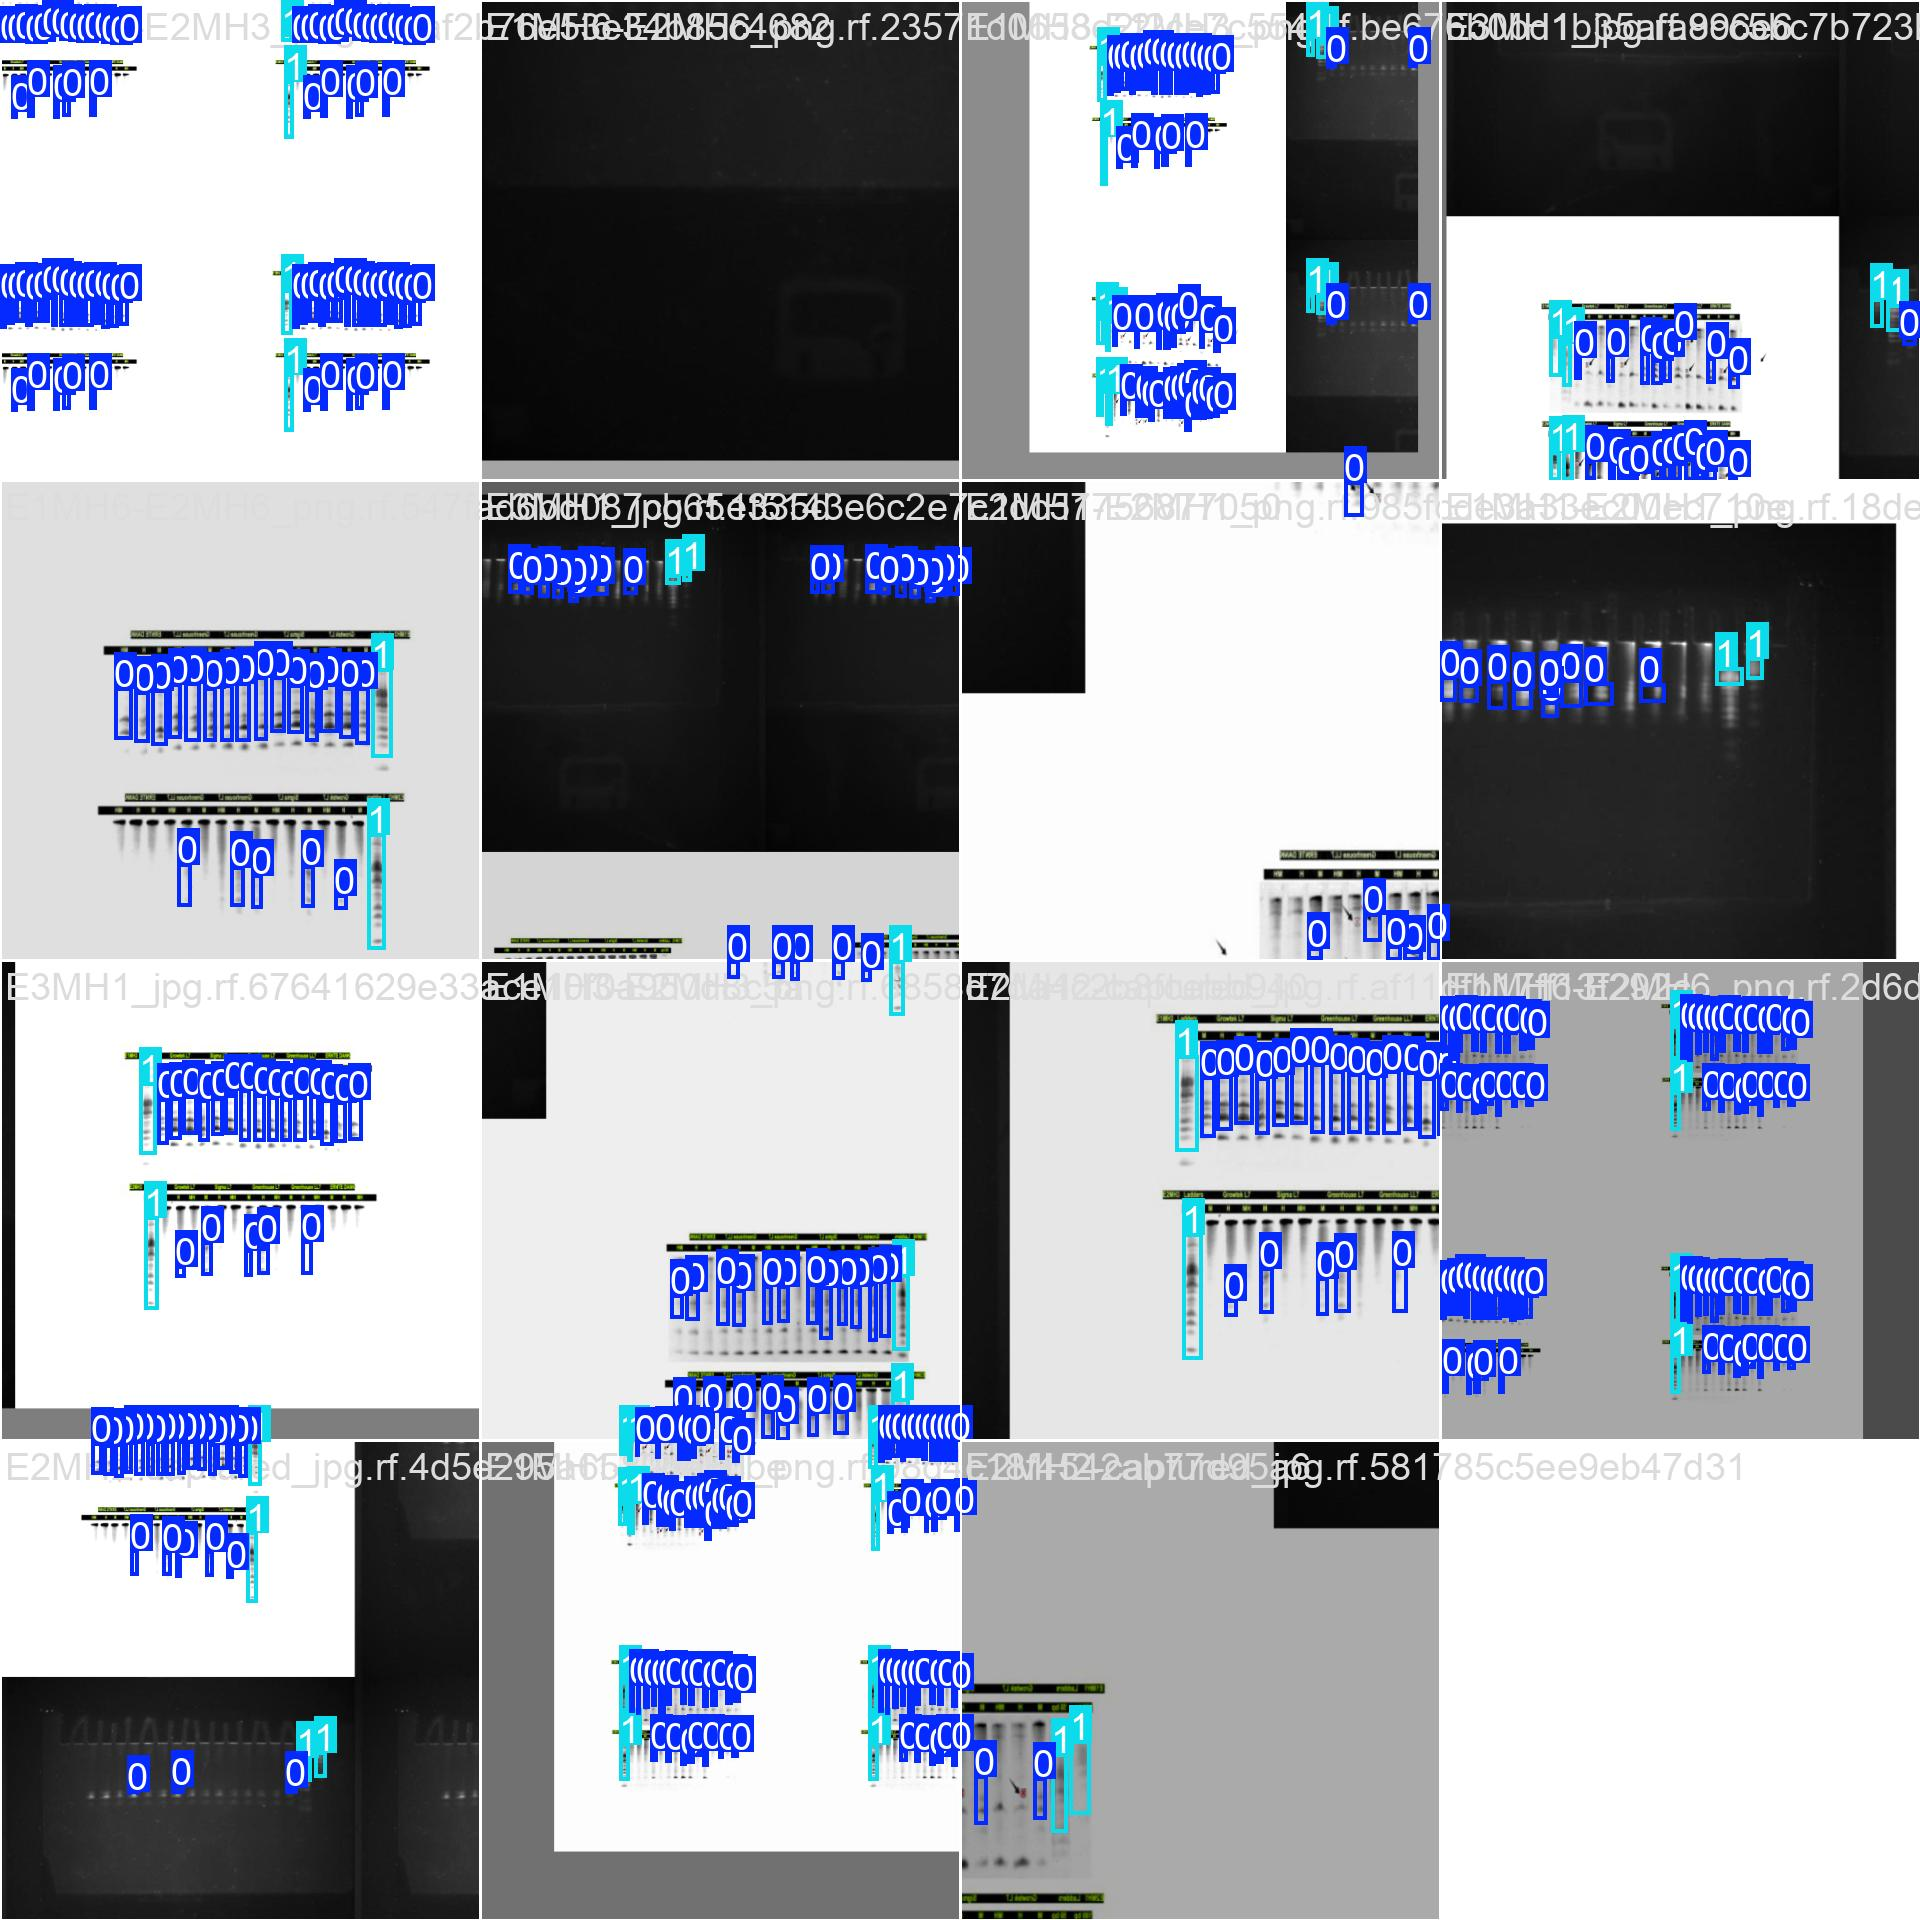

In [22]:
Image ("/content/runs/detect/train/train_batch0.jpg", width= 900)

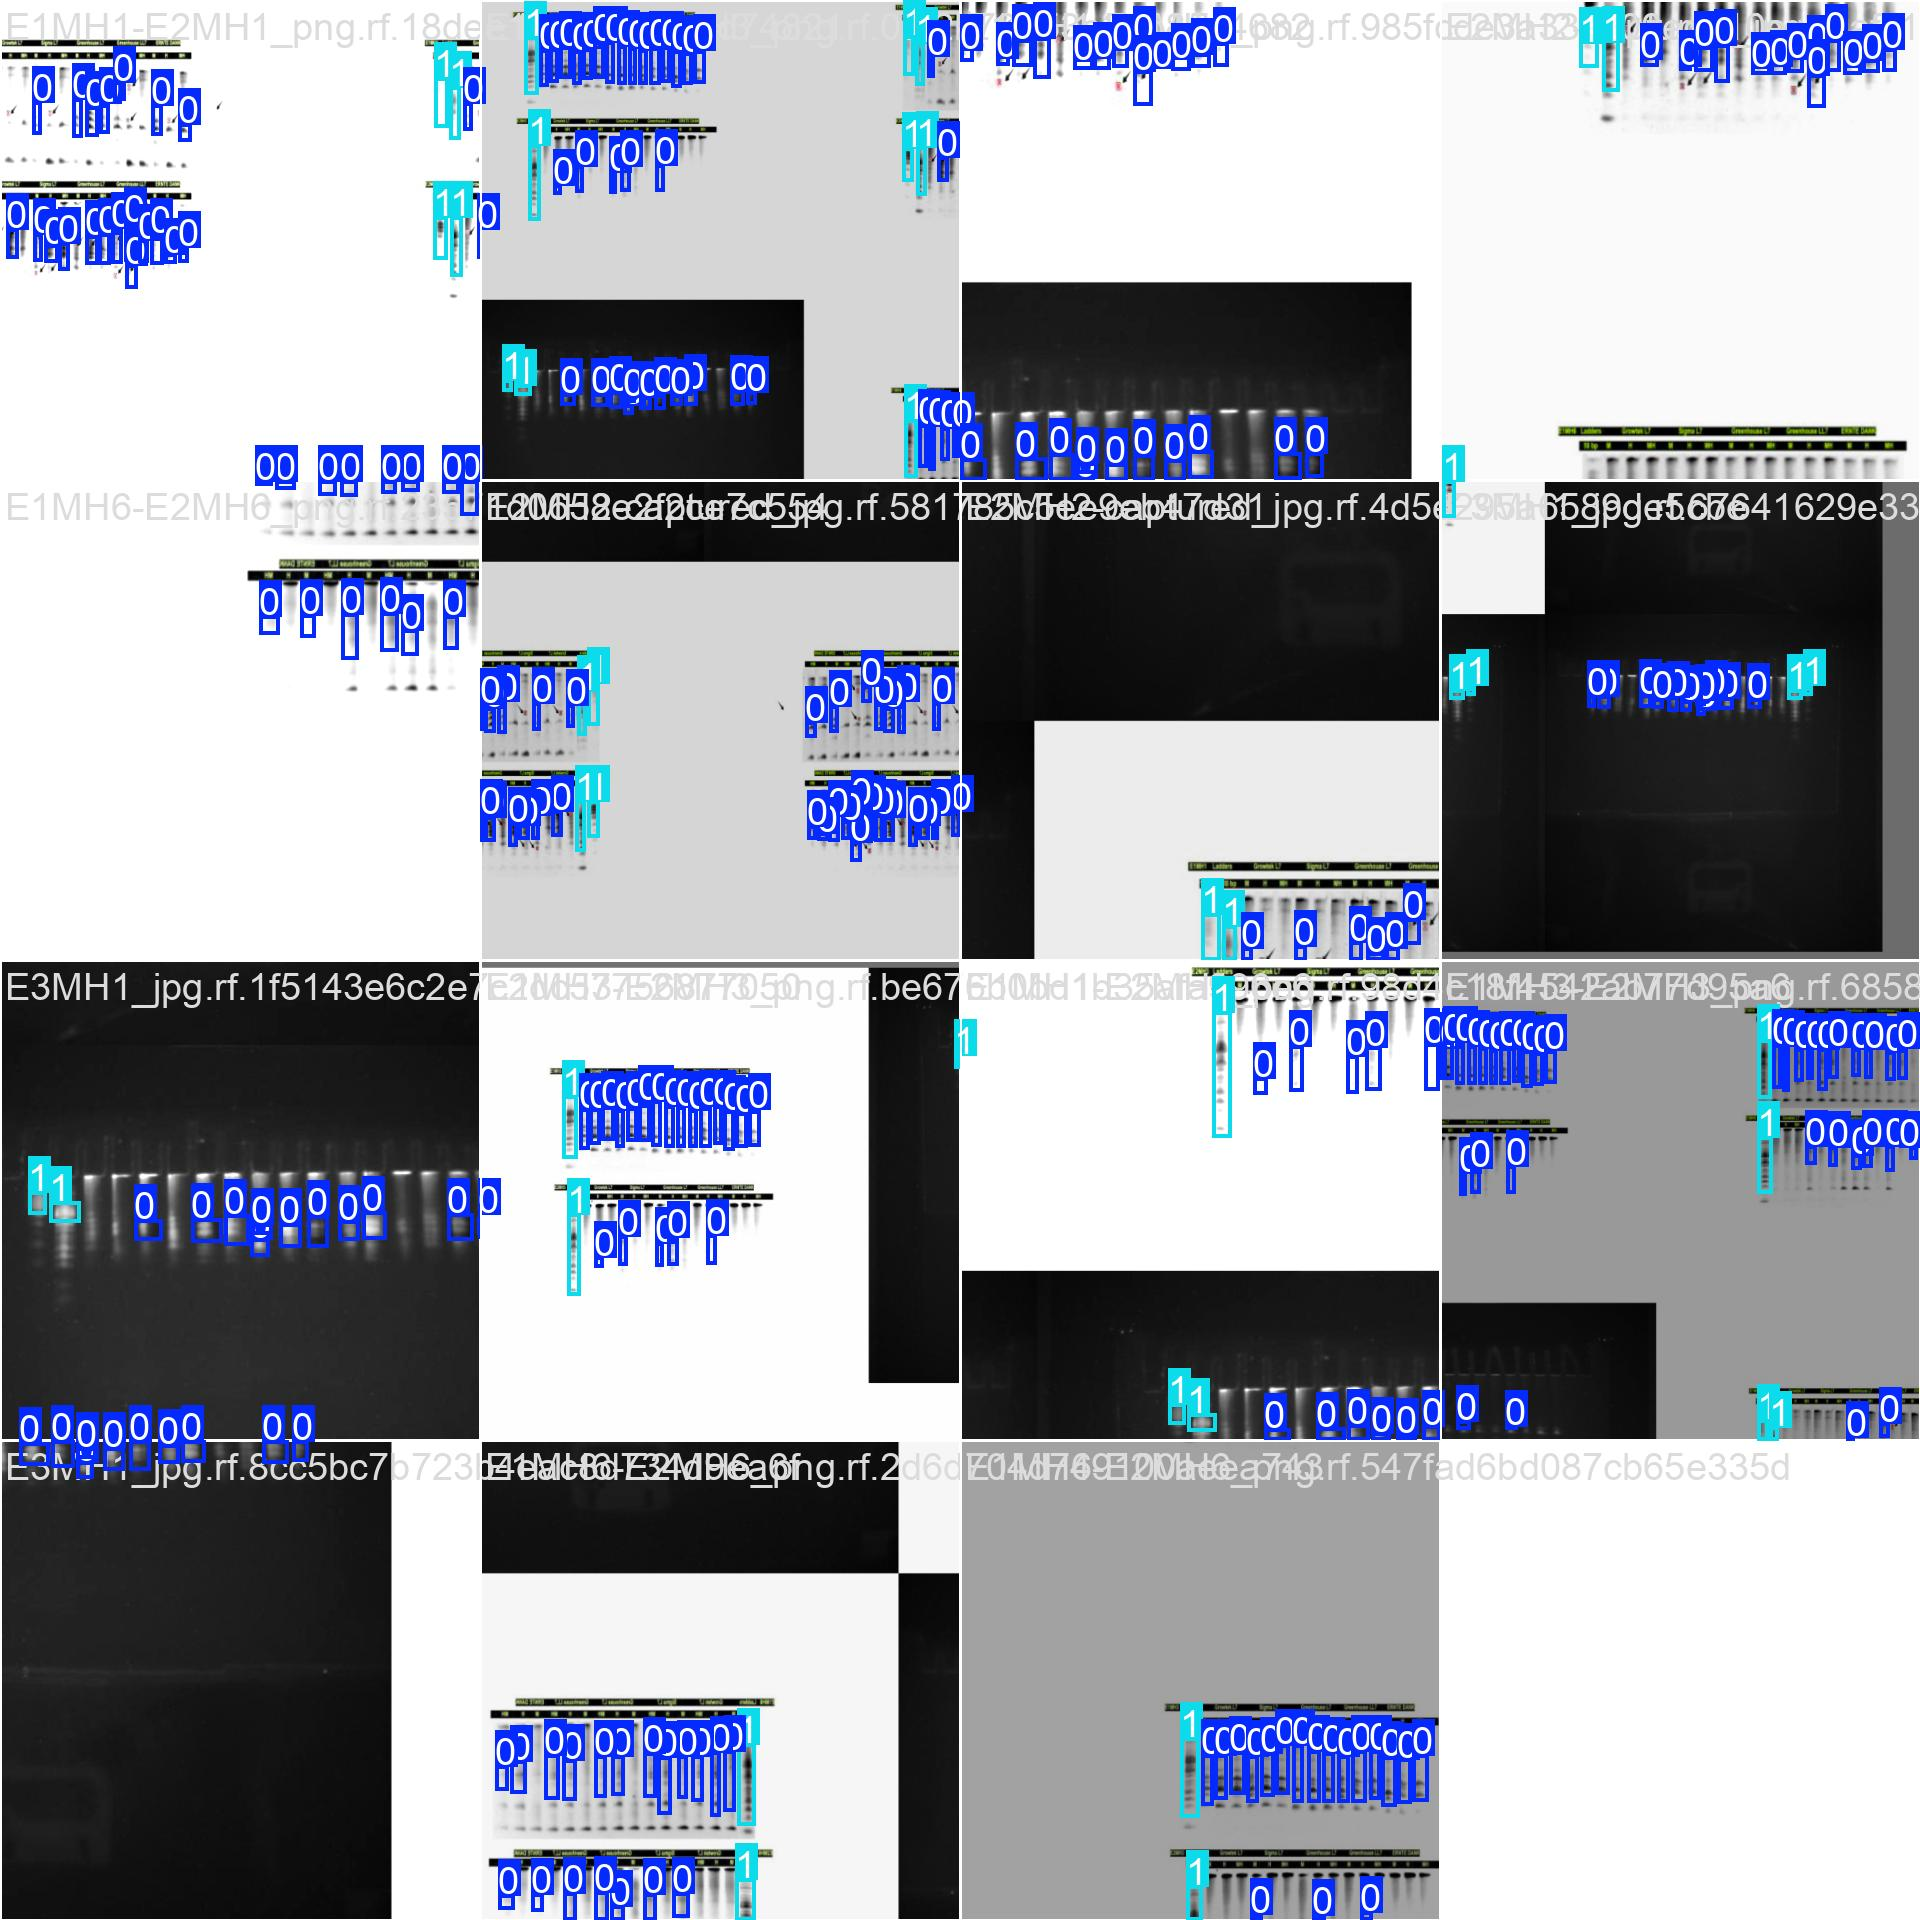

In [23]:
Image ("/content/runs/detect/train/train_batch1.jpg", width= 900)

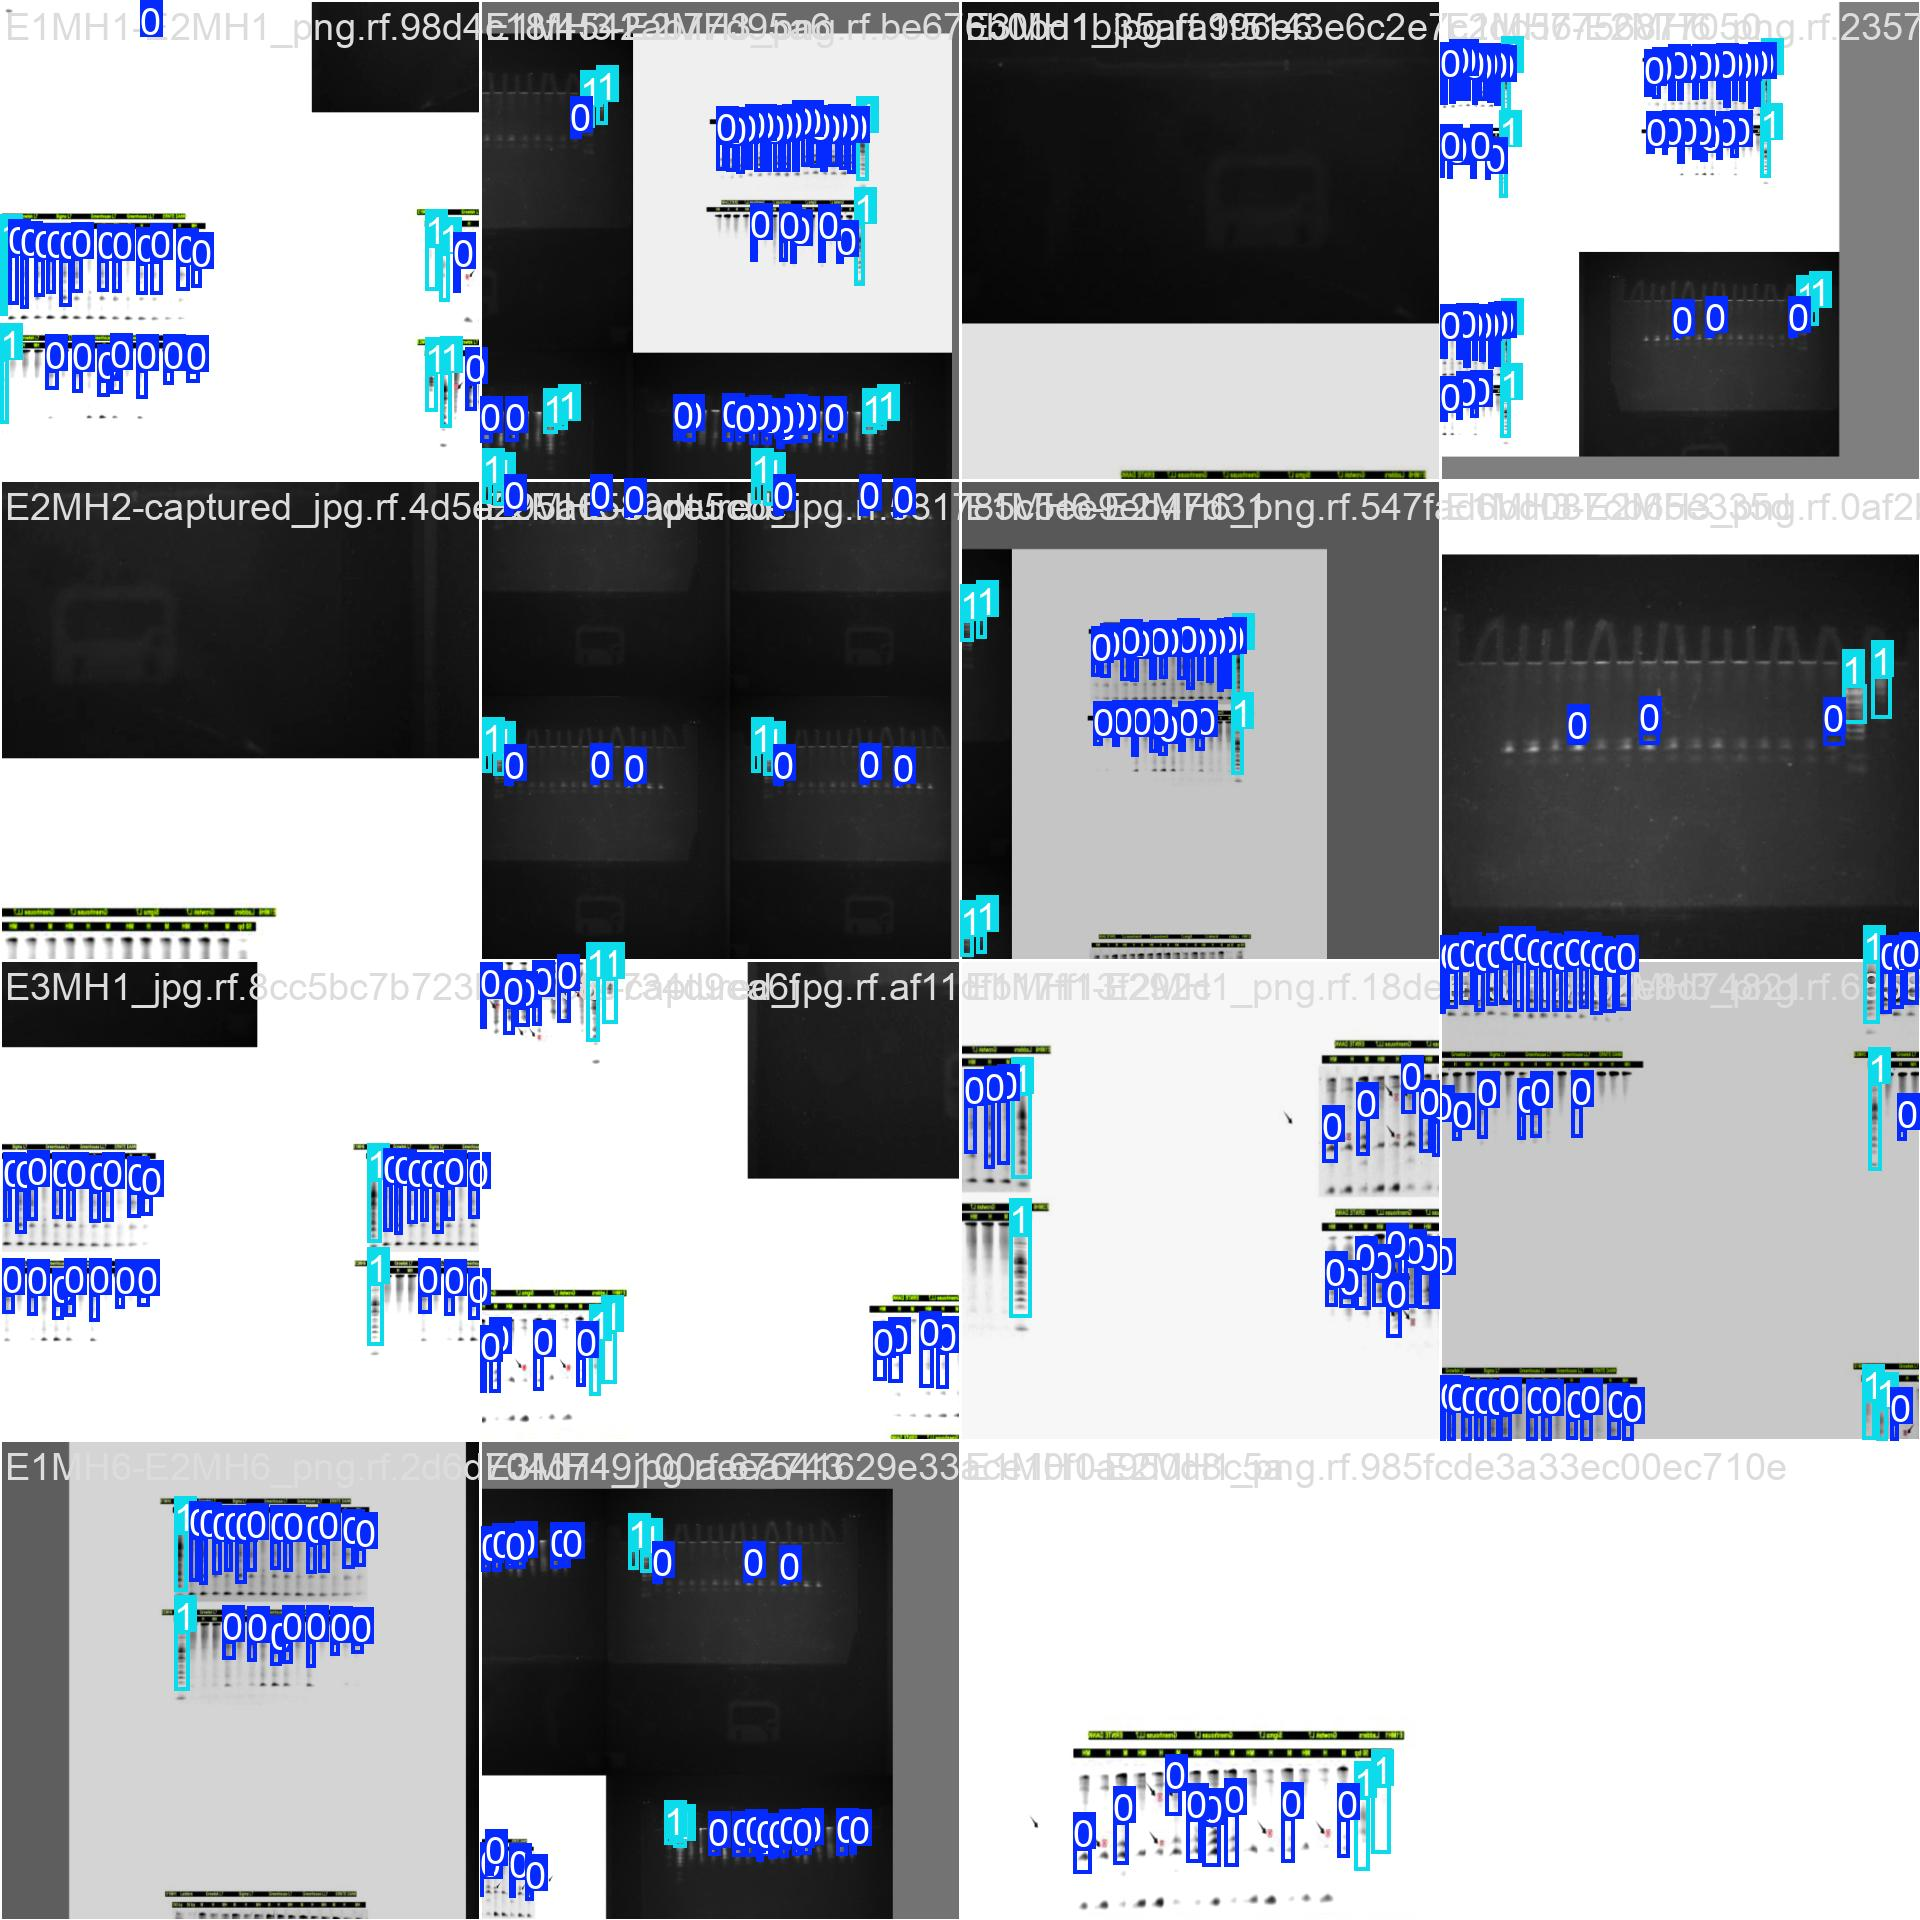

In [24]:
Image ("/content/runs/detect/train/train_batch2.jpg", width= 900)

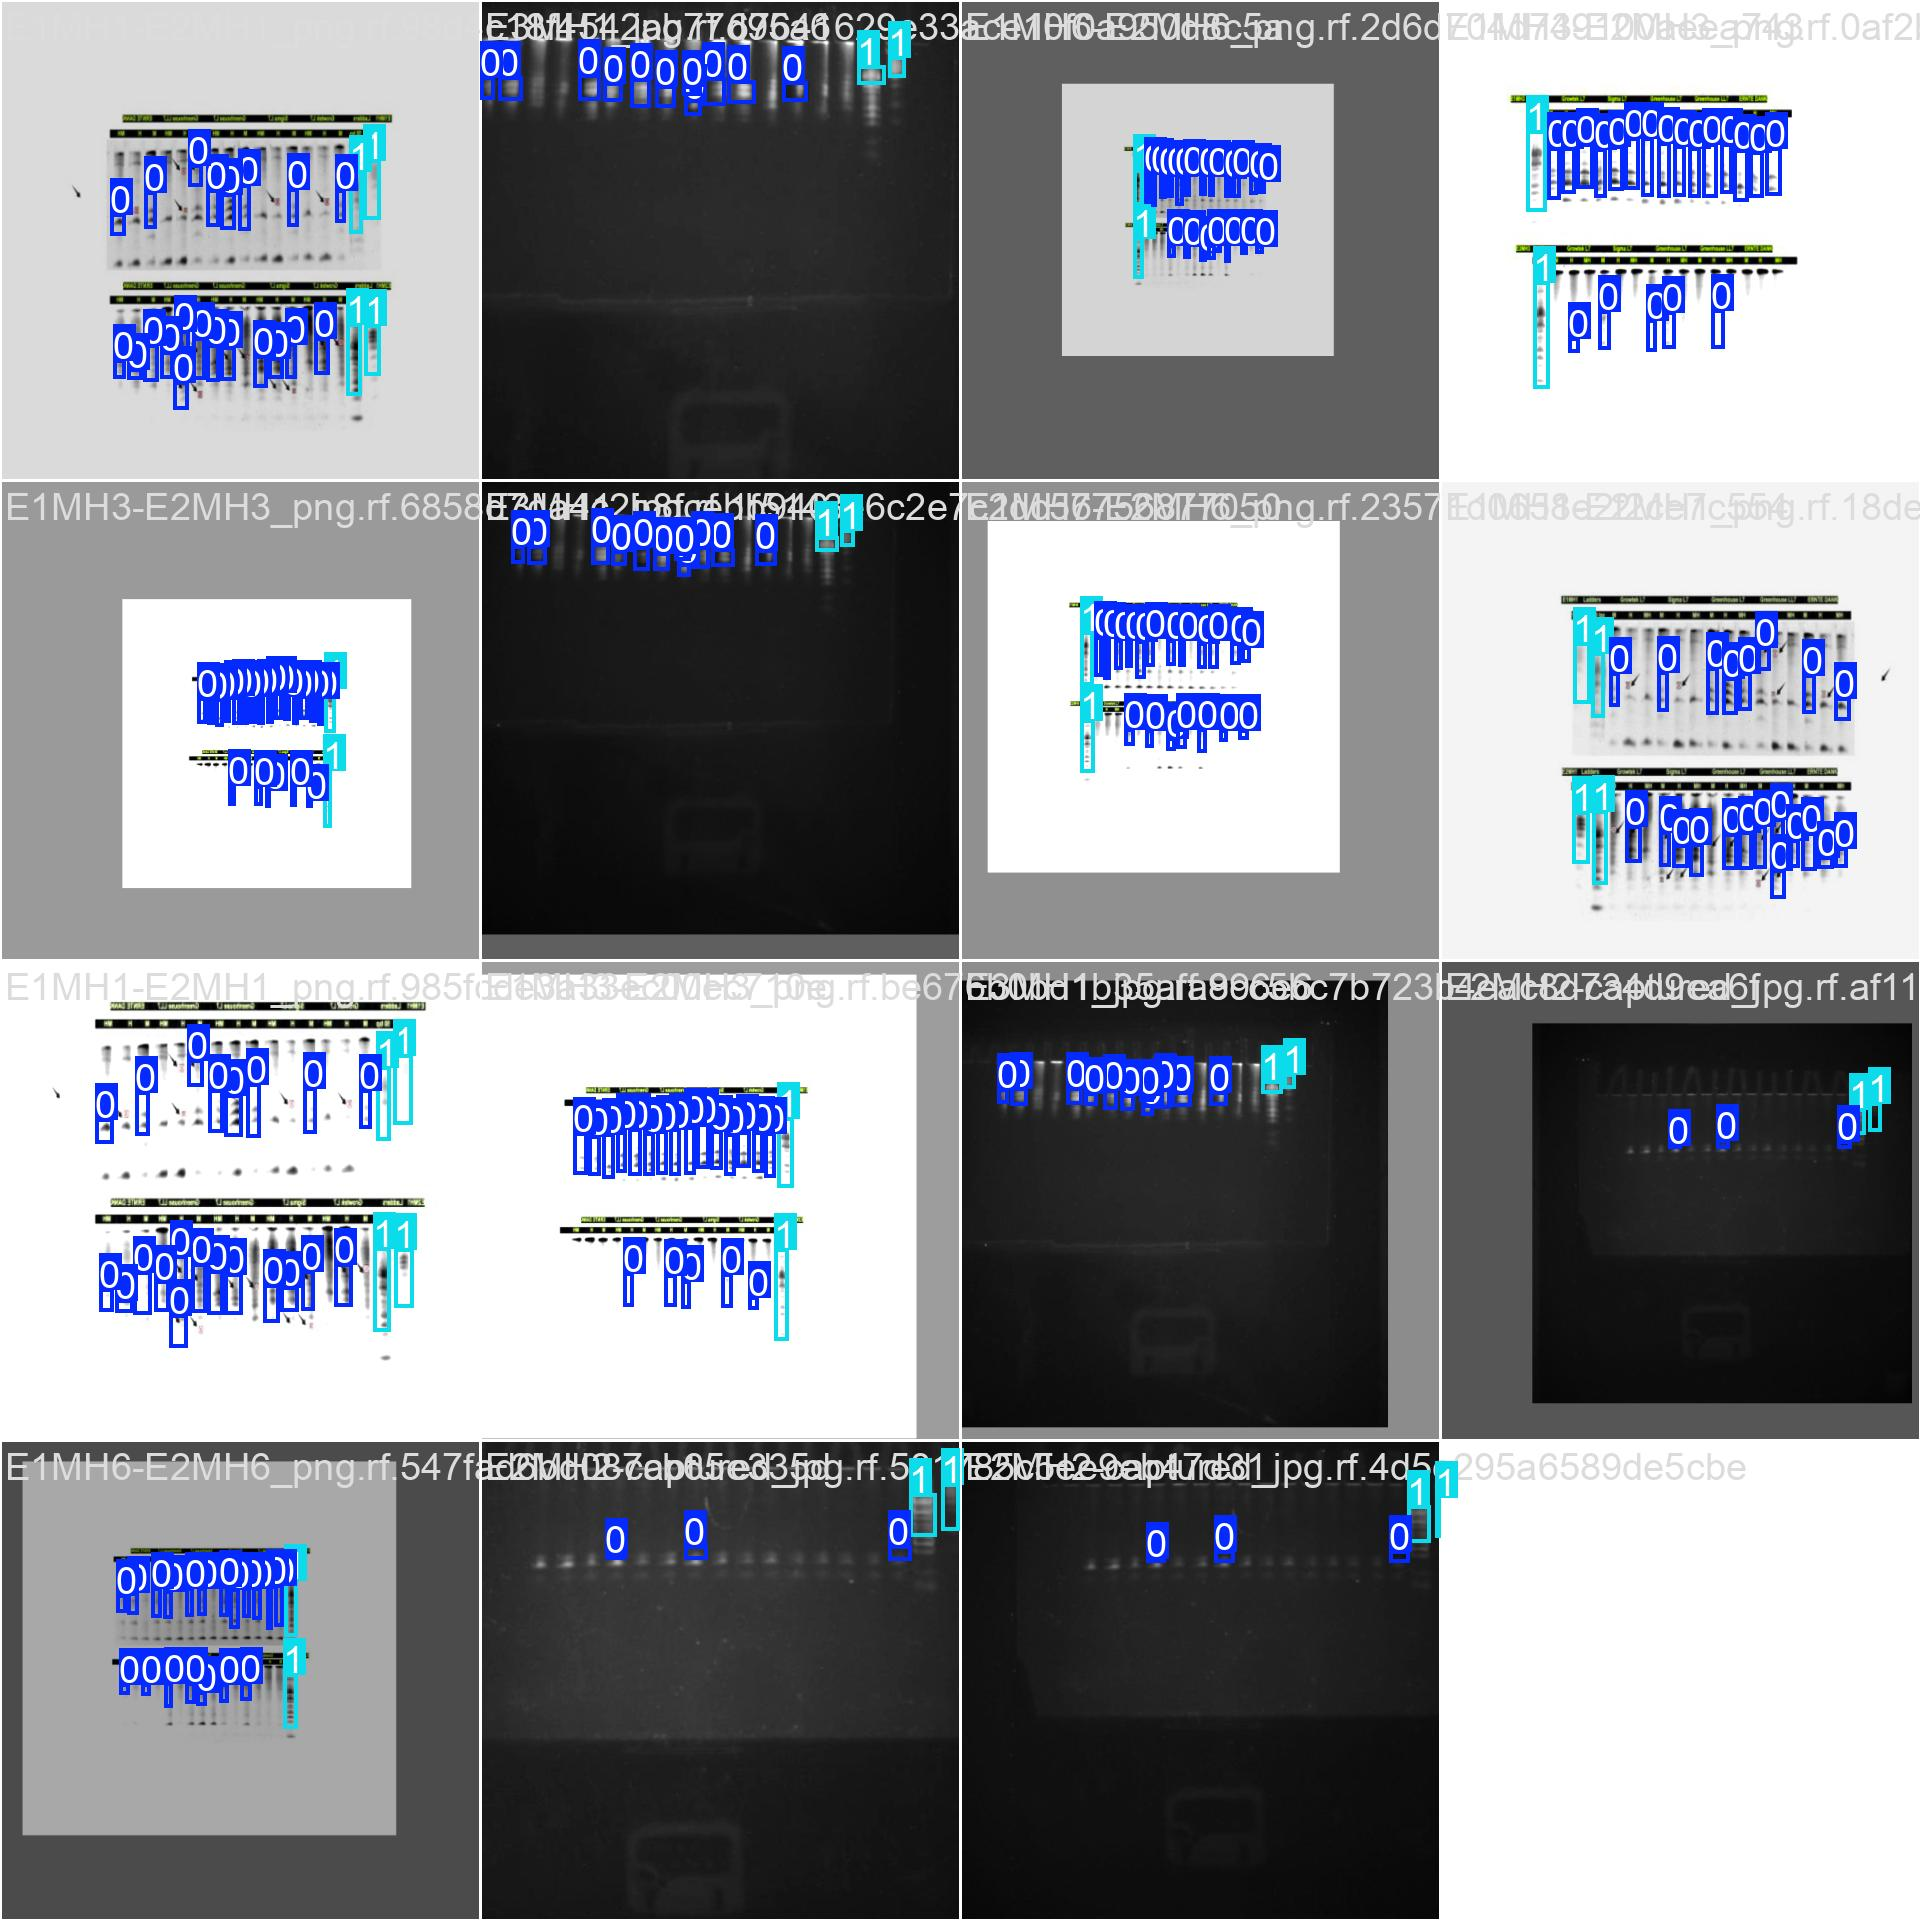

In [25]:
Image ("/content/runs/detect/train/train_batch30.jpg", width= 900)

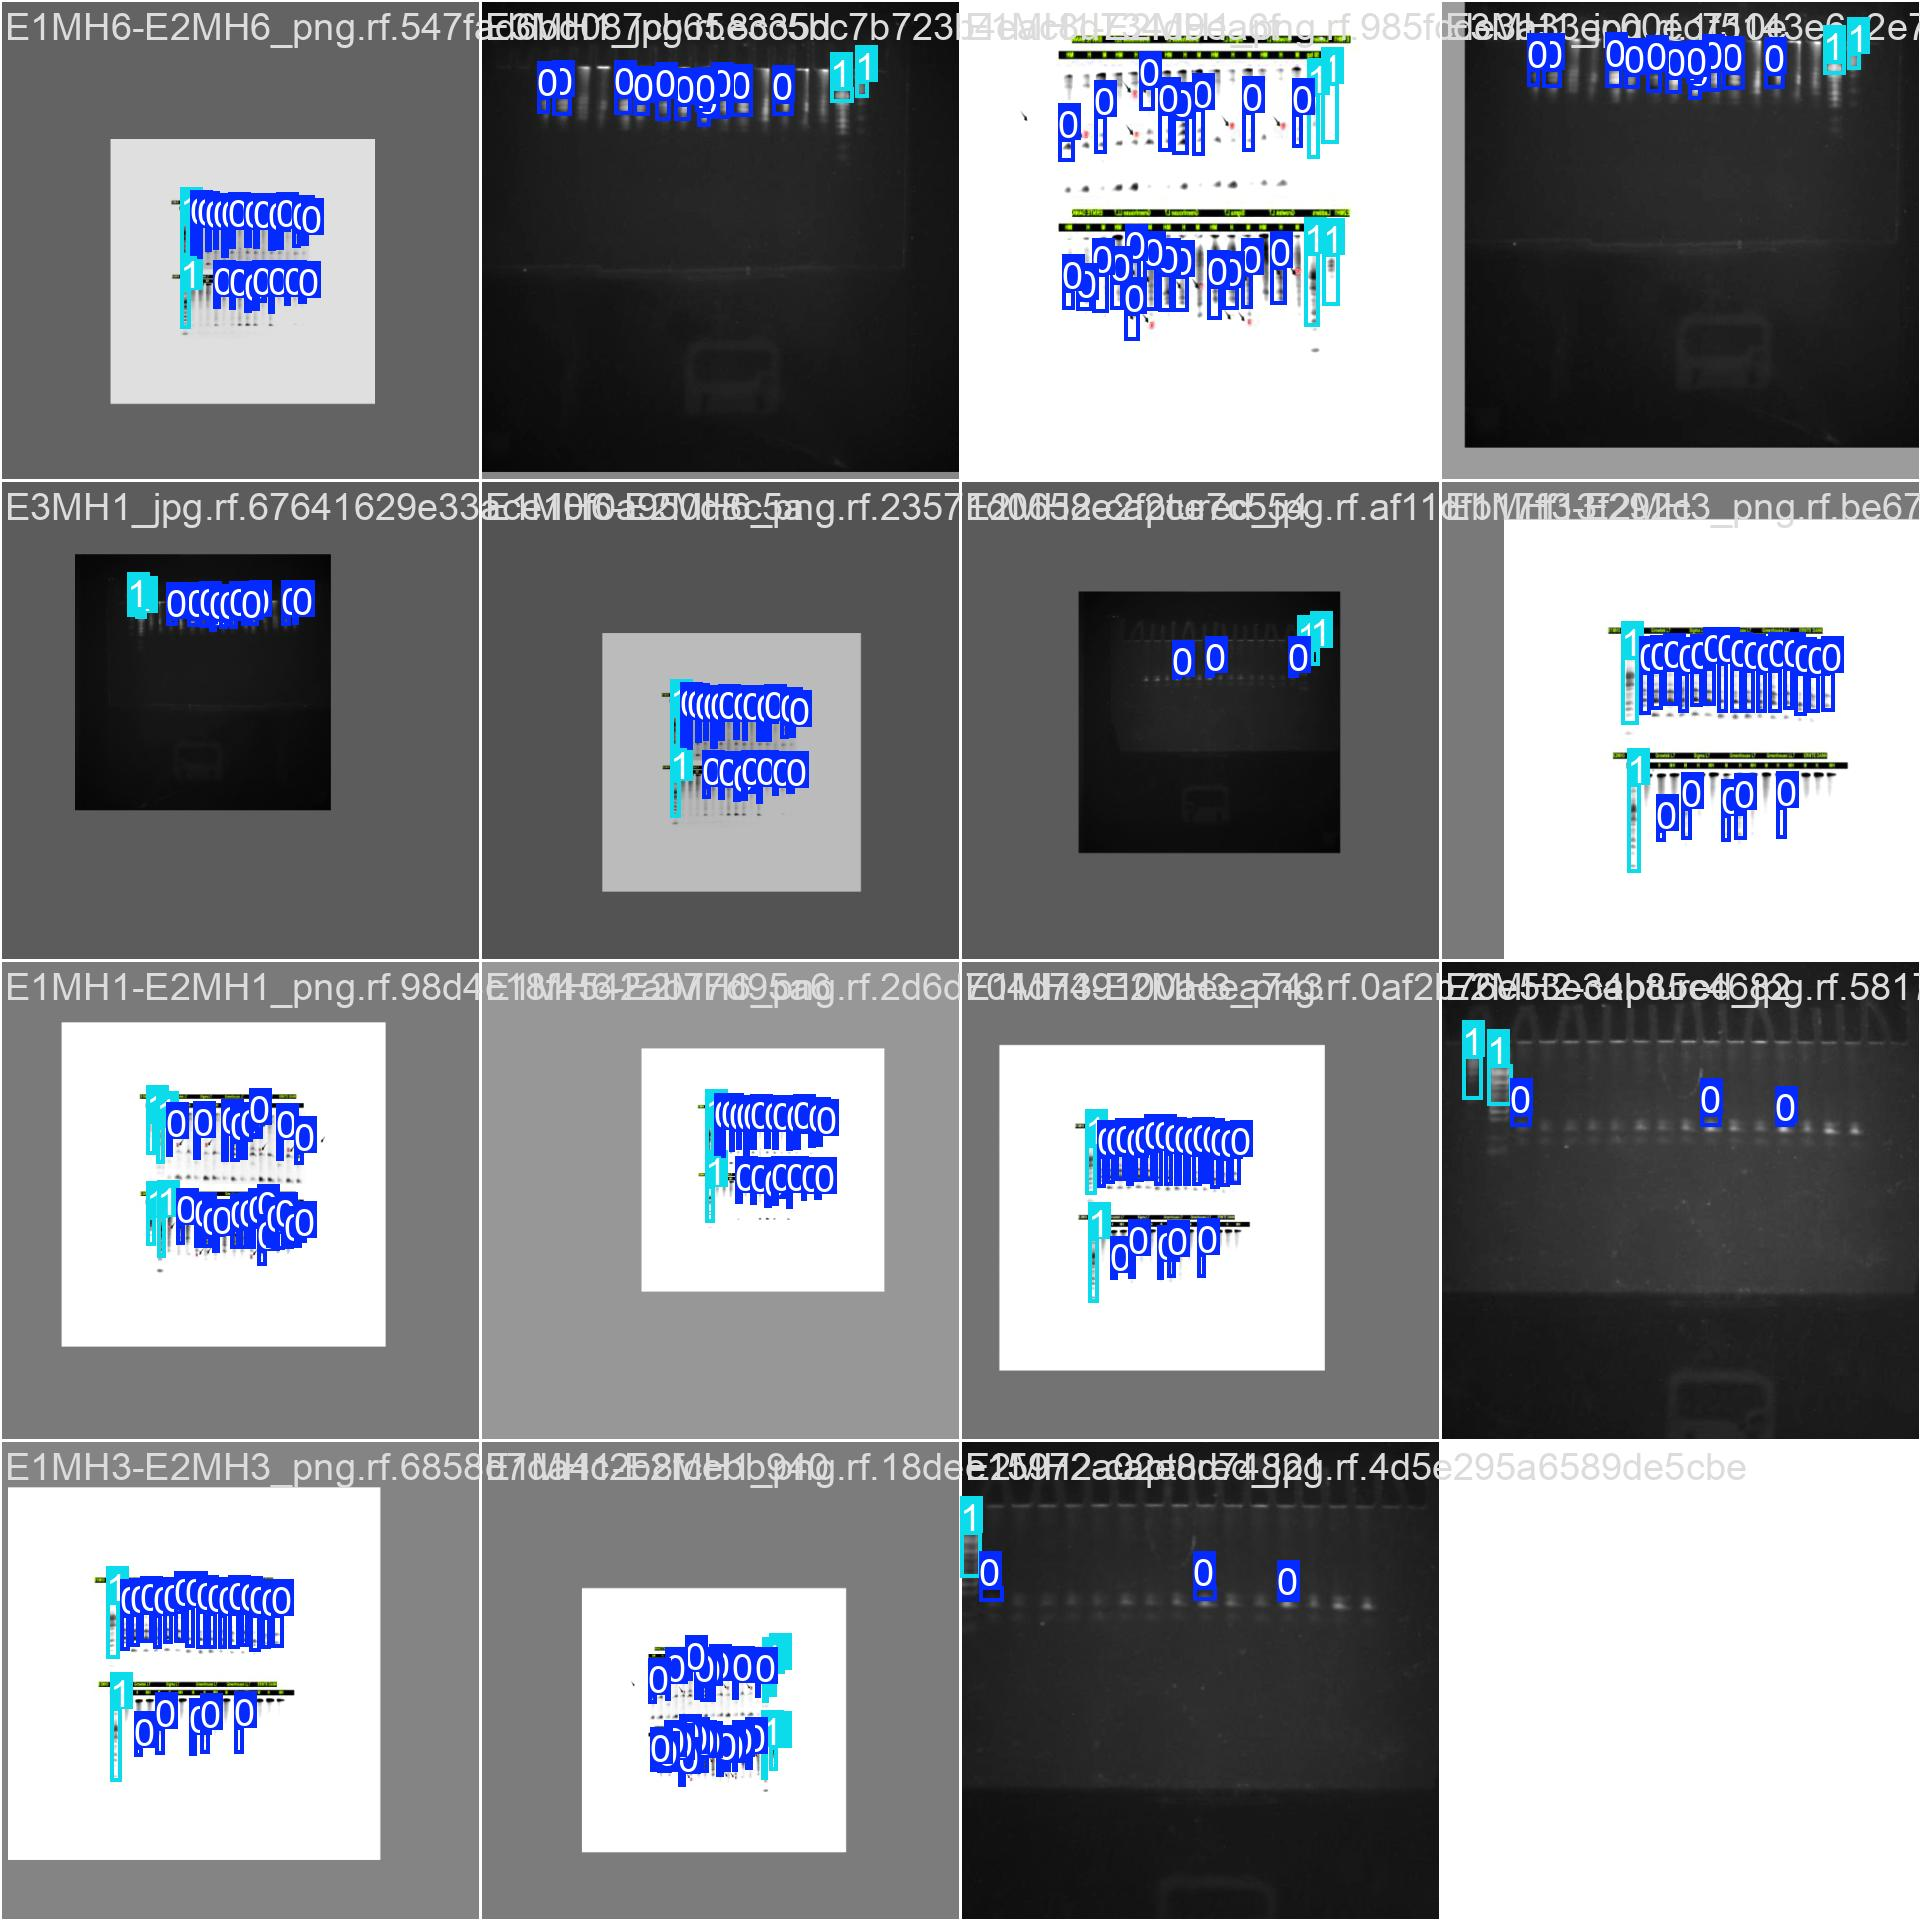

In [26]:
Image ("/content/runs/detect/train/train_batch31.jpg", width= 900)

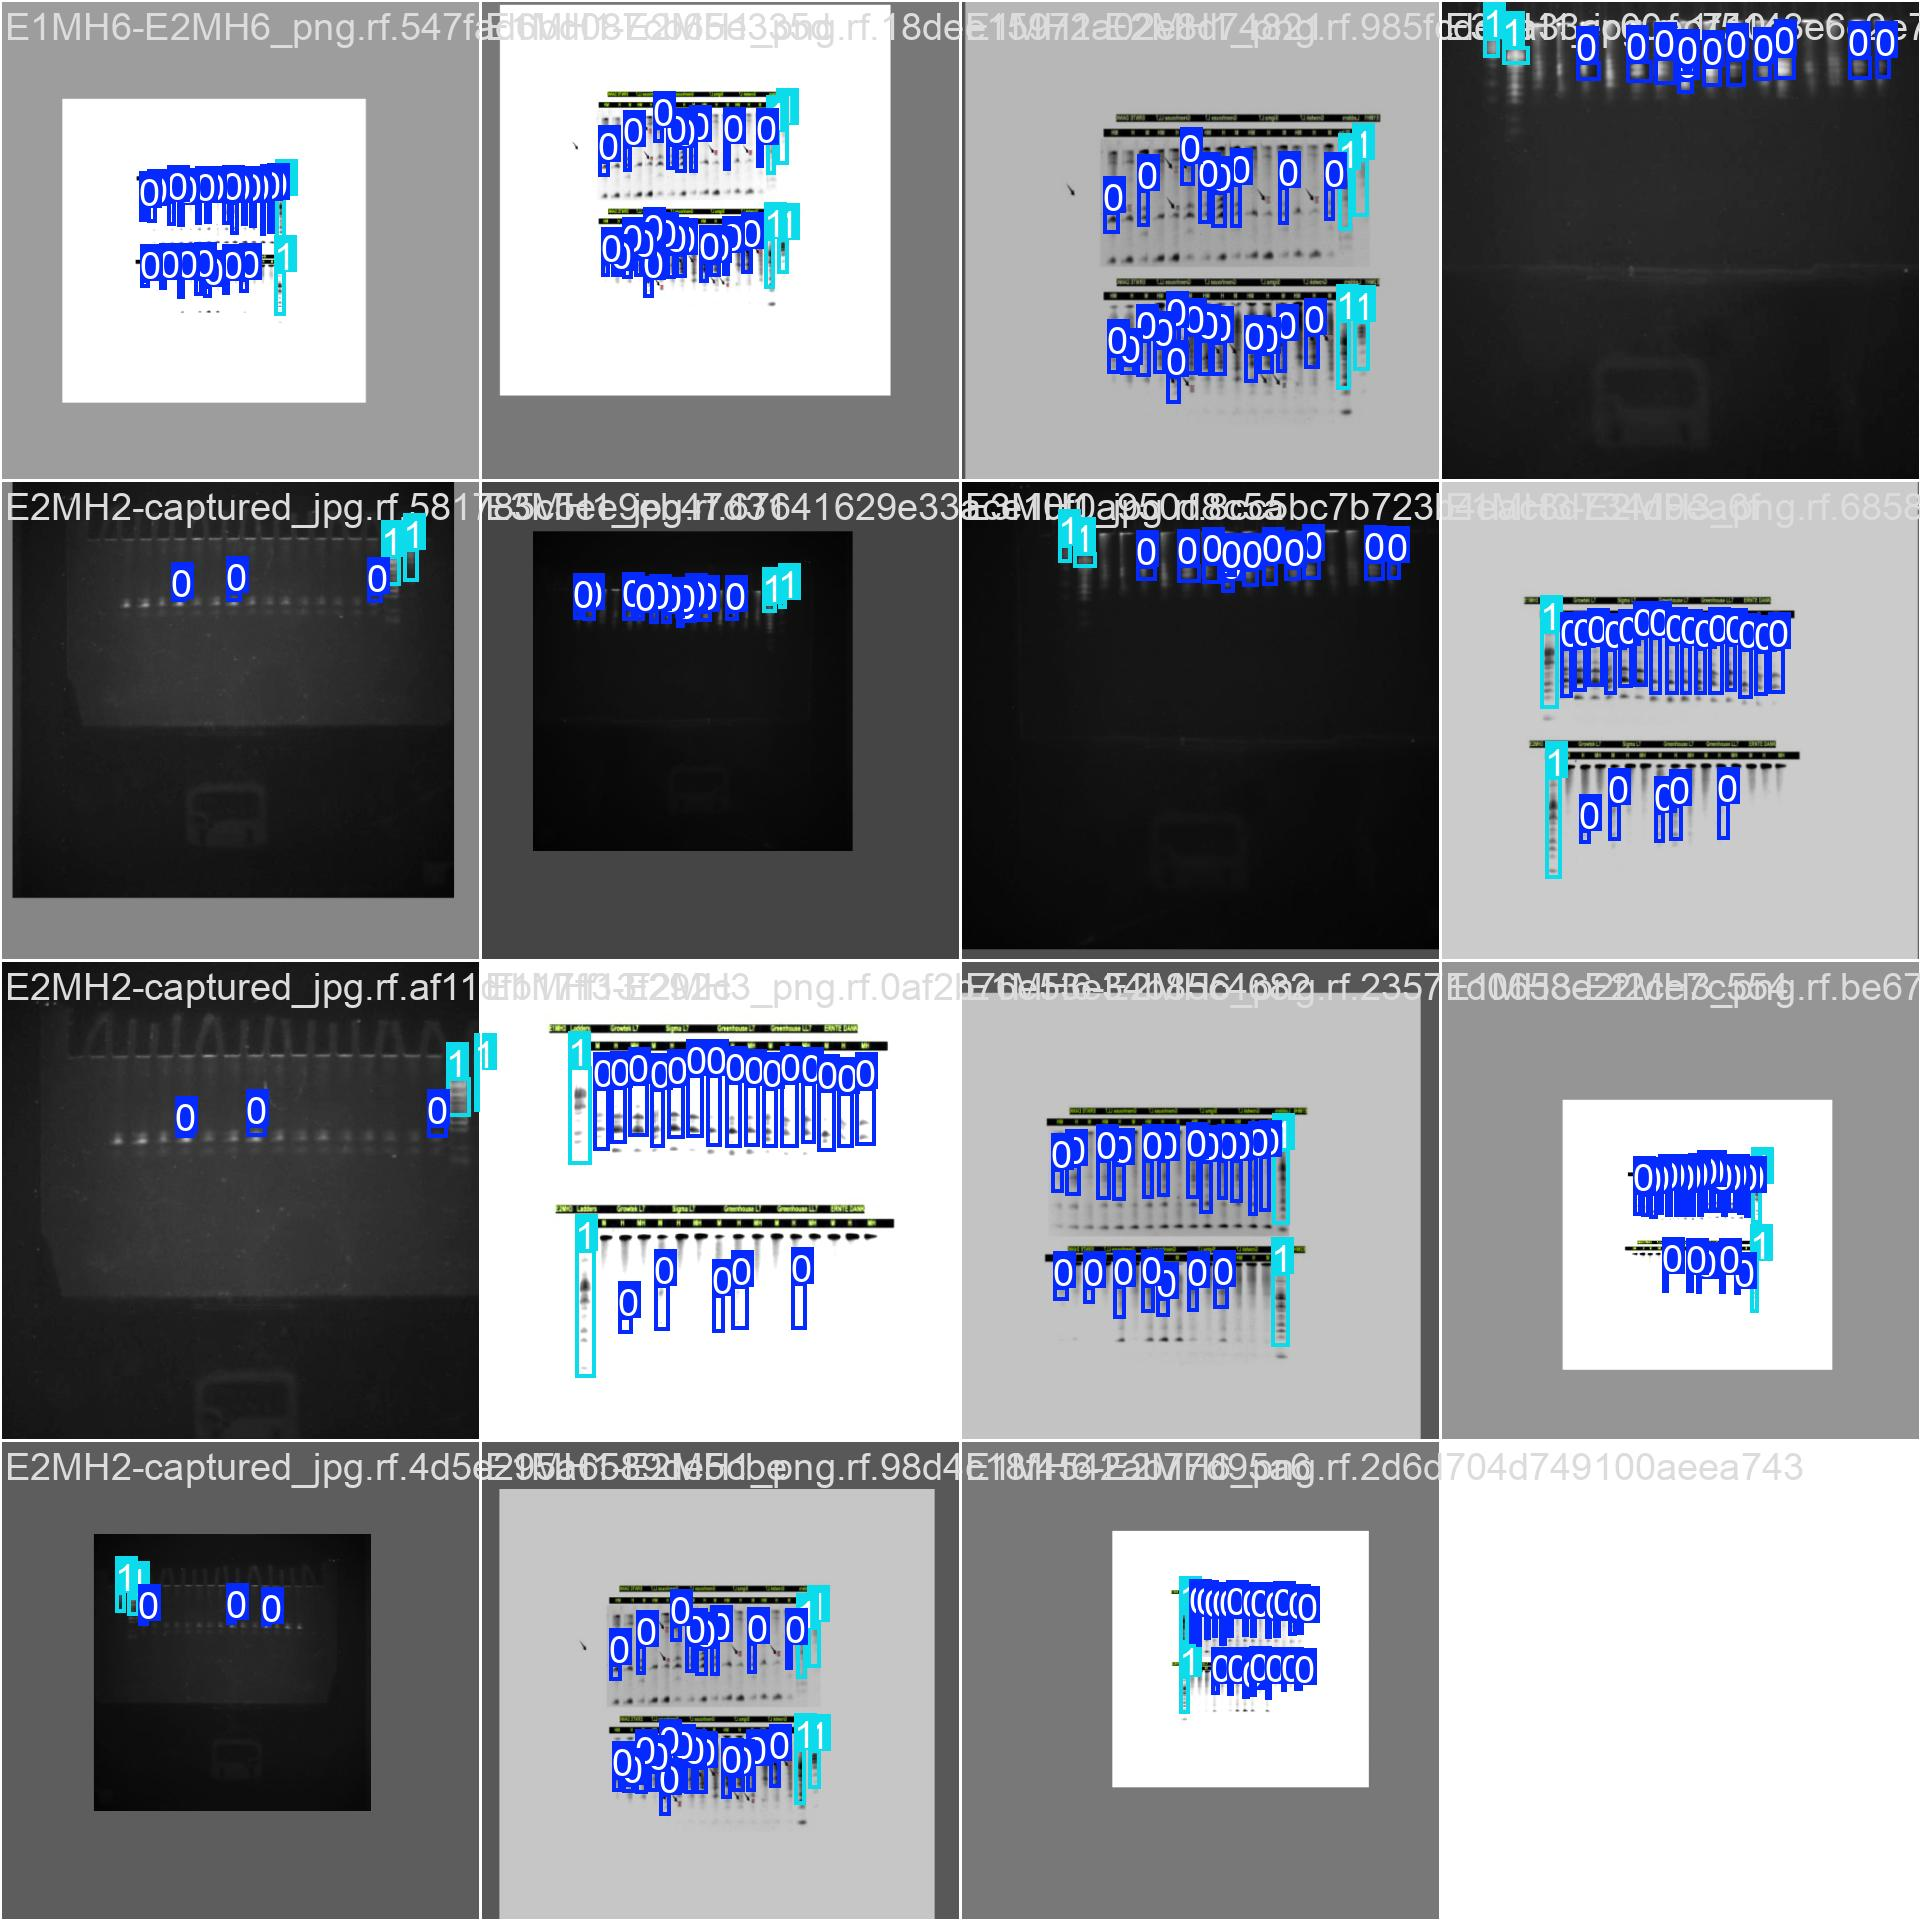

In [27]:
Image ("/content/runs/detect/train/train_batch32.jpg", width= 900)

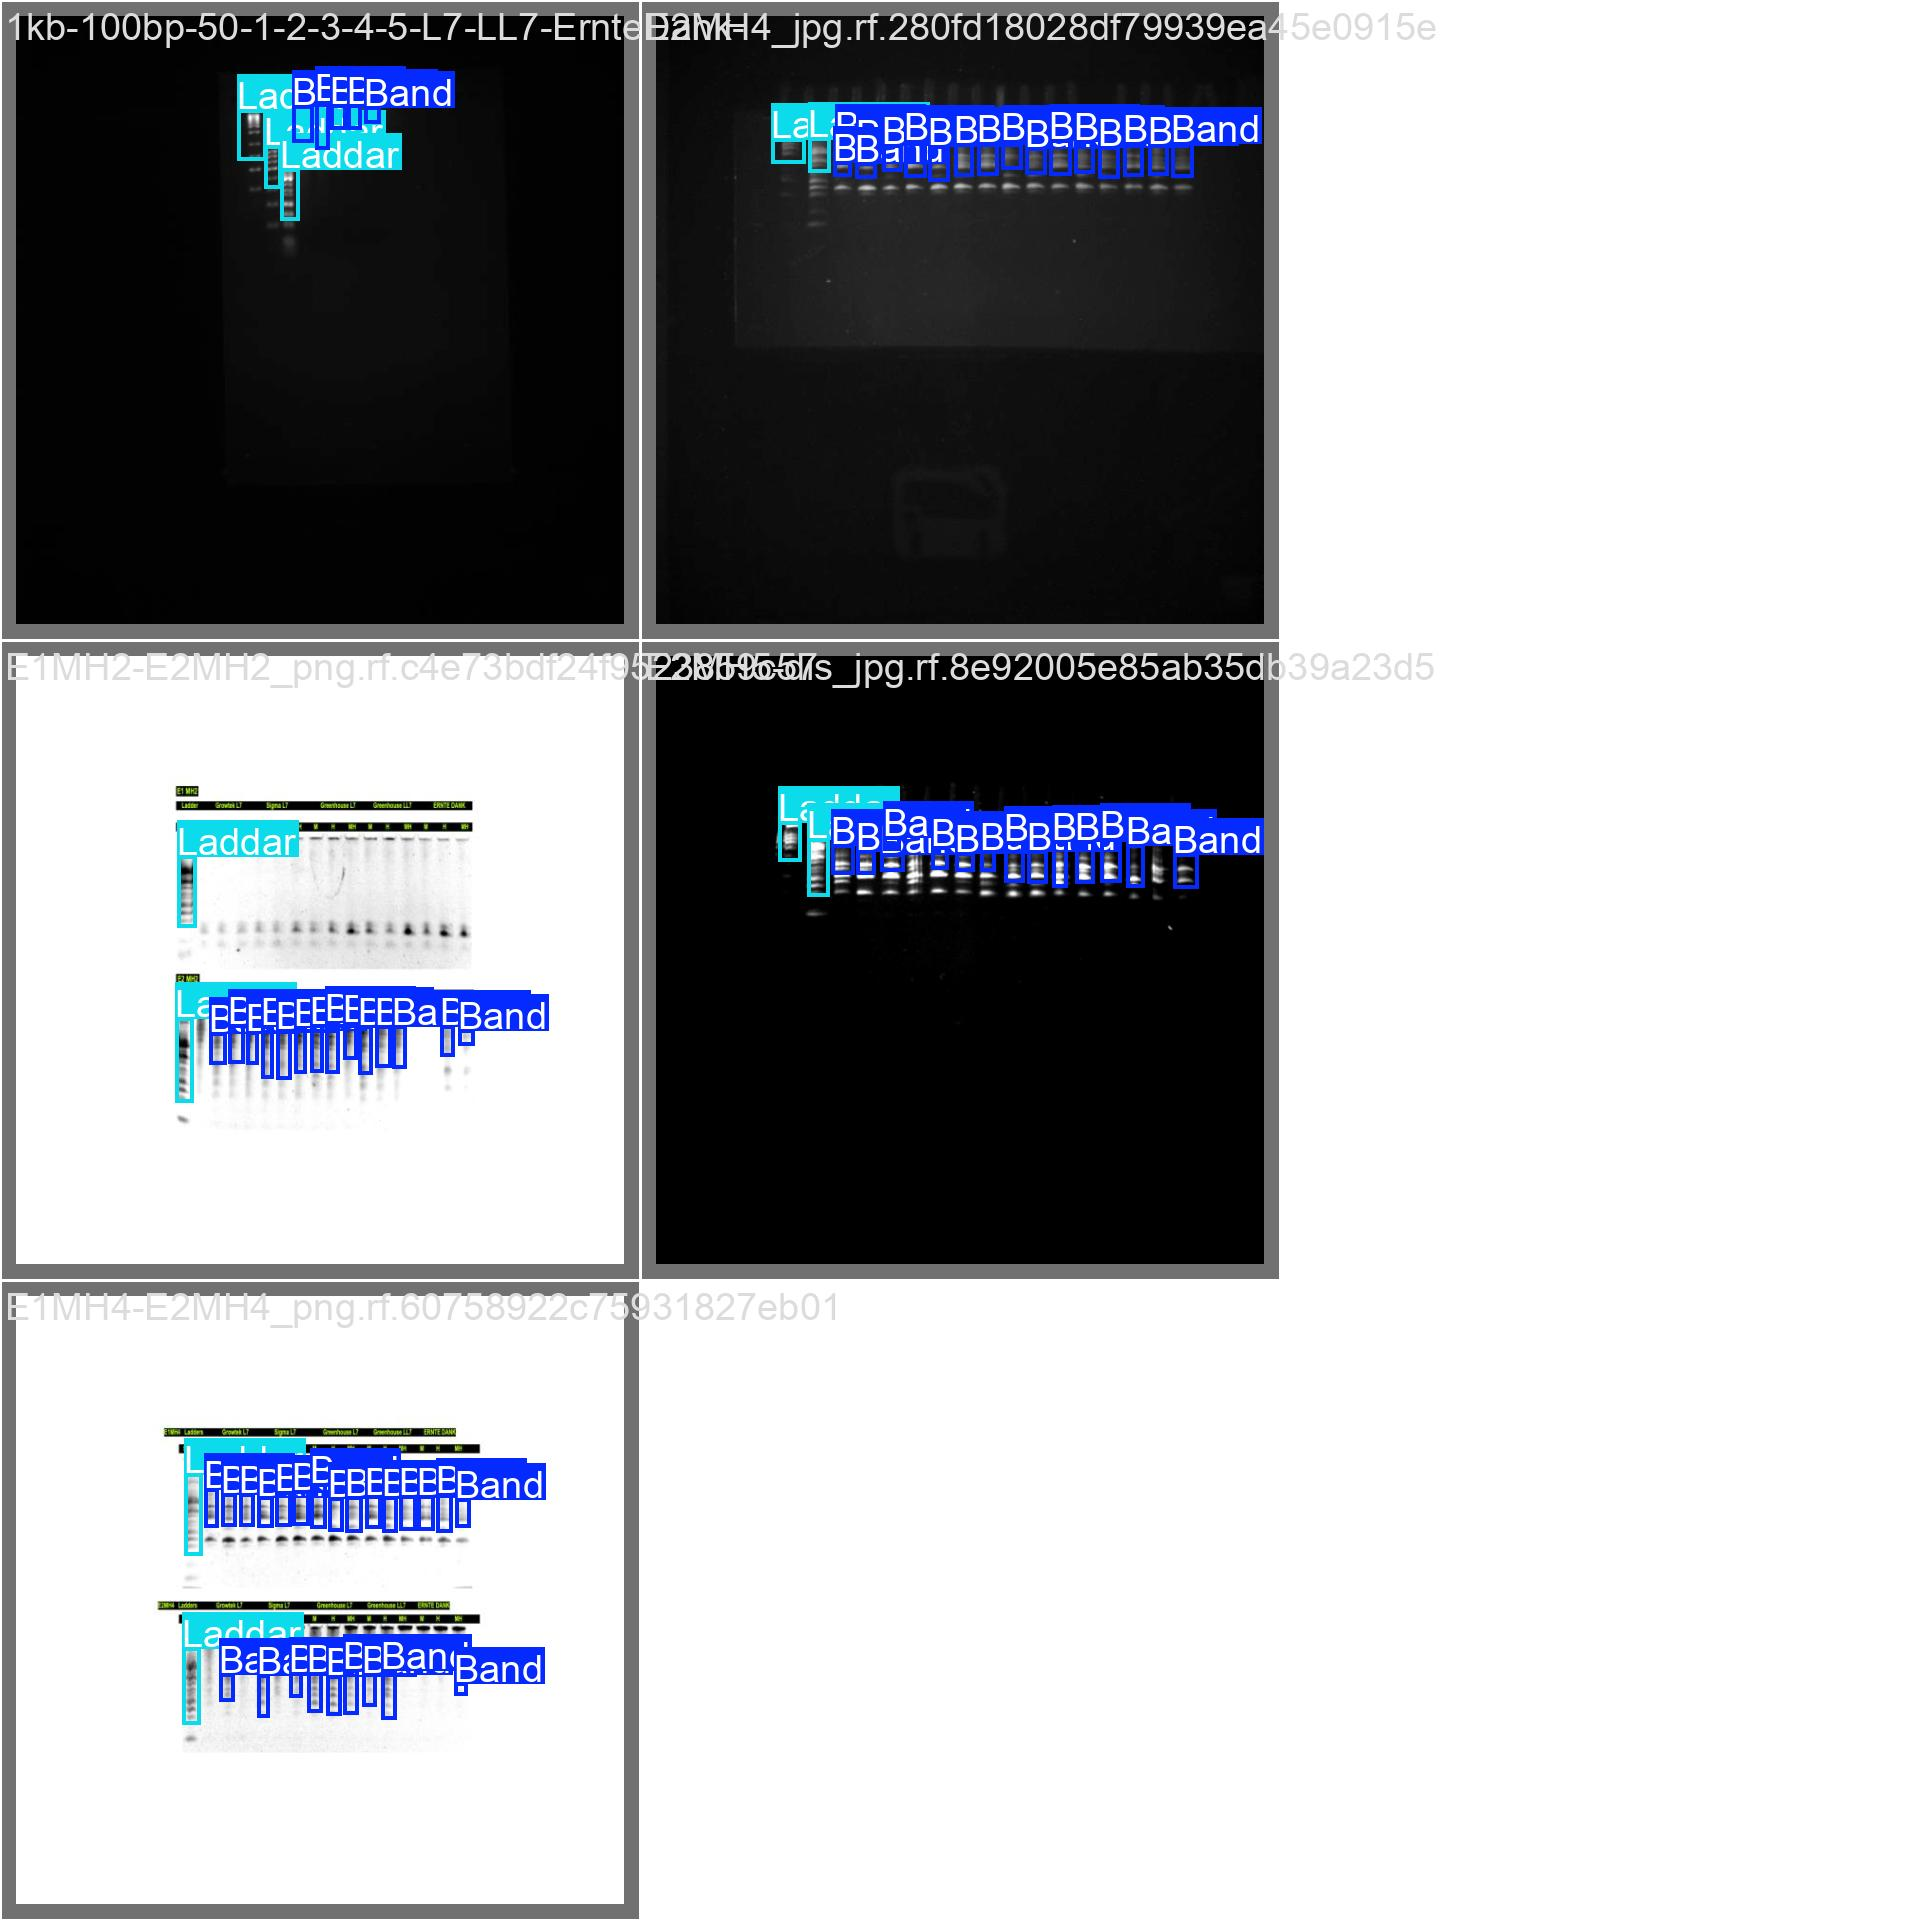

In [28]:
Image ("/content/runs/detect/train/val_batch0_labels.jpg", width= 900)

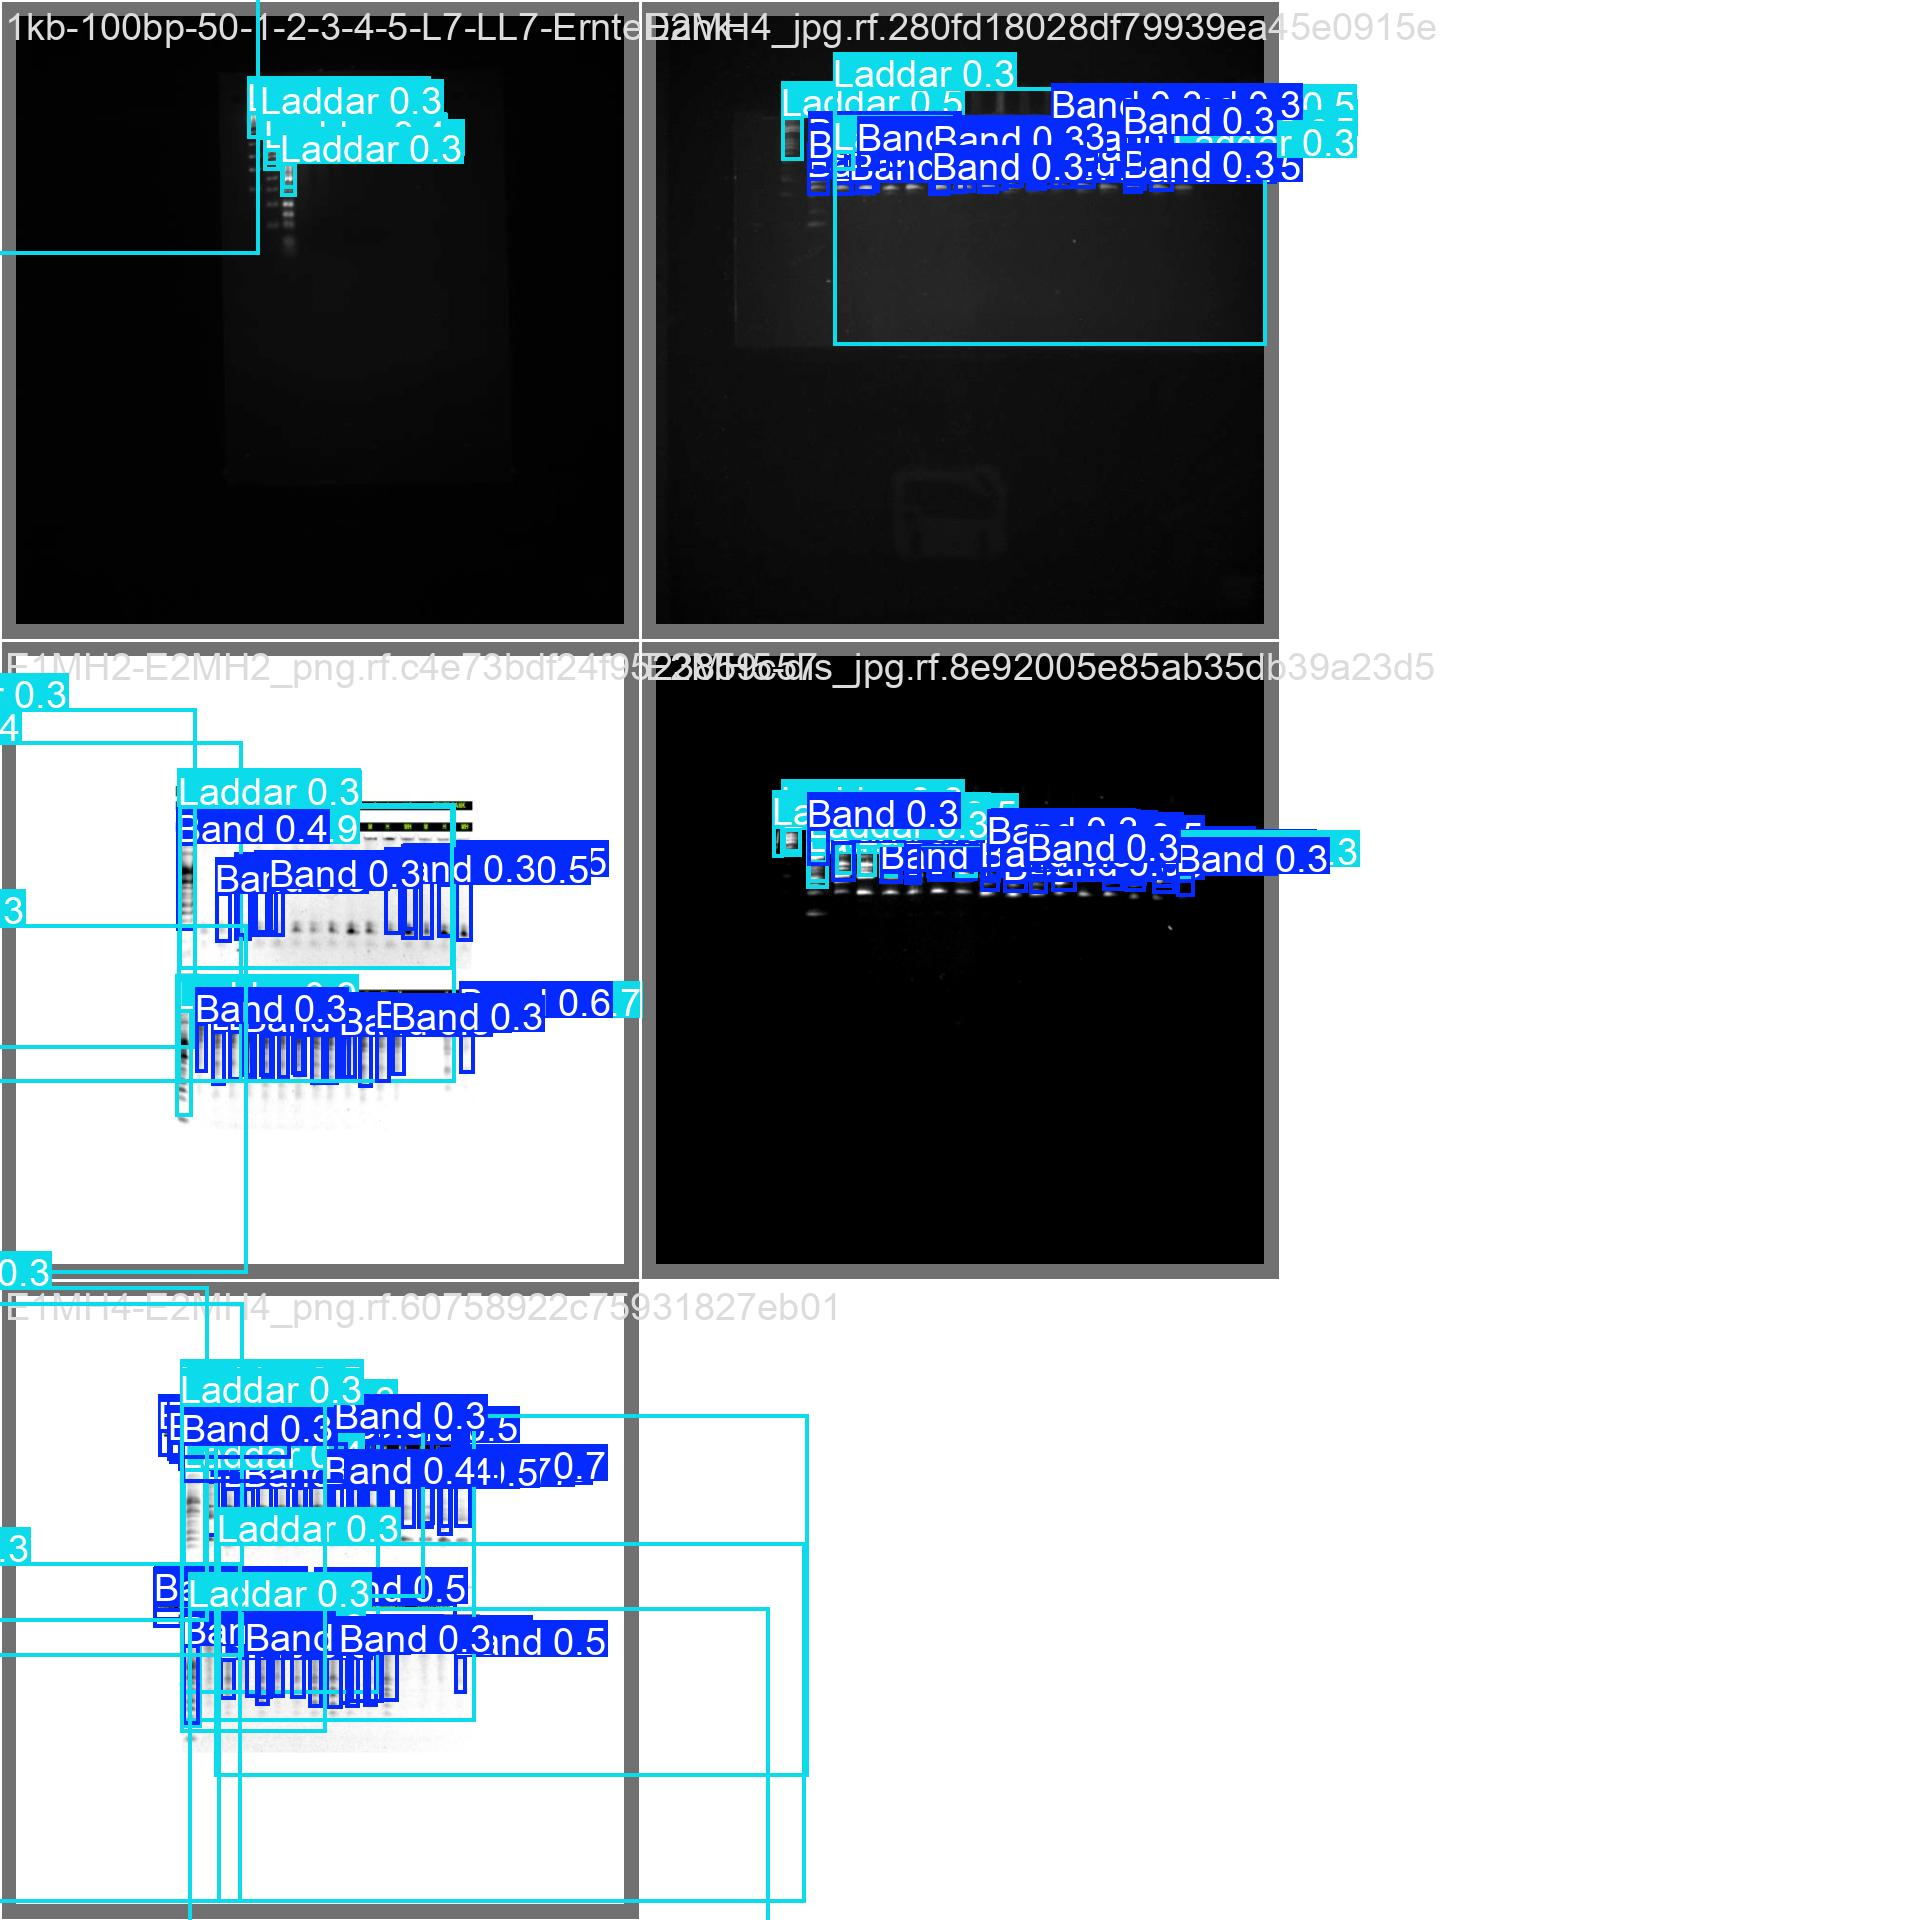

In [29]:
Image ("/content/runs/detect/train/val_batch0_pred.jpg", width= 900)

In [30]:
! yolo task=detect mode=val model="/content/runs/detect/train/weights/best.pt" data={dataset.location}/data.yaml

Ultralytics 8.3.78 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv9s summary (fused): 197 layers, 7,167,862 parameters, 0 gradients, 26.7 GFLOPs
val: Scanning /content/Gel-annotation-on-lingonberry-1/valid/labels.cache... 5 images, 0 backgrounds, 0 corrupt: 100% 5/5 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 1/1 [00:00<00:00,  2.50it/s]
                   all          5         85      0.376       0.43      0.353      0.134
                  Band          5         74      0.395      0.405      0.312     0.0798
                Laddar          5         11      0.357      0.455      0.393      0.188
Speed: 0.3ms preprocess, 19.5ms inference, 0.0ms loss, 33.5ms postprocess per image
Results saved to runs/detect/val
💡 Learn more at https://docs.ultralytics.com/modes/val


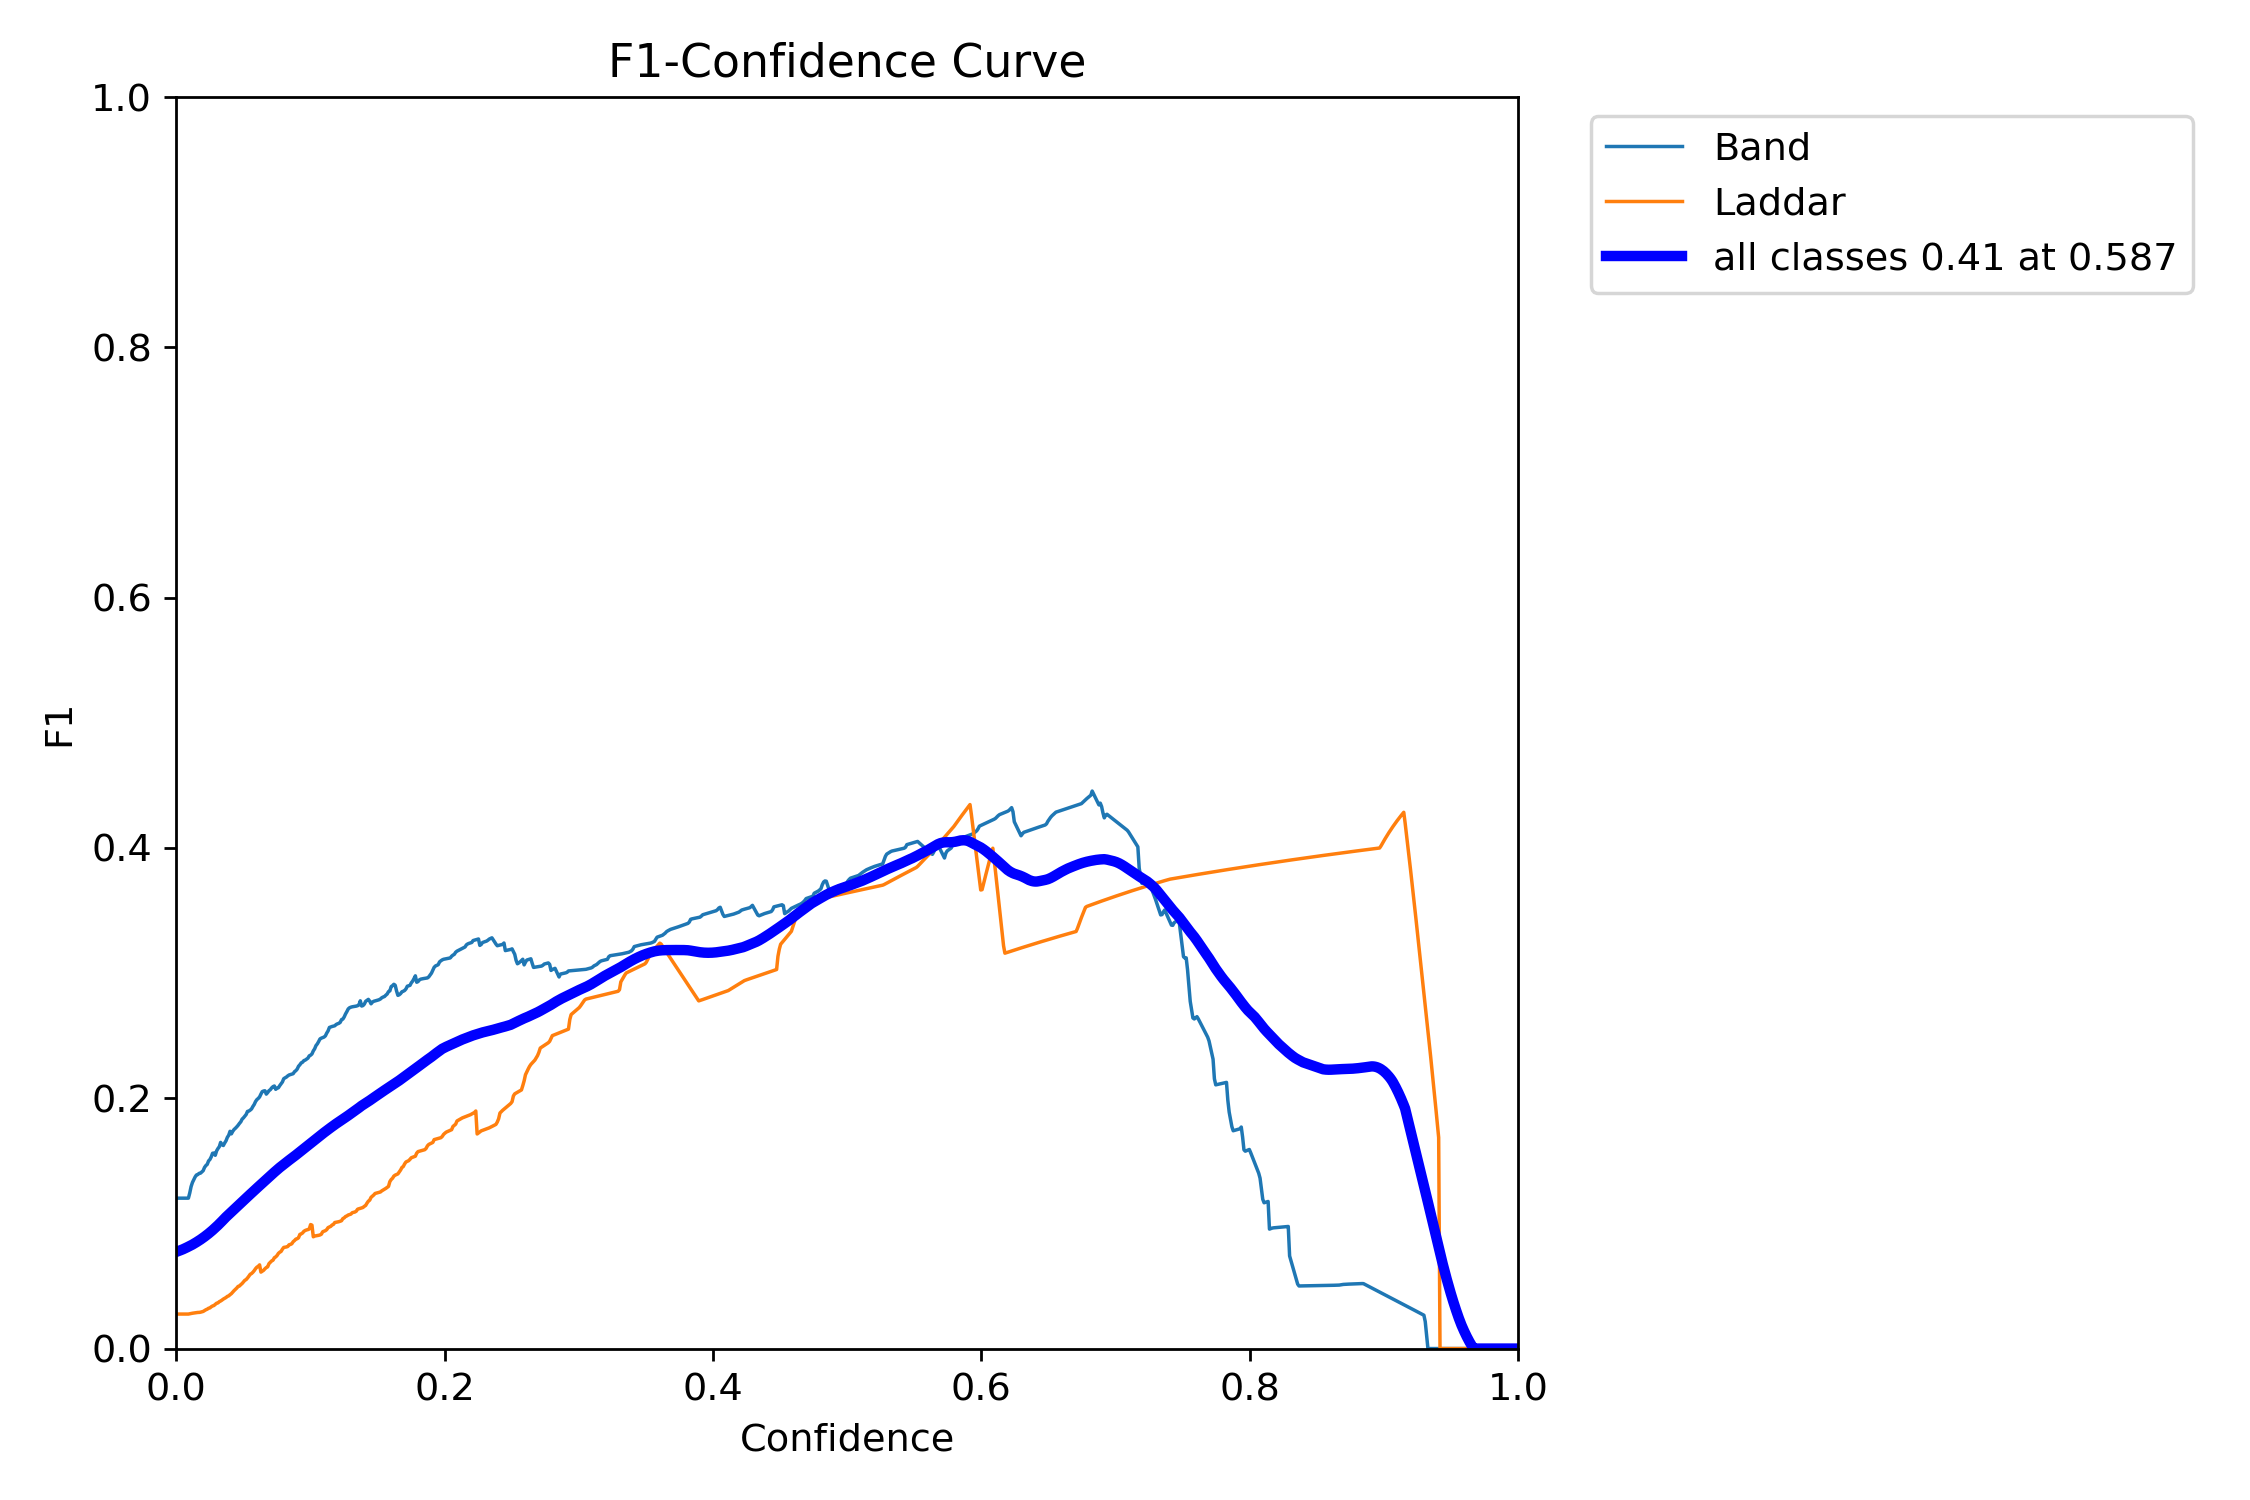

In [31]:
Image ("/content/runs/detect/val/F1_curve.png", width= 600)

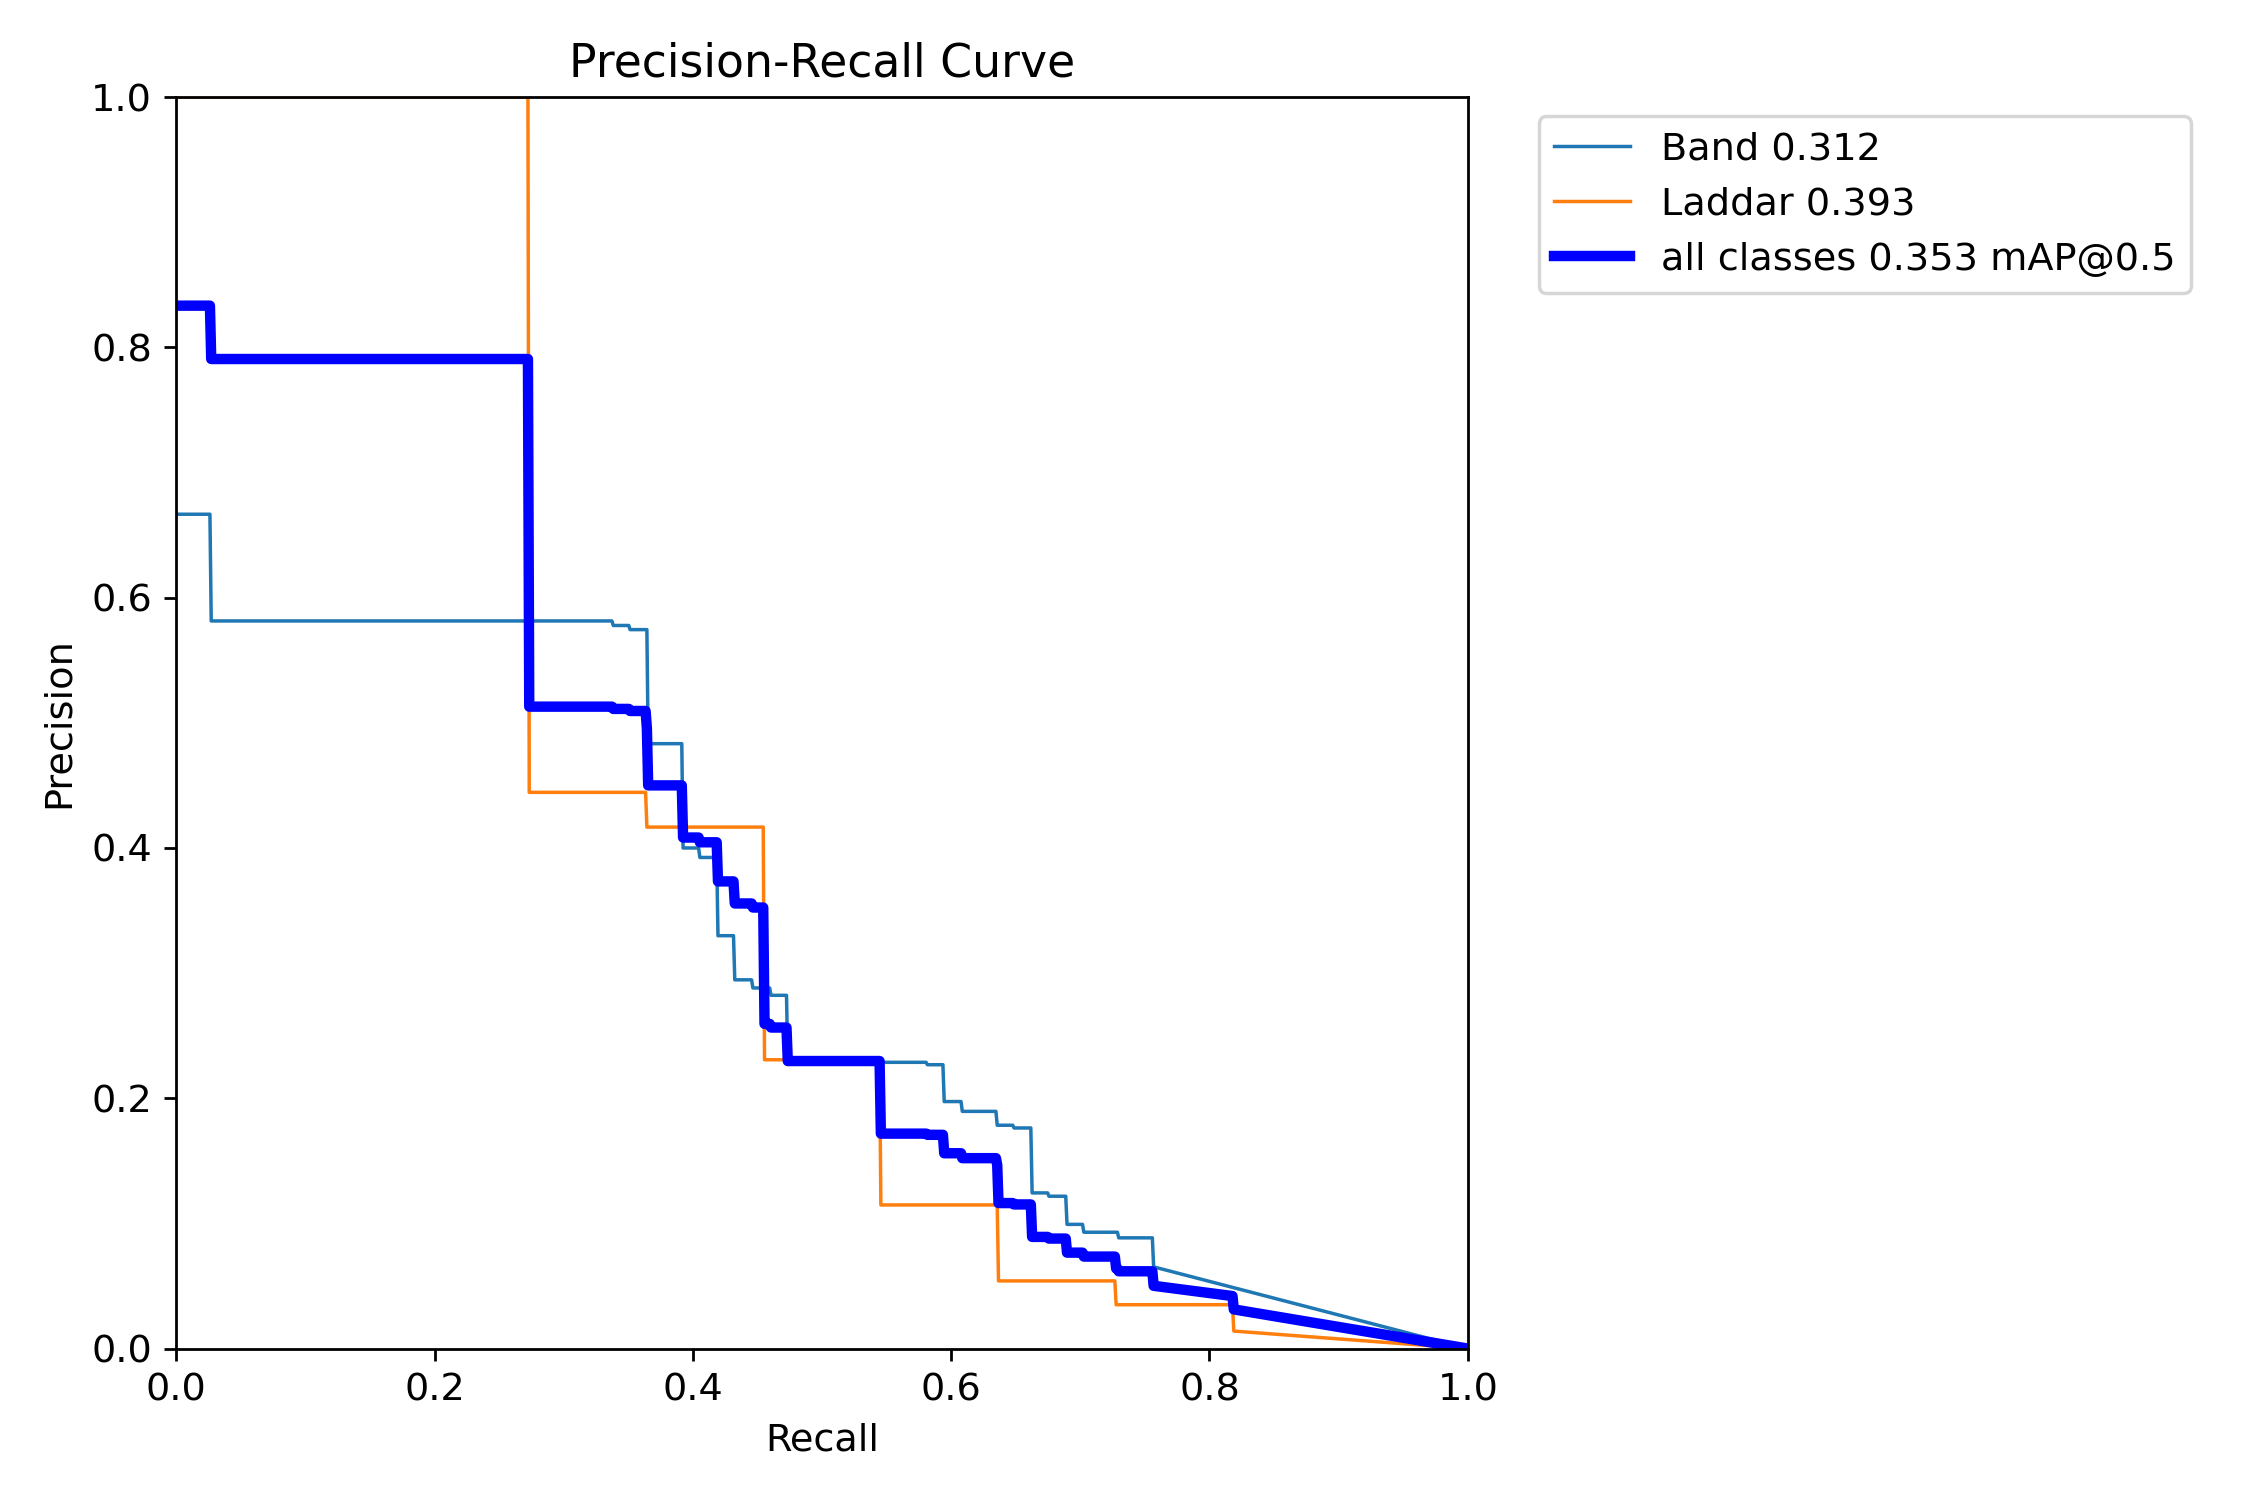

In [32]:
Image ("/content/runs/detect/val/PR_curve.png", width= 600)

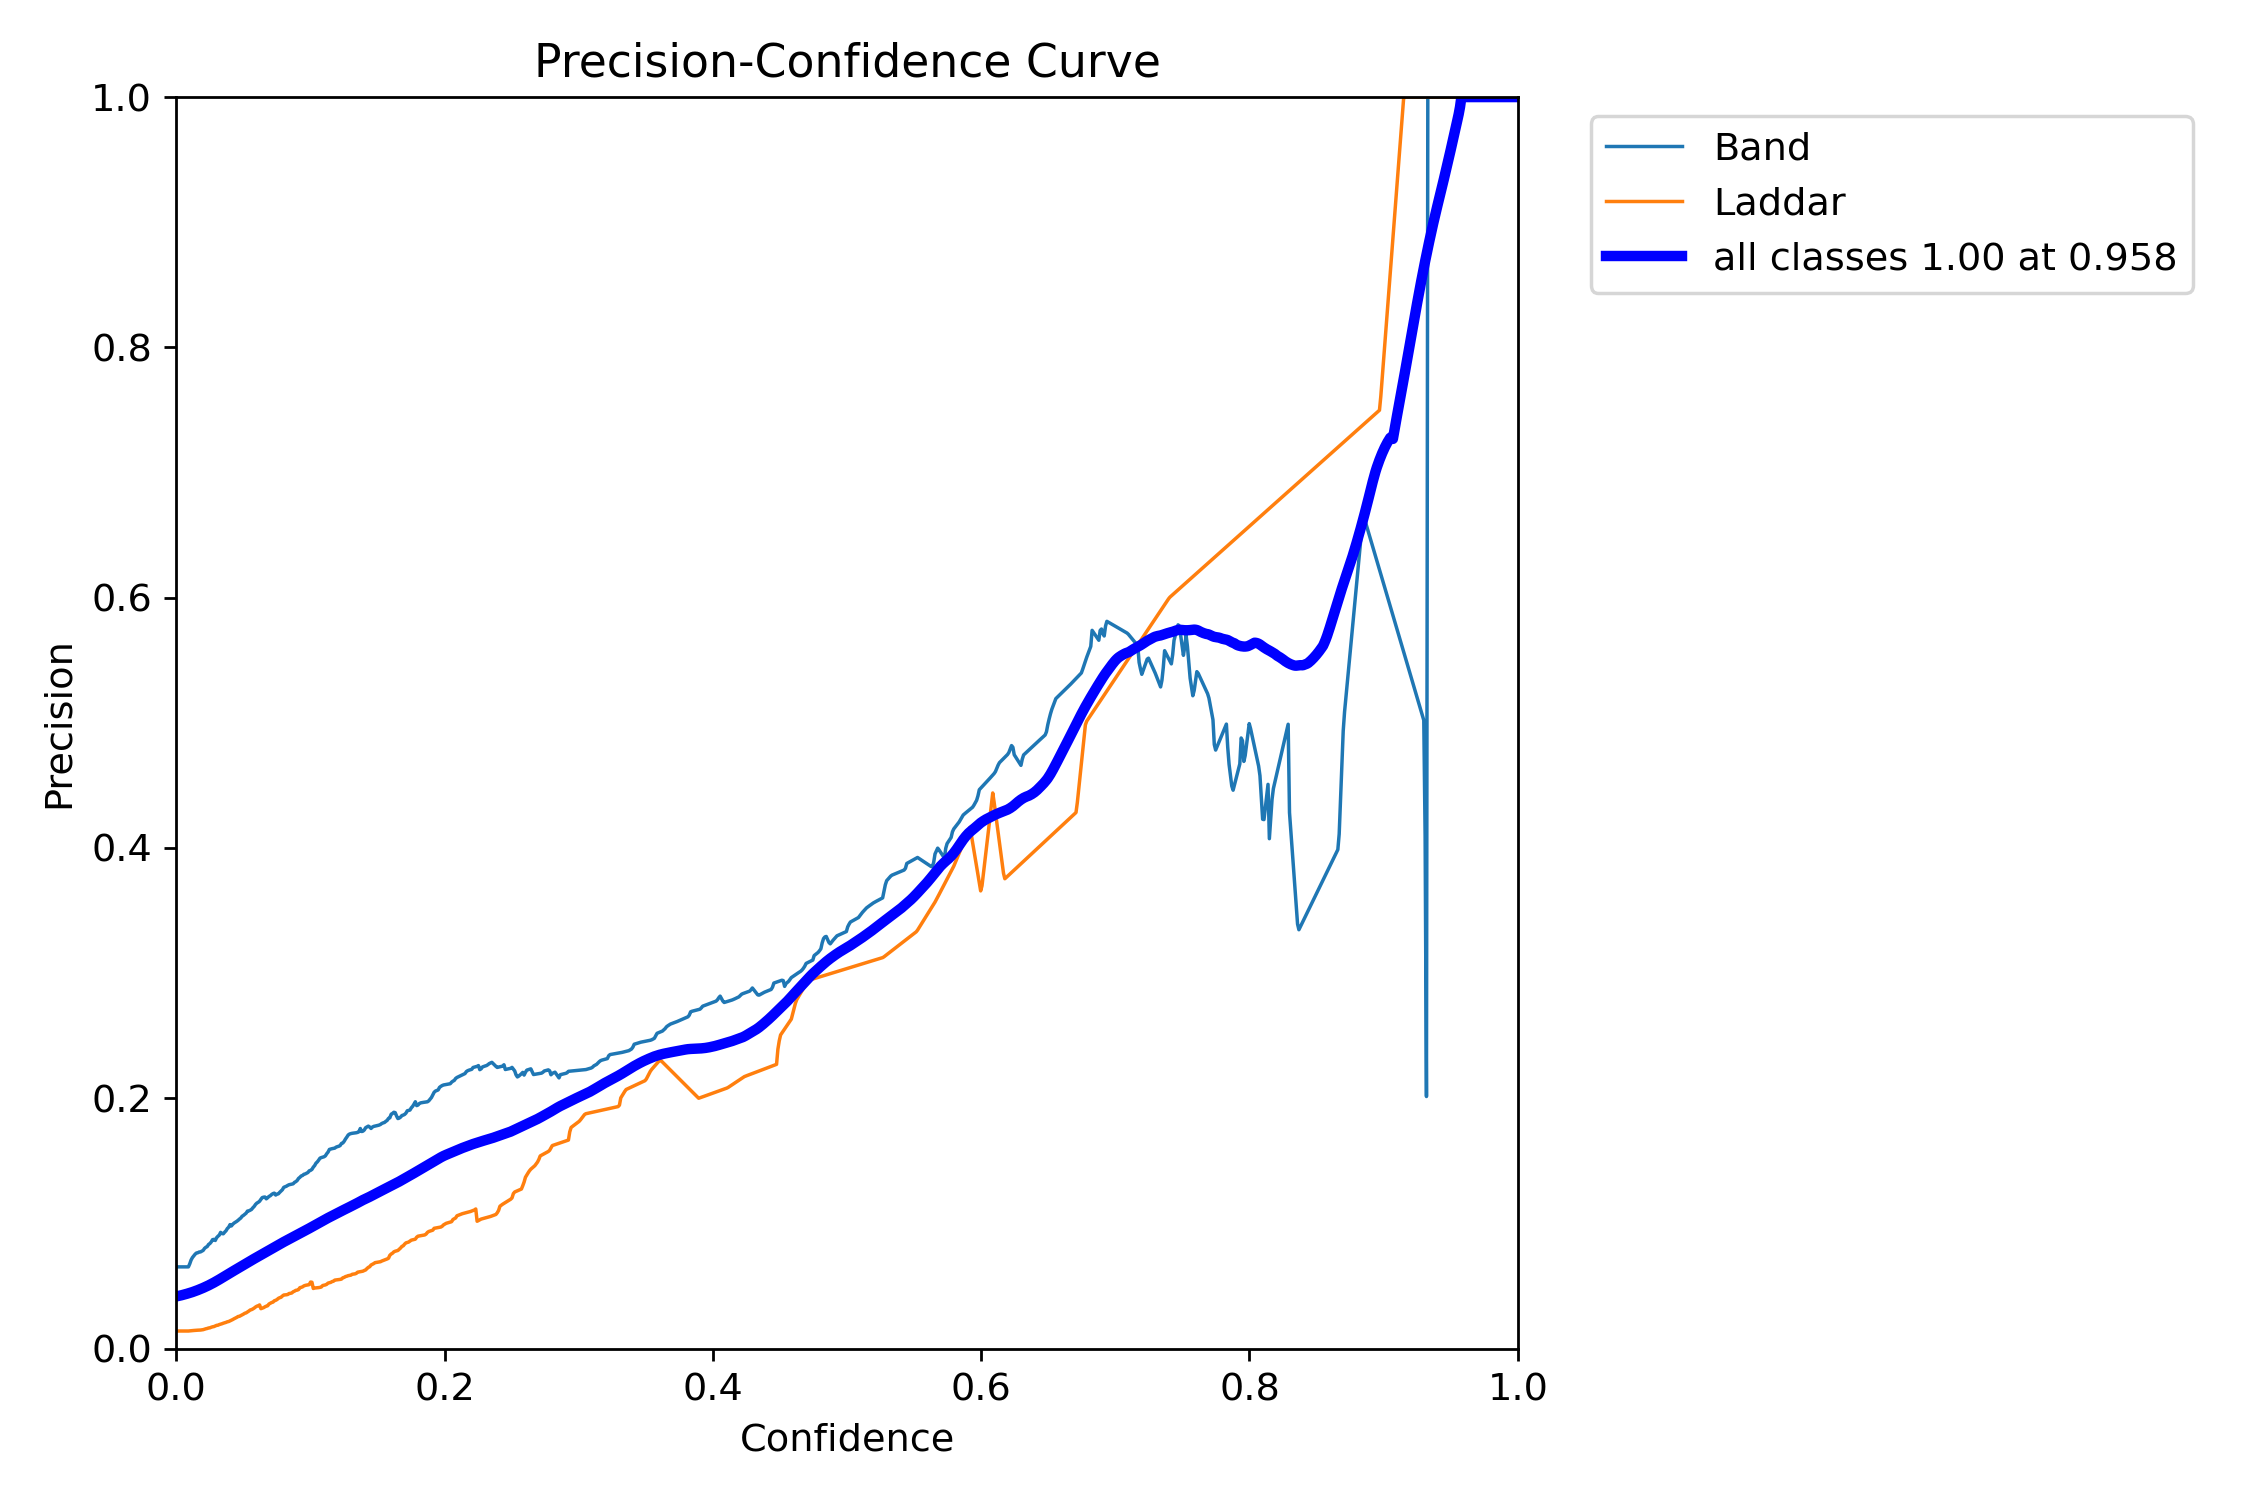

In [33]:
Image ("/content/runs/detect/val/P_curve.png", width= 600)

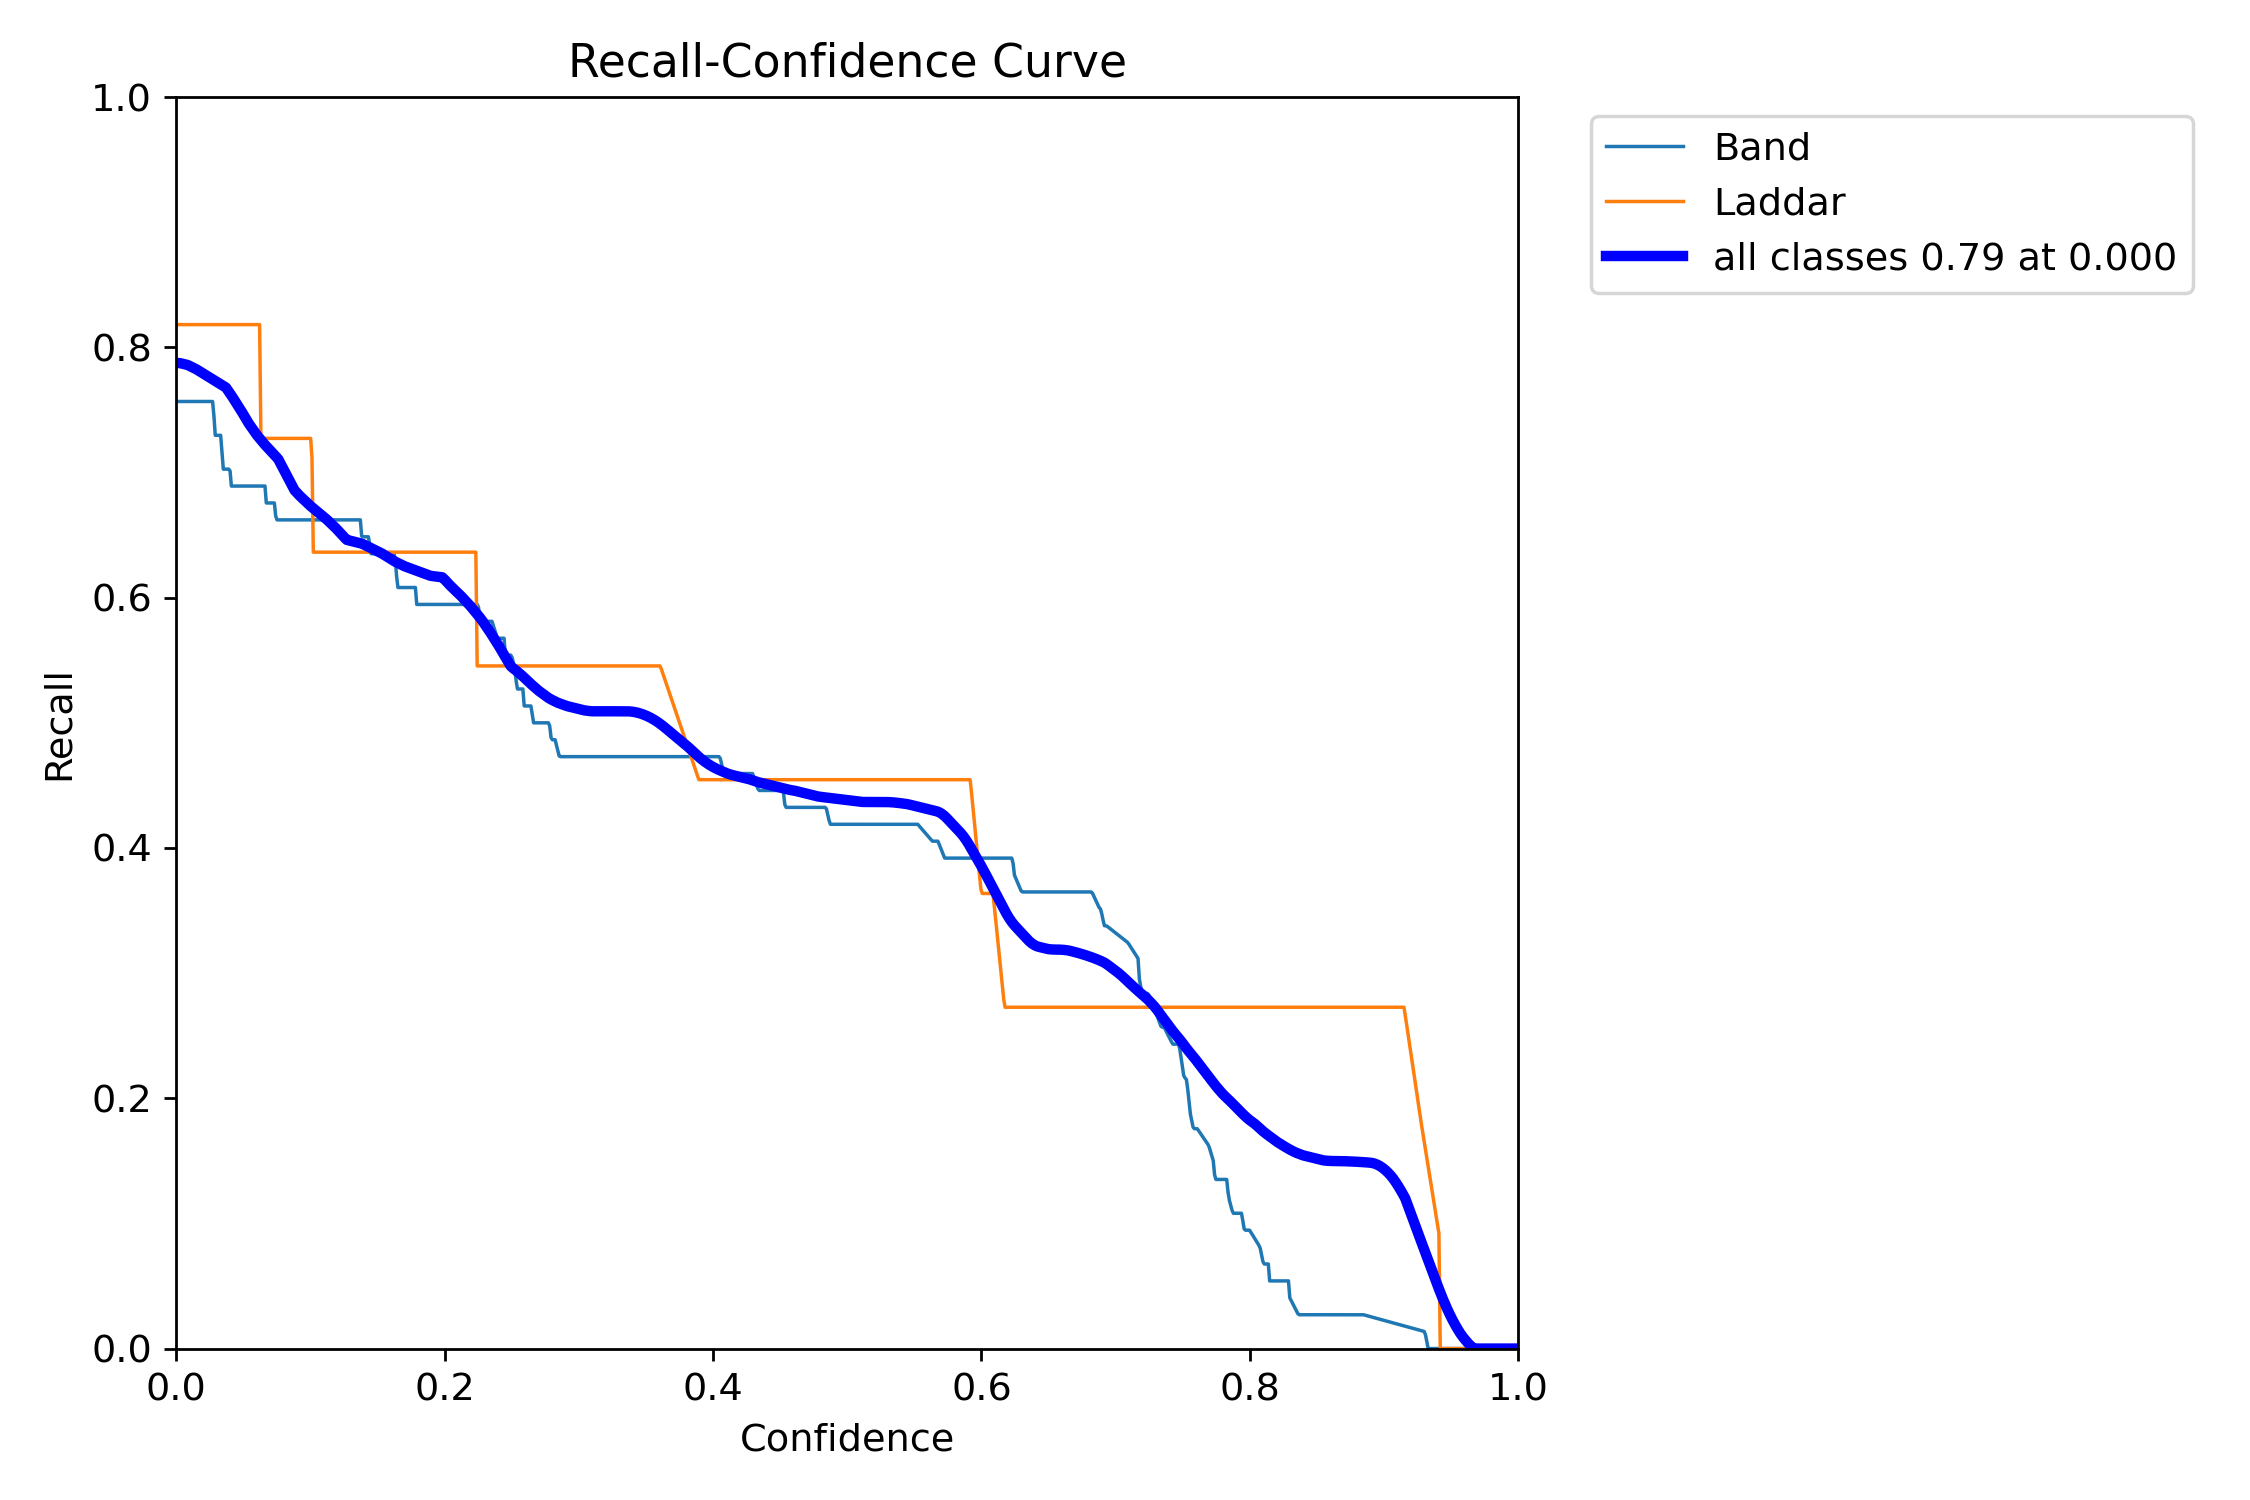

In [34]:
Image ("/content/runs/detect/val/R_curve.png", width= 600)

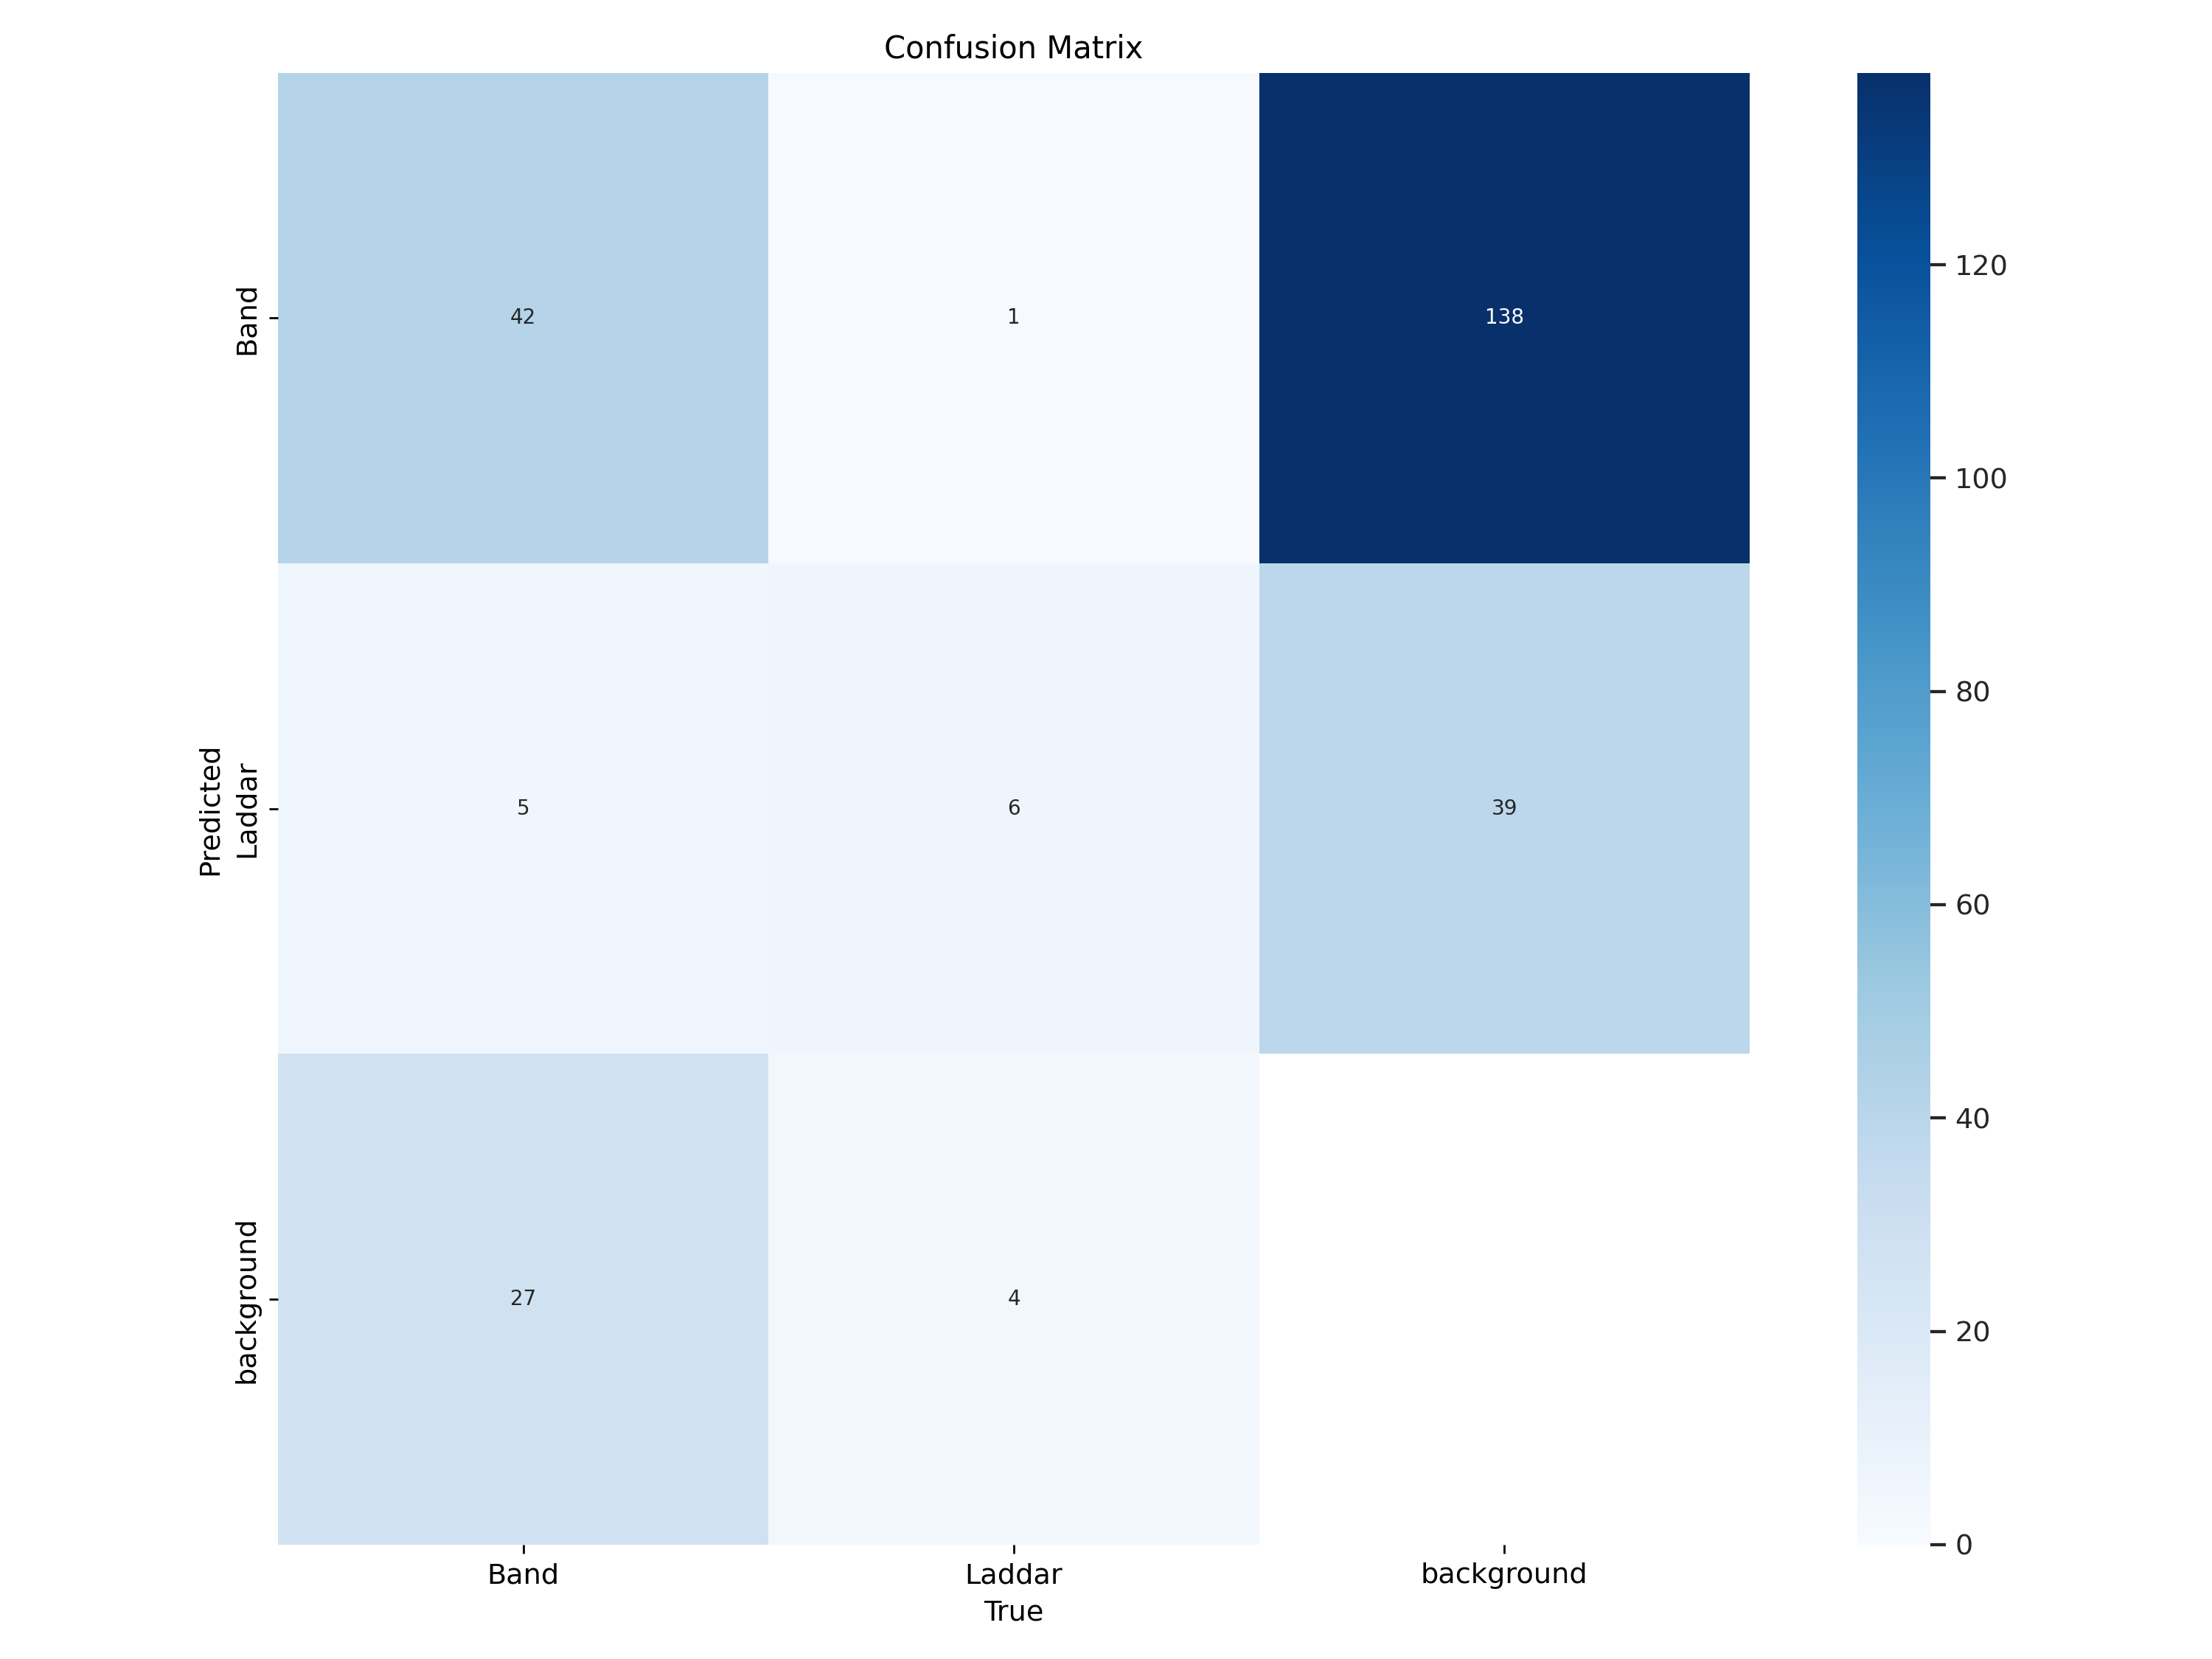

In [35]:
Image ("/content/runs/detect/val/confusion_matrix.png", width= 900)

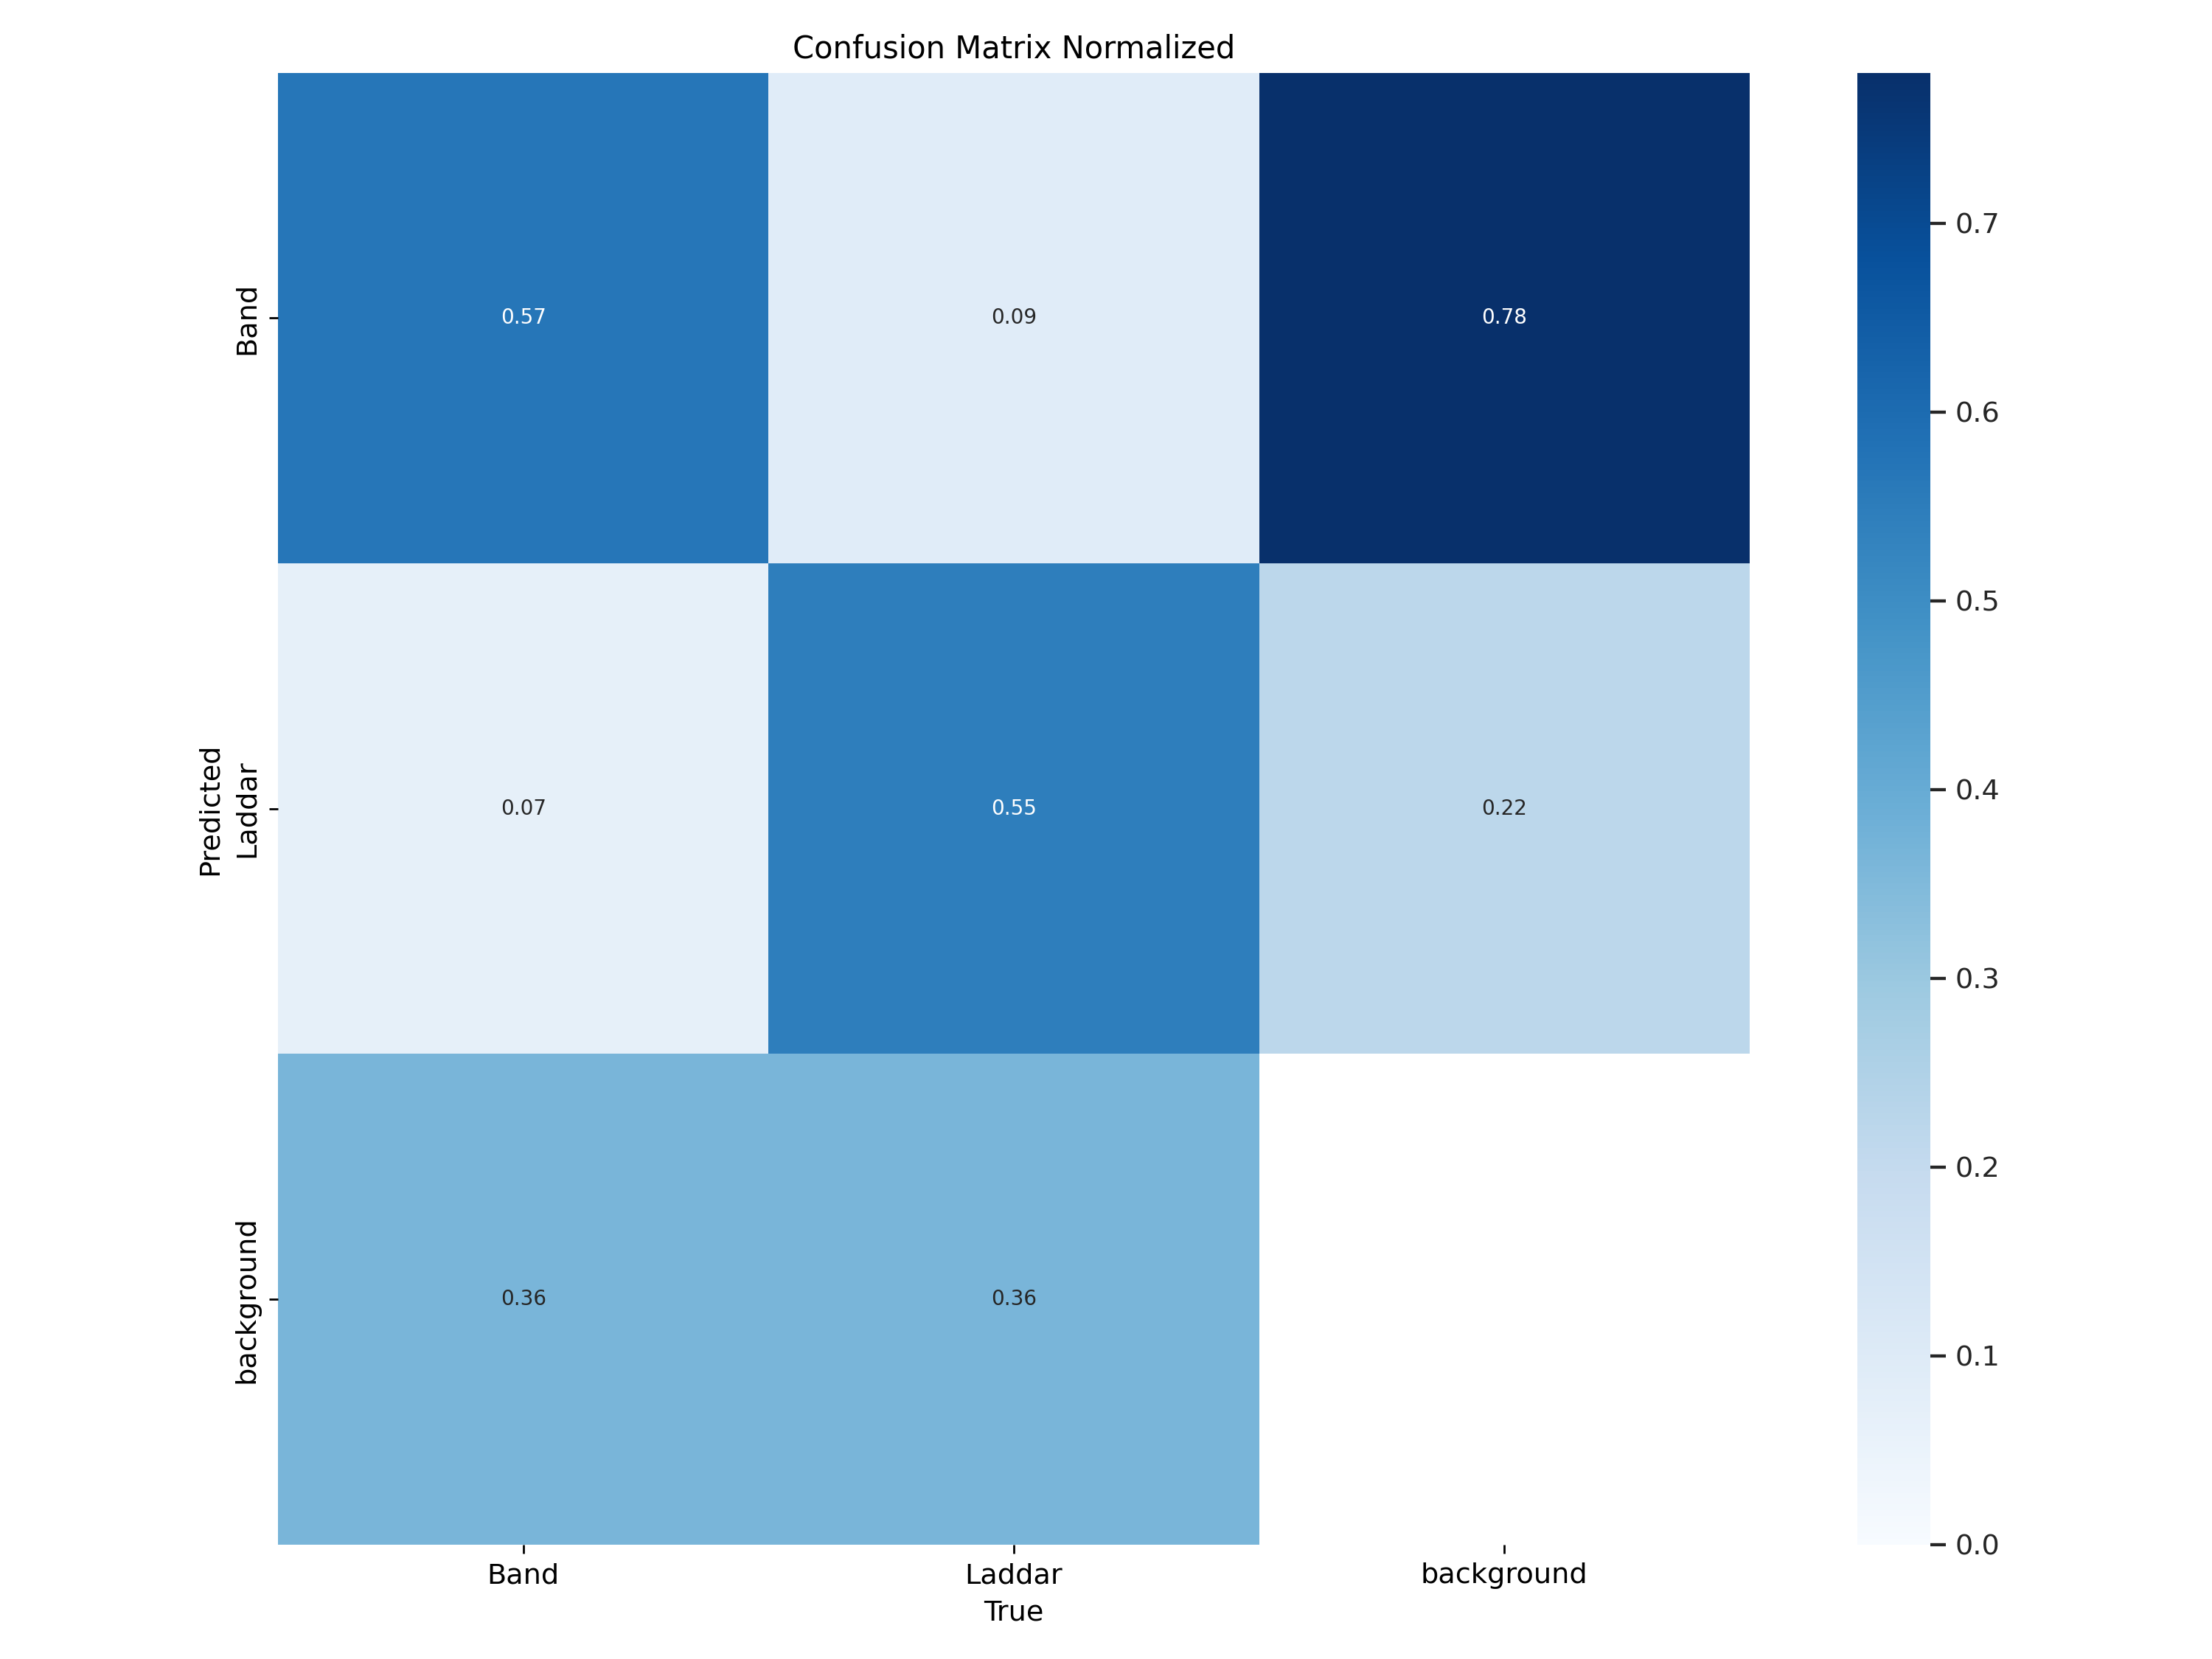

In [36]:
Image ("/content/runs/detect/val/confusion_matrix_normalized.png", width= 900)

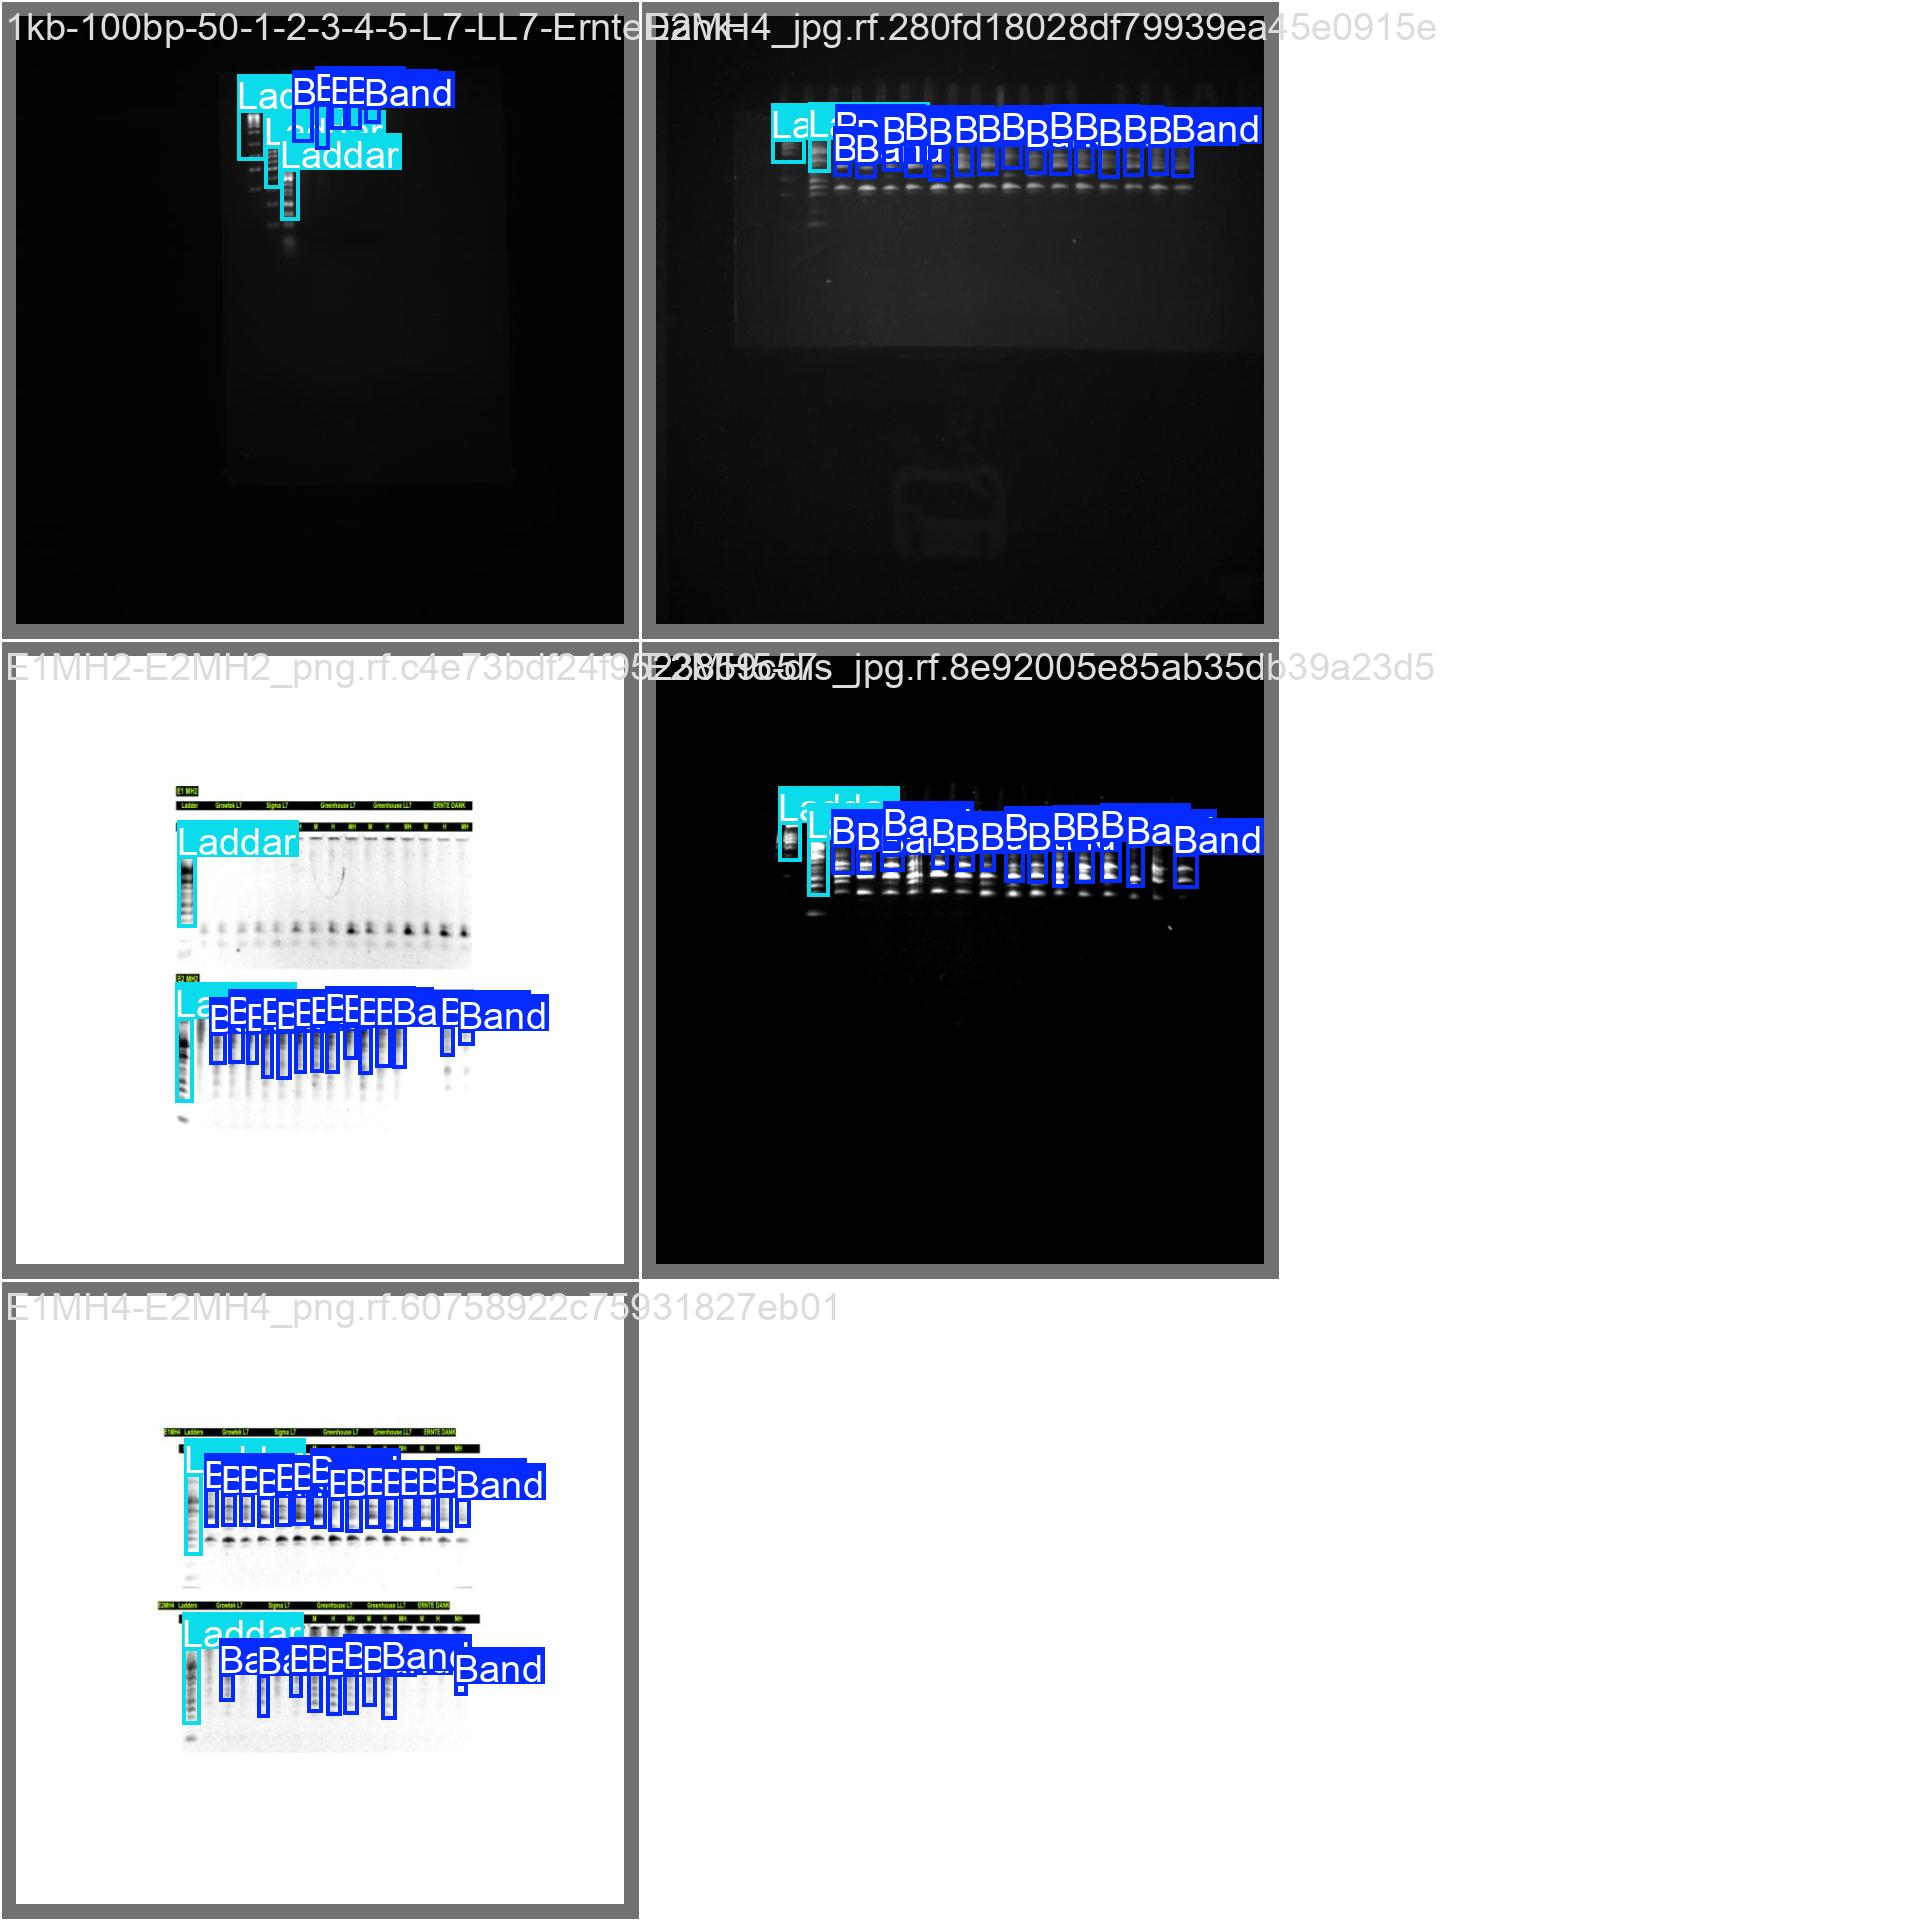

In [37]:
Image ("/content/runs/detect/val/val_batch0_labels.jpg", width= 900)

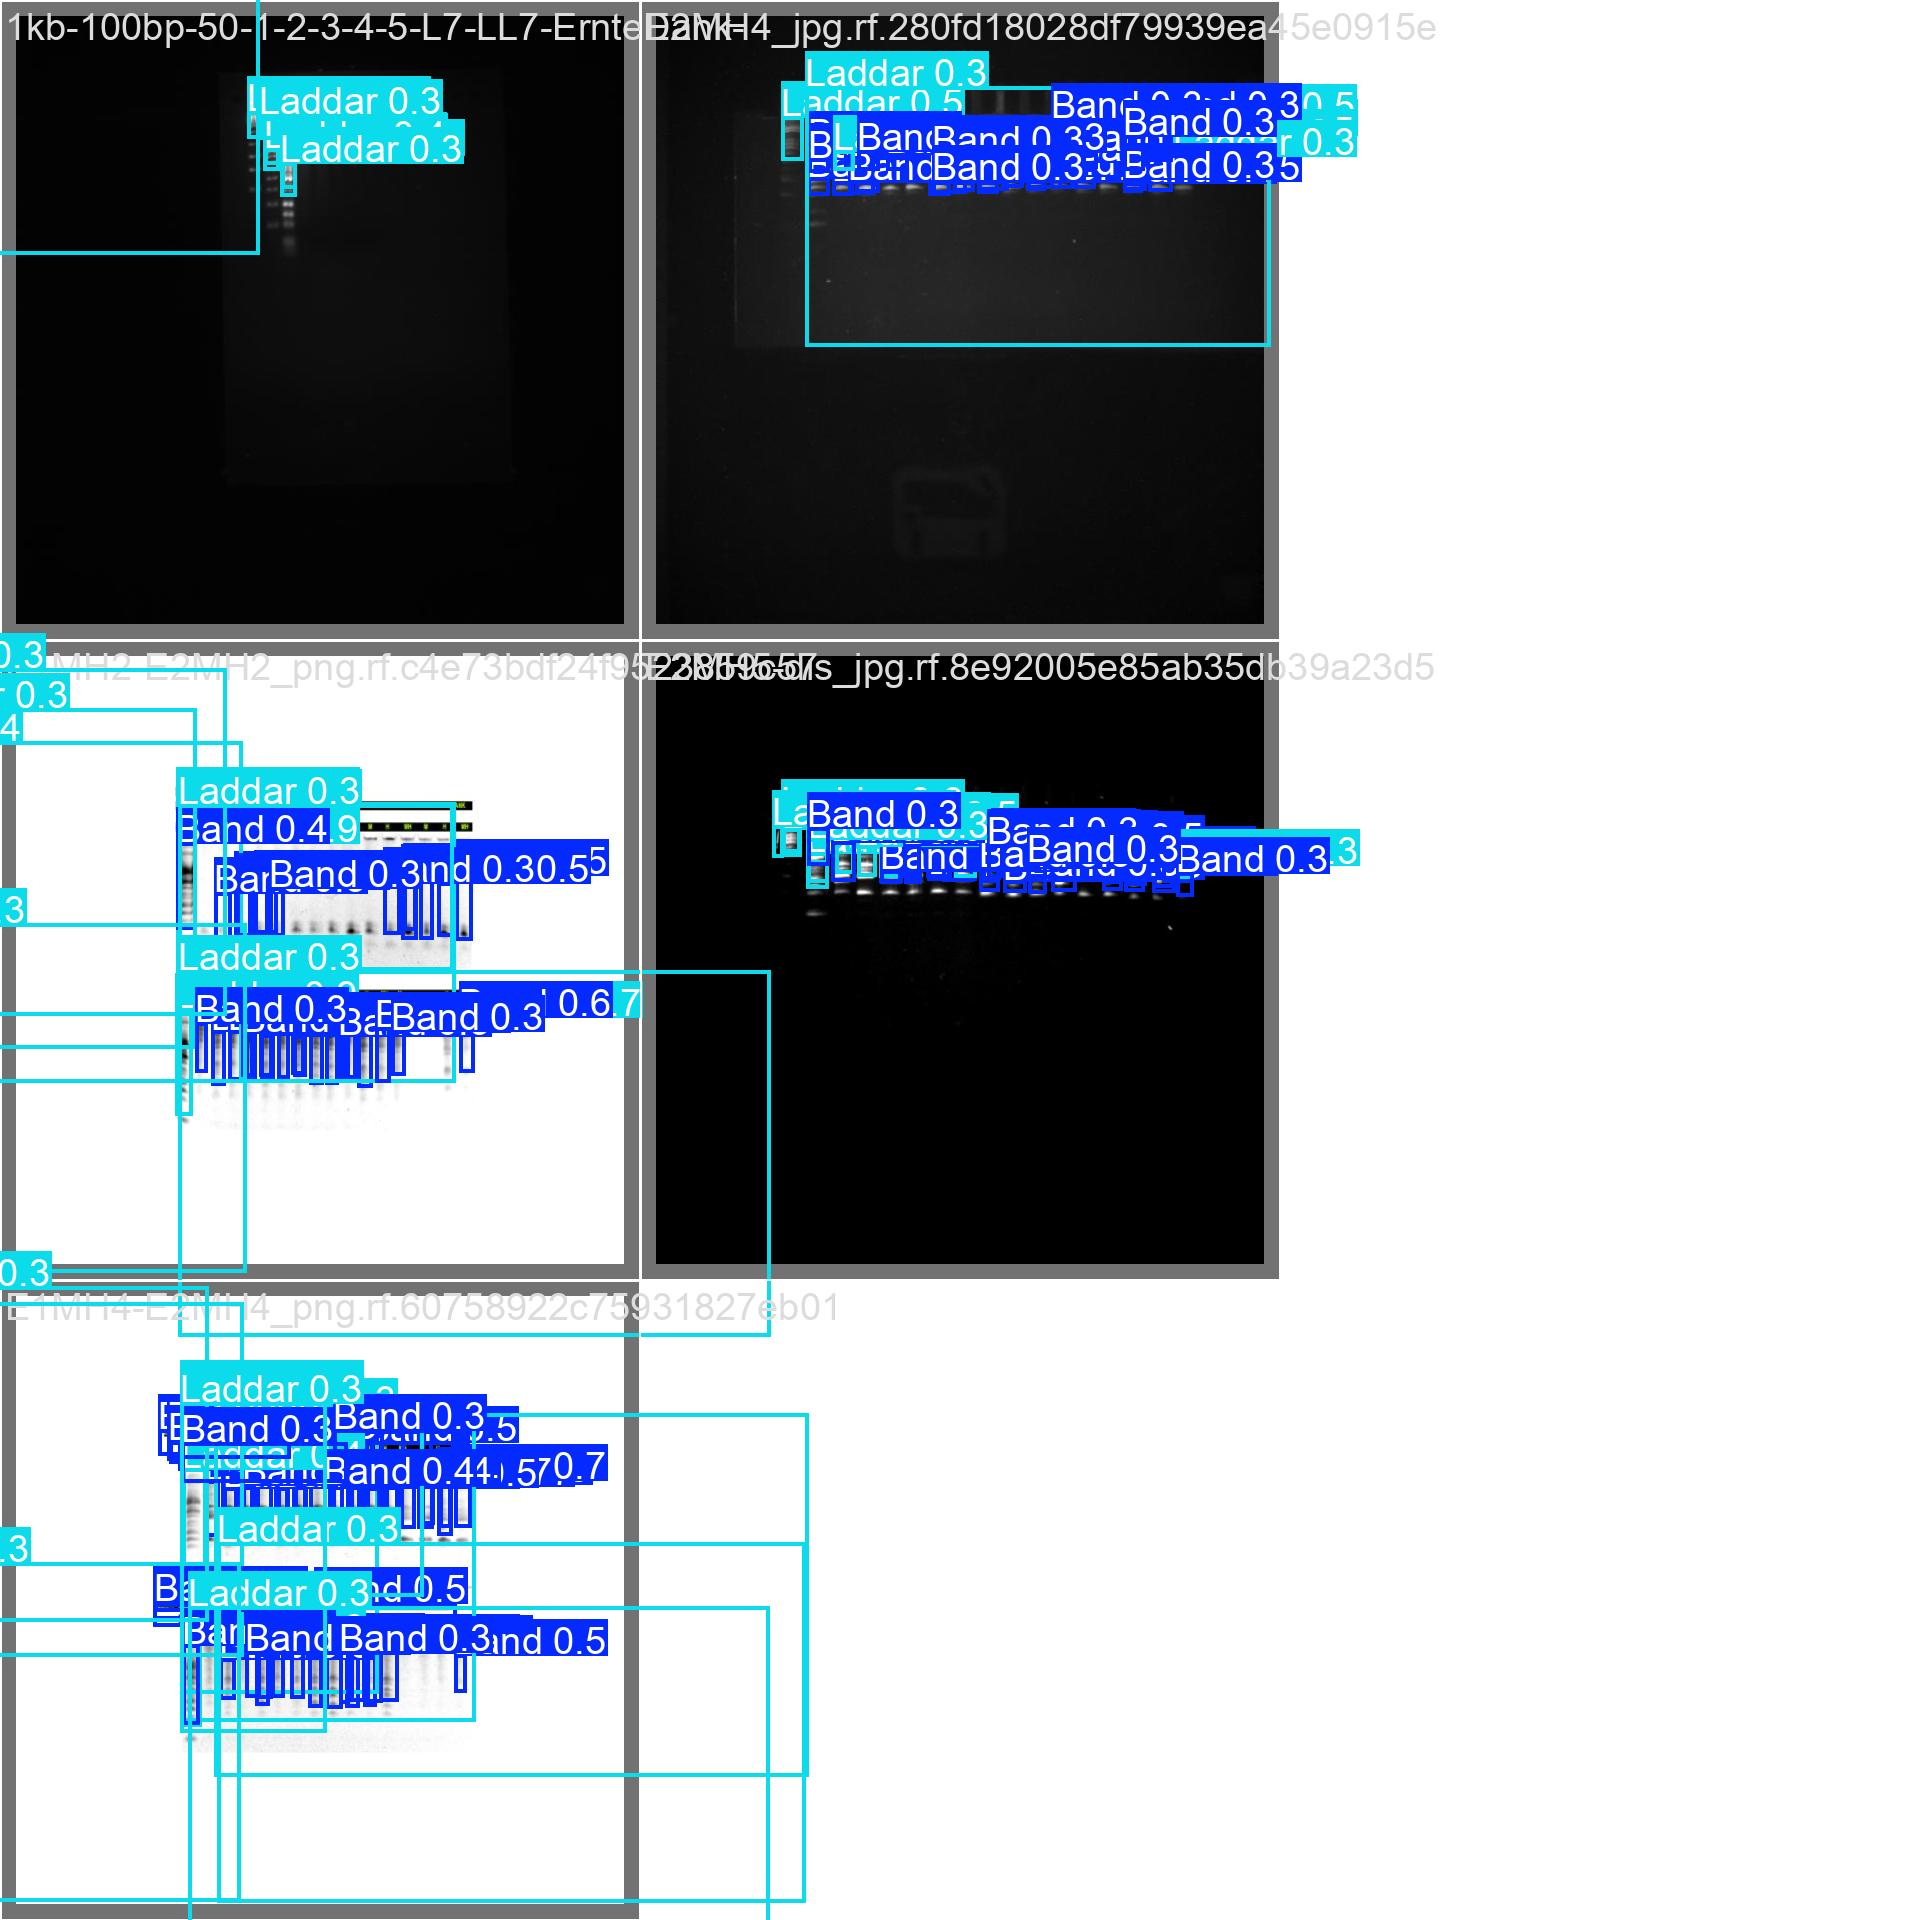

In [38]:
Image ("/content/runs/detect/val/val_batch0_pred.jpg", width= 900)

In [39]:
! yolo task=detect mode=predict model="/content/runs/detect/train/weights/best.pt" conf=0.25 source={dataset.location}/test/images save=True

Ultralytics 8.3.78 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv9s summary (fused): 197 layers, 7,167,862 parameters, 0 gradients, 26.7 GFLOPs

image 1/4 /content/Gel-annotation-on-lingonberry-1/test/images/E1MH5-E2MH5_png.rf.7eabca9f7ab93b8a1a64a5e6cc9eab31.jpg: 608x608 64 Bands, 3 Laddars, 21.6ms
image 2/4 /content/Gel-annotation-on-lingonberry-1/test/images/E2MH1_jpg.rf.e232809d032546e0b0378a8899810a36.jpg: 608x608 30 Bands, 5 Laddars, 19.9ms
image 3/4 /content/Gel-annotation-on-lingonberry-1/test/images/E2MH3_jpg.rf.86ee065c6adbbeac3d5ad8863e4234a4.jpg: 608x608 12 Bands, 3 Laddars, 19.9ms
image 4/4 /content/Gel-annotation-on-lingonberry-1/test/images/E3MH6___jpg.rf.88e141aa1ed64a003ba22fd7dfa94ca6.jpg: 608x608 39 Bands, 14 Laddars, 19.9ms
Speed: 3.1ms preprocess, 20.3ms inference, 37.2ms postprocess per image at shape (1, 3, 608, 608)
Results saved to runs/detect/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


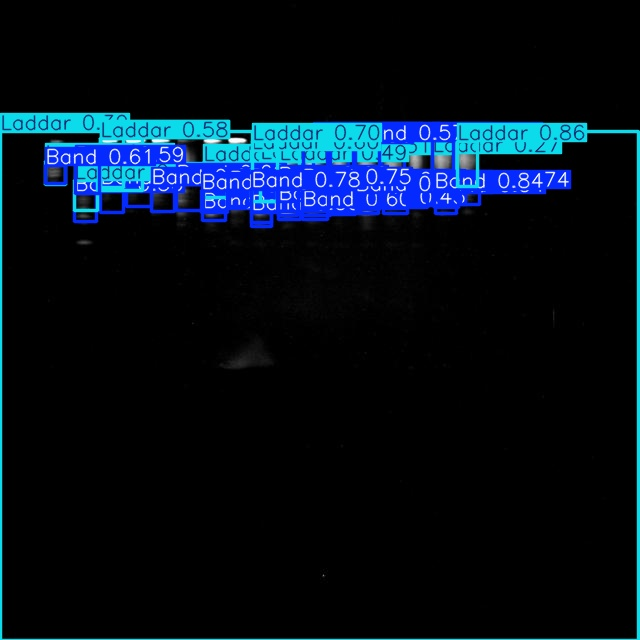

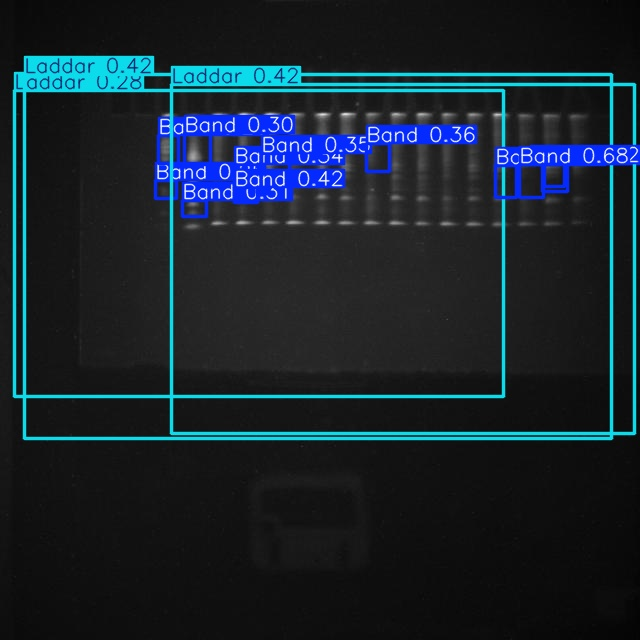

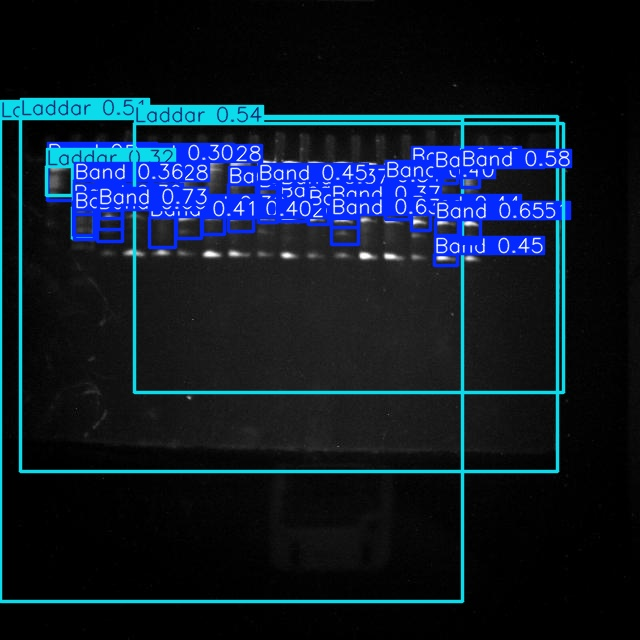

In [40]:
import glob
import os
from IPython.display import Image as IPyImage, display

latest_folder = max(glob.glob('/content/runs/detect/predict*/'), key=os.path.getmtime)
for img in glob.glob(f'{latest_folder}/*.jpg')[1:4]:
  display(IPyImage(filename=img, width=600))
  print("\n")

In [41]:
! yolo task=detect mode=predict model="/content/runs/detect/train/weights/best.pt" conf=0.25 source=/content/drive/MyDrive/E1MH1-E2MH1.png save=True

Ultralytics 8.3.78 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv9s summary (fused): 197 layers, 7,167,862 parameters, 0 gradients, 26.7 GFLOPs

image 1/1 /content/drive/MyDrive/E1MH1-E2MH1.png: 416x608 52 Bands, 2 Laddars, 54.9ms
Speed: 3.1ms preprocess, 54.9ms inference, 158.5ms postprocess per image at shape (1, 3, 416, 608)
Results saved to runs/detect/predict2
💡 Learn more at https://docs.ultralytics.com/modes/predict


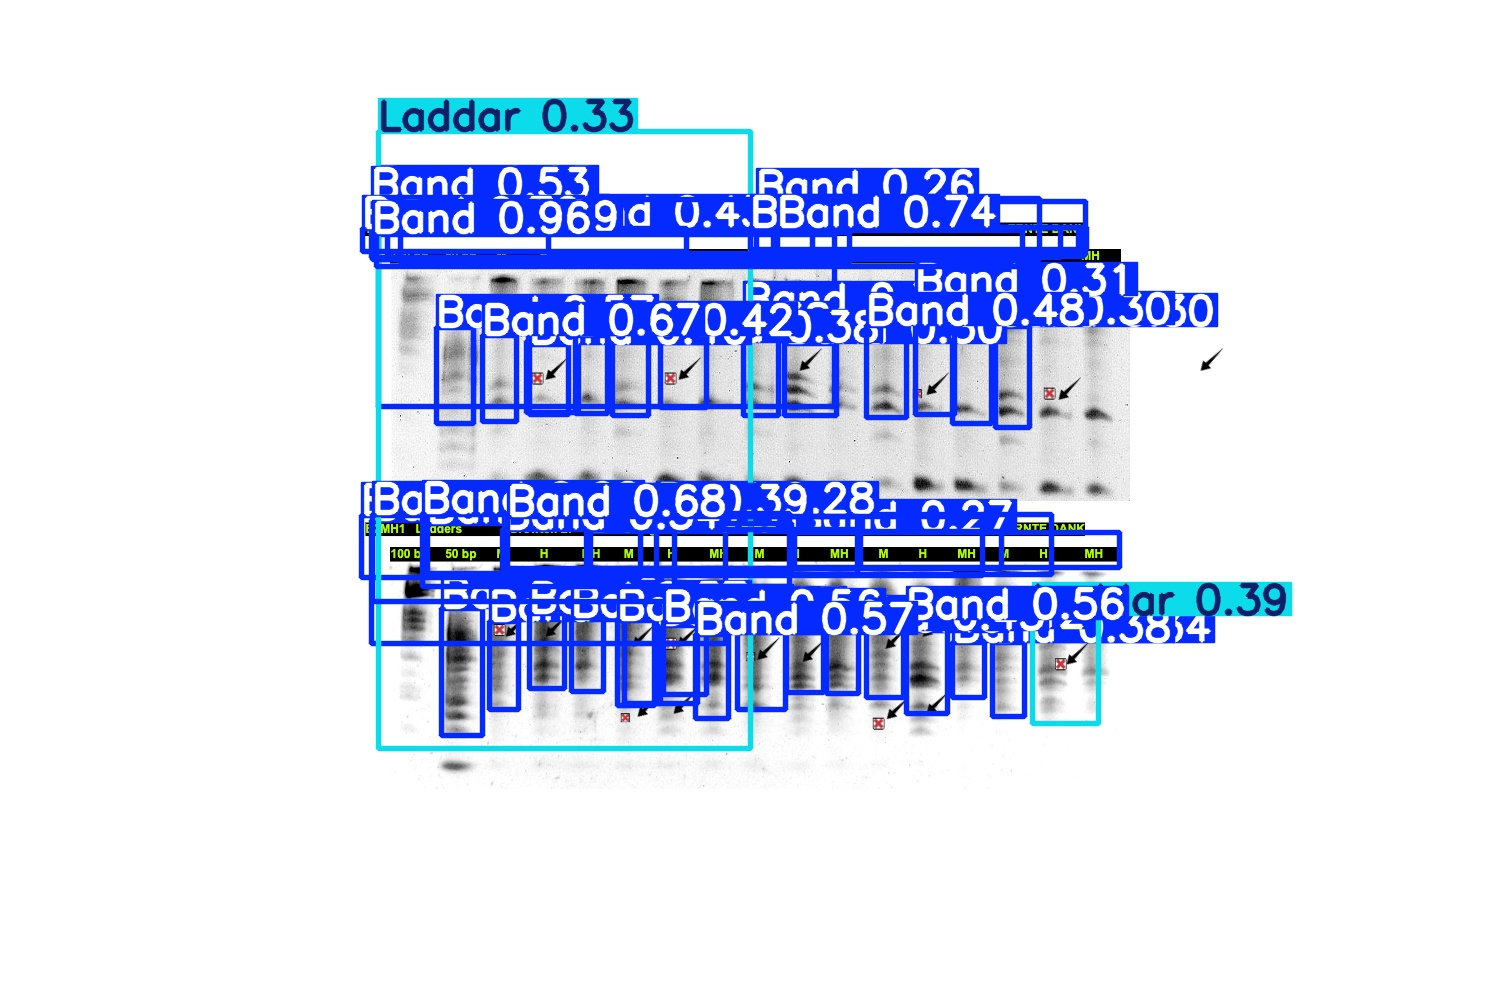

In [42]:
Image ("/content/runs/detect/predict2/E1MH1-E2MH1.jpg", width= 900)

In [43]:
! yolo task=detect mode=predict model="/content/runs/detect/train/weights/best.pt" conf=0.25 source=/content/drive/MyDrive/E1MH2-E2MH2.png save=True

Ultralytics 8.3.78 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv9s summary (fused): 197 layers, 7,167,862 parameters, 0 gradients, 26.7 GFLOPs

image 1/1 /content/drive/MyDrive/E1MH2-E2MH2.png: 416x608 16 Bands, 4 Laddars, 59.1ms
Speed: 3.4ms preprocess, 59.1ms inference, 165.0ms postprocess per image at shape (1, 3, 416, 608)
Results saved to runs/detect/predict3
💡 Learn more at https://docs.ultralytics.com/modes/predict


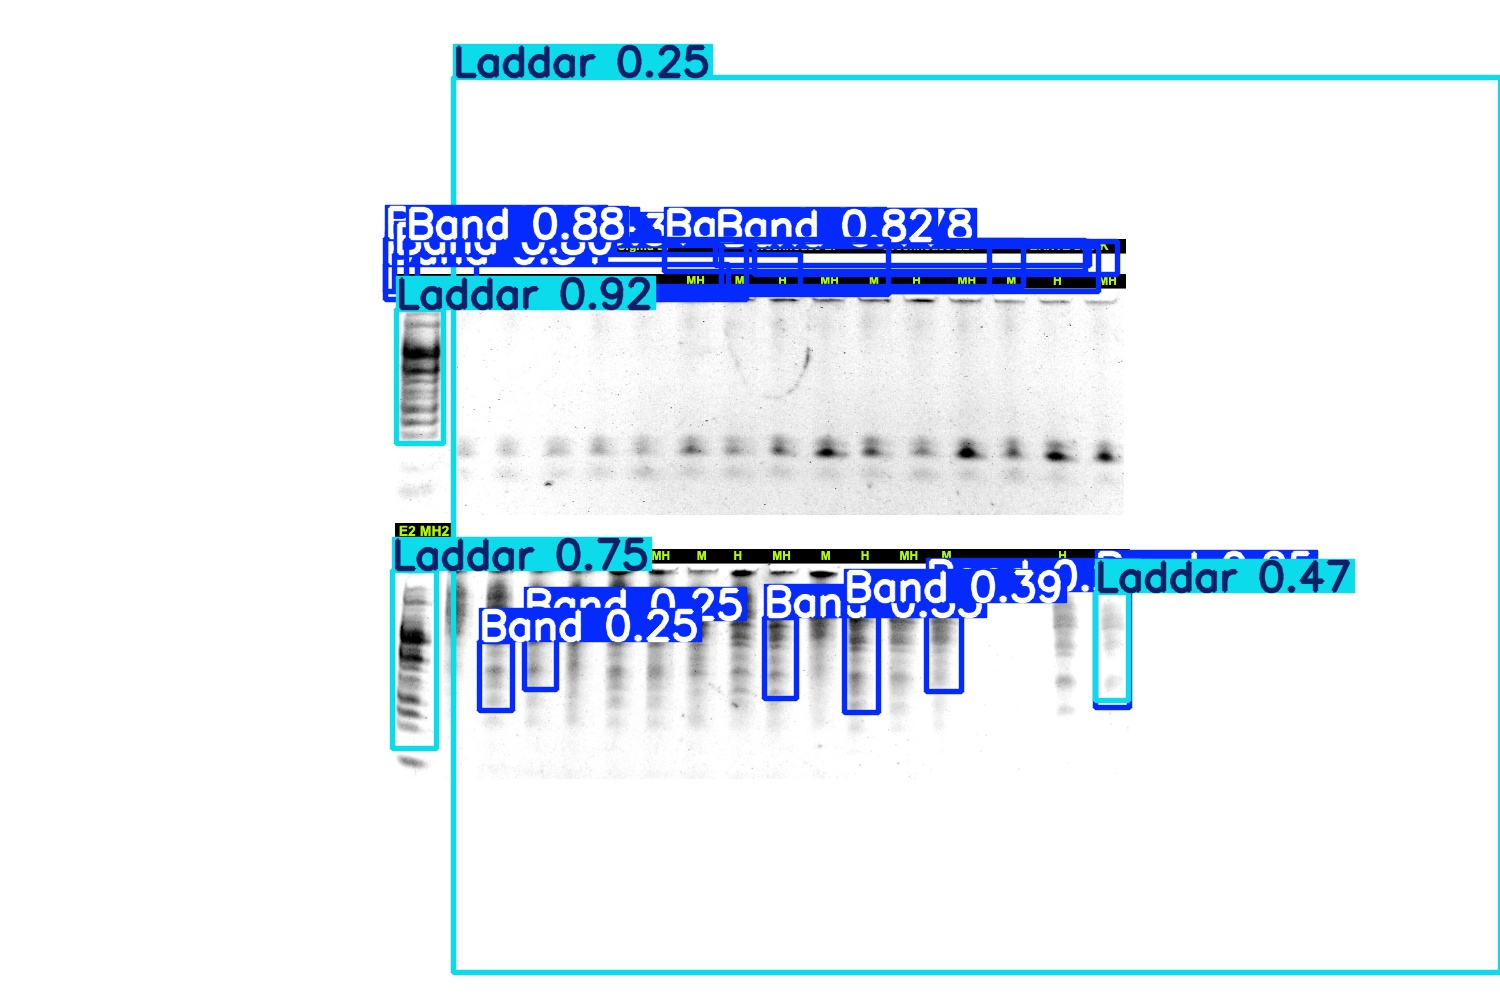

In [44]:
Image ("/content/runs/detect/predict3/E1MH2-E2MH2.jpg", width= 900)

In [45]:
! yolo task=detect mode=predict model="/content/runs/detect/train/weights/best.pt" conf=0.25 source=/content/drive/MyDrive/E1MH3-E2MH3.png save=True

Ultralytics 8.3.78 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv9s summary (fused): 197 layers, 7,167,862 parameters, 0 gradients, 26.7 GFLOPs

image 1/1 /content/drive/MyDrive/E1MH3-E2MH3.png: 416x608 48 Bands, 3 Laddars, 56.3ms
Speed: 3.2ms preprocess, 56.3ms inference, 156.2ms postprocess per image at shape (1, 3, 416, 608)
Results saved to runs/detect/predict4
💡 Learn more at https://docs.ultralytics.com/modes/predict


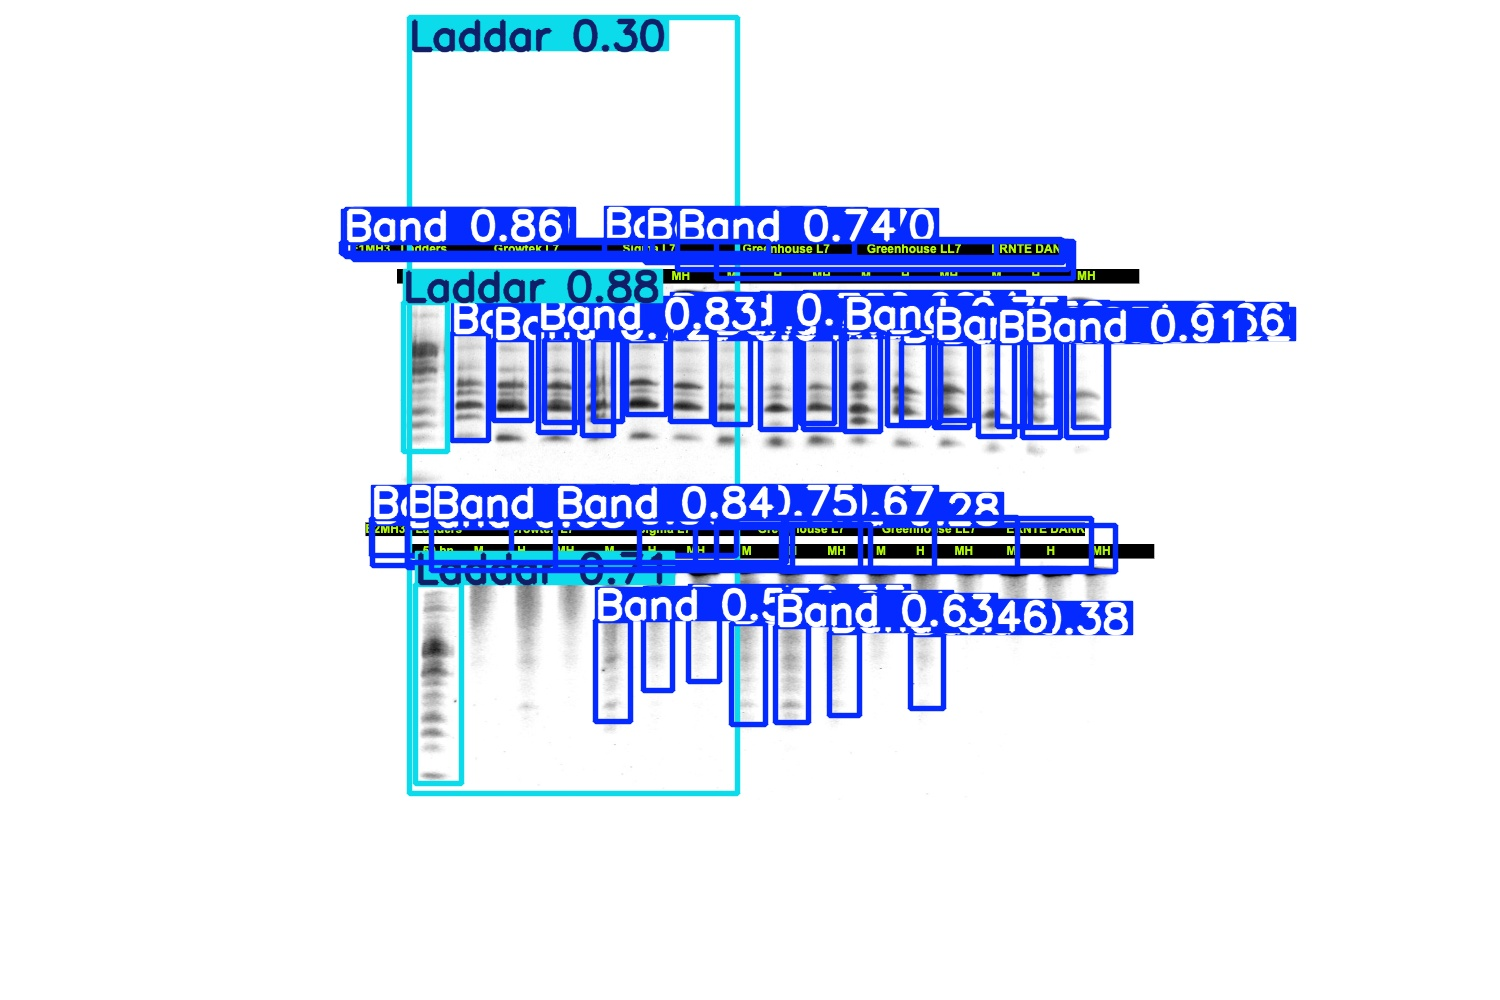

In [46]:
Image ("/content/runs/detect/predict4/E1MH3-E2MH3.jpg", width= 900)

In [47]:
! yolo task=detect mode=predict model="/content/runs/detect/train/weights/best.pt" conf=0.25 source=//content/drive/MyDrive/E1MH4-E2MH4.png save=True

Ultralytics 8.3.78 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv9s summary (fused): 197 layers, 7,167,862 parameters, 0 gradients, 26.7 GFLOPs

image 1/1 //content/drive/MyDrive/E1MH4-E2MH4.png: 416x608 22 Bands, 5 Laddars, 57.2ms
Speed: 3.4ms preprocess, 57.2ms inference, 228.4ms postprocess per image at shape (1, 3, 416, 608)
Results saved to runs/detect/predict5
💡 Learn more at https://docs.ultralytics.com/modes/predict


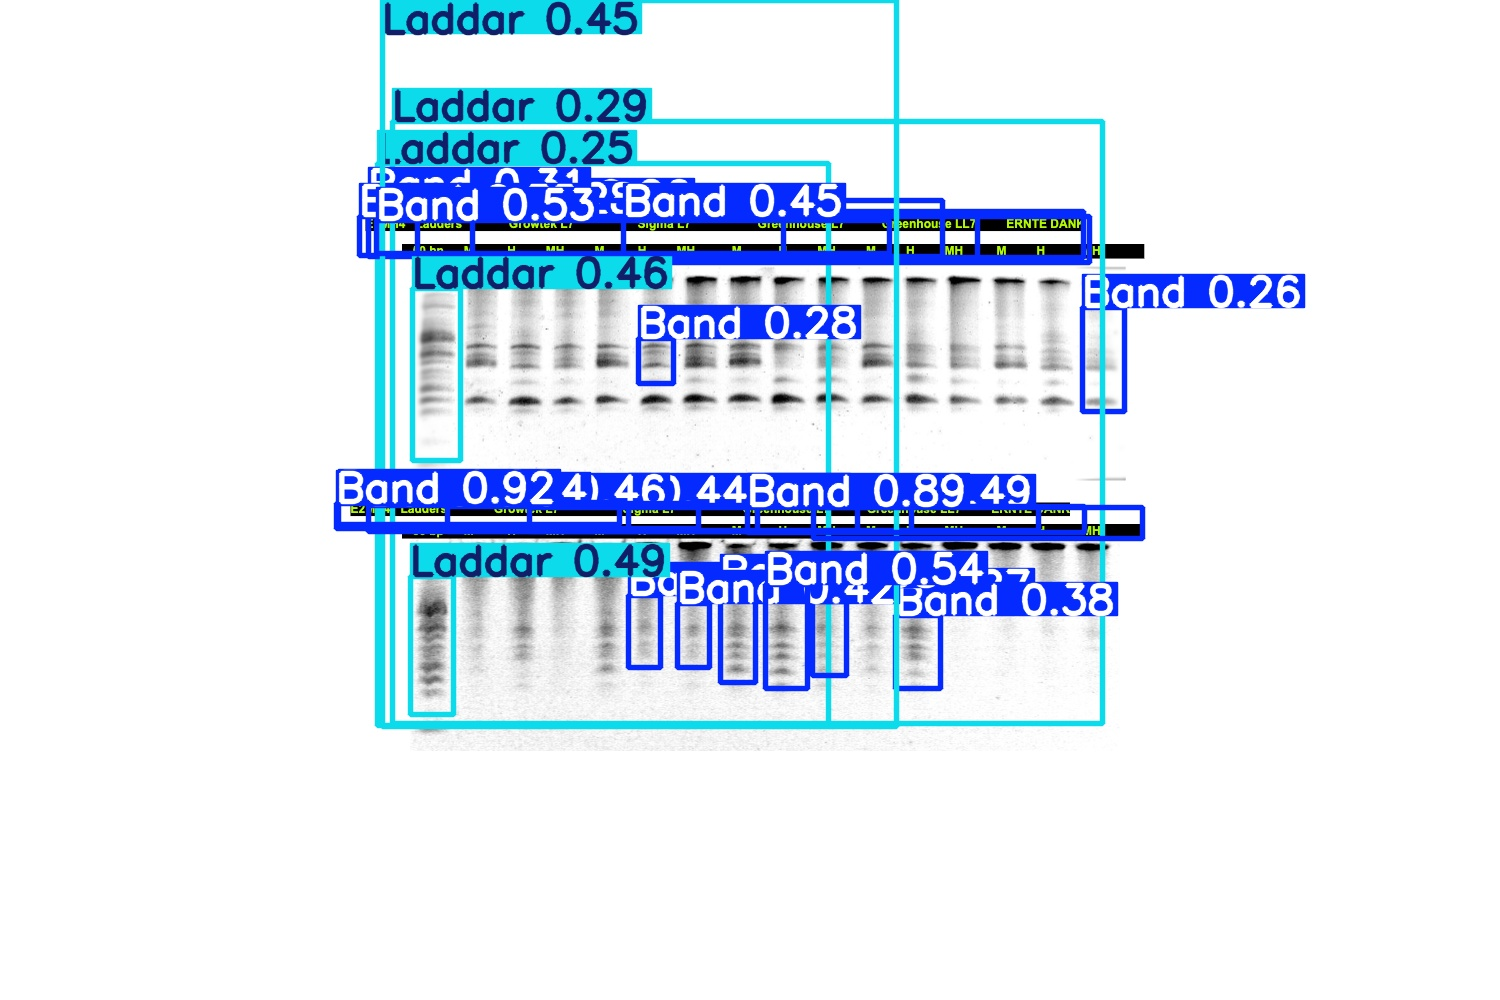

In [48]:
Image ("/content/runs/detect/predict5/E1MH4-E2MH4.jpg", width= 900)

In [49]:
! yolo task=detect mode=predict model="/content/runs/detect/train/weights/best.pt" conf=0.25 source=/content/drive/MyDrive/E1MH5-E2MH5.png save=True

Ultralytics 8.3.78 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv9s summary (fused): 197 layers, 7,167,862 parameters, 0 gradients, 26.7 GFLOPs

image 1/1 /content/drive/MyDrive/E1MH5-E2MH5.png: 416x608 58 Bands, 1 Laddar, 61.9ms
Speed: 3.5ms preprocess, 61.9ms inference, 150.5ms postprocess per image at shape (1, 3, 416, 608)
Results saved to runs/detect/predict6
💡 Learn more at https://docs.ultralytics.com/modes/predict


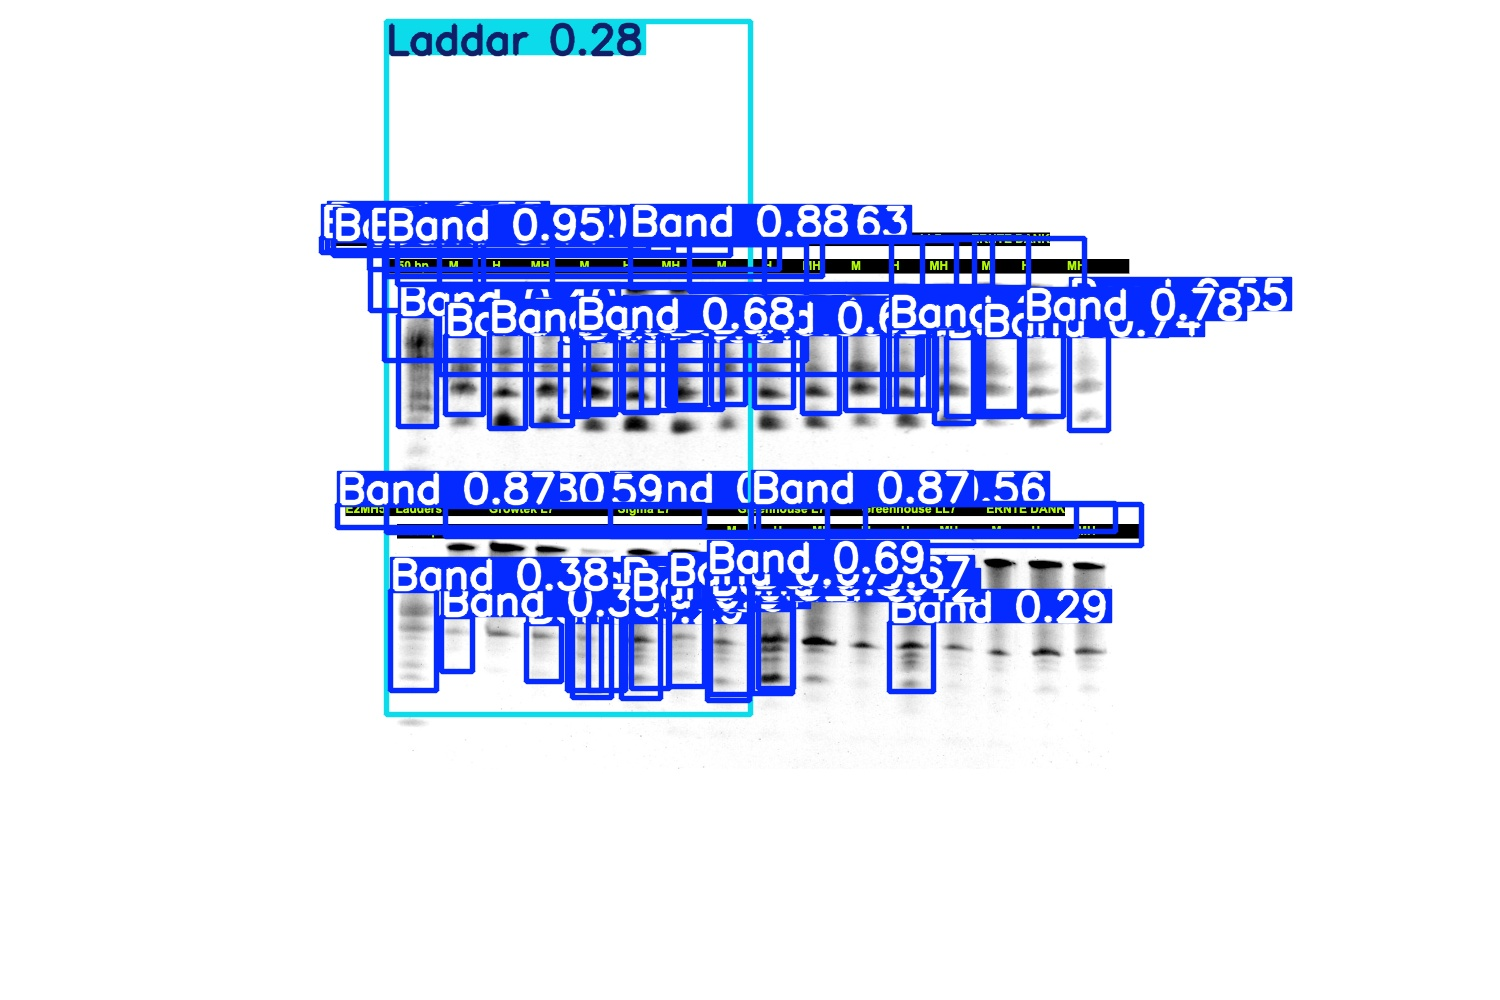

In [50]:
Image ("/content/runs/detect/predict6/E1MH5-E2MH5.jpg", width= 900)

In [ ]:
# Thank you